<h1 style="font-family:Times New Roman; font-size: 300%"><center>FYS5429 Spring 2025 </center></h1>
<h2 style="font-family:Times New Roman; font-weight:bolder; font-size:240%">2-Dimensional Quantum dots</h2>

<p style="font-family:Times New Roman; font-size:120%">    
   We first import packages, define notebook parameters and define functions
</p>

In [1]:
# Hot-reload local modules when you save them
%load_ext autoreload
%autoreload 2


    
# Optional: inline plots


In [2]:
import os

os.environ["CUDA_MANUAL_DEVICE"] = "3"  # must be set before importing your config/module
#os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
import gc
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

import config
from functions import *
from PINN import PINN, CTNNBackflowNet, ZeroJastrow
from utils import get_promoted_params

torch.set_num_threads(1)

/itf-fi-ml/home/aleksns/Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
config.update(
    device=("cuda:3"),
    omega=1.0,
    act_fn_name="gelu",
    n_particles=2, 
    n_epochs=400, # todo: Make optional during training
    N_collocation=50, # todo: Make optional during training
    basis="cart",      #* or "fd"
    nx=1, ny=1,     #* Cartesian
    sampler = "stratisfied",
    sampler_adapt=True,
)
cfg = config.get()
std = 1.0 / (cfg.omega**0.5)  #* for sampling collocation points
params = cfg.as_dict()
globals().update(get_promoted_params(
    names=["omega", "nx", "ny", "n_particles", "hidden_dim", "n_layers", "L", "n_grid", "d", "device", "V", "E"],
    include_runtime=True
))

In [5]:
from utils import inject_params


@inject_params
def compute_coulomb_interaction2(
    x: torch.Tensor,
    *,
    params=None,
    eps_rel: float = 1e-18,   # ε = eps_rel * 1/sqrt(ω)  (physical units)
    cap: float = 1e18,        # clamp absurd contributions
) -> torch.Tensor:
    """
    Vectorized Coulomb with C² soft-core radius r̃ = sqrt(r^2 + ε^2).
    Returns V_int of shape (B,1).
    """
    kappa = 1#float(params["V"])
    omega = float(params["omega"])
    B, N, d = x.shape
    dev = x.device

    # pairwise diffs and distances (physical coords)
    diff = x.unsqueeze(2) - x.unsqueeze(1)                          # (B,N,N,d)
    ii, jj = torch.triu_indices(N, N, 1, device=dev)
    r2 = (diff[:, ii, jj, :] ** 2).sum(-1)                          # (B,P)

    # soft-core ε in physical units
    l0 = 1.0 / math.sqrt(max(omega, 1e-12))
    eps2 = (eps_rel * l0) ** 2

    r_soft = torch.sqrt(r2 + eps2)                                  # (B,P)
    Vij = kappa / r_soft                                            # (B,P)

    # clamp and guard
    Vij = torch.clamp(Vij, max=cap)
    Vij = torch.nan_to_num(Vij, nan=cap, posinf=cap, neginf=-cap)

    V = Vij.sum(dim=1, keepdim=True)                                # (B,1)
    bad = ~torch.isfinite(V).squeeze(1)
    if bad.any():
        V[bad] = 0.0  # optional: or resample those rows upstream
    return V

<h2 style="font-family:Times New Roman; font-weight:bolder; font-size:240%">Initializing Slater determinant</h2>

<p style="font-family:Times New Roman; font-size:120%">    
   We do not include any interaction or correlation in our slater determinant, and therefore only fill up the quantum states according to Pauli's exclusion principle.
</p>

In [8]:
def make_cartesian_C_occ(nx, ny, n_occ, *, device = device, dtype=torch.float64):
    # list all (n_x, n_y), then sort by shell S=n_x+n_y (tie-break by n_x)
    pairs = [(ix, iy) for ix in range(nx) for iy in range(ny)]
    pairs.sort(key=lambda t: (t[0] + t[1], t[0]))
    sel = pairs[:n_occ]
    cols = [ix * ny + iy for (ix, iy) in sel]  # column indices in your basis
    C = torch.zeros(nx * ny, n_occ, dtype=dtype, device=device)
    for j, c in enumerate(cols):
        C[c, j] = 1.0
    return C#, pairs, sel, cols

In [7]:
def make_cartesian_C_occ(nx, ny, n_occ, *, device, dtype=torch.float64):
    # list all (n_x, n_y), then sort by shell S=n_x+n_y (tie-break by n_x)
    pairs = [(ix, iy) for ix in range(nx) for iy in range(ny)]
    pairs.sort(key=lambda t: (t[0] + t[1], t[0]))
    sel = pairs[:n_occ]
    cols = [ix * ny + iy for (ix, iy) in sel]  # column indices in your basis
    C = torch.zeros(nx * ny, n_occ, dtype=dtype, device=device)
    for j, c in enumerate(cols):
        C[c, j] = 1.0
    return C, pairs, sel, cols
C_occ, _, sel_pairs, sel_cols = make_cartesian_C_occ(nx, ny, int(n_particles/2), device=cfg.torch_device, dtype=torch.float64)
# sel_pairs -> [(0,0),(1,0),(0,1),(2,0),(1,1),(0,2)]
# sel_cols  -> [0, 3, 1, 6, 4, 2]
C_occ

tensor([[1.]], device='cuda:3', dtype=torch.float64)

In [9]:
f_net = PINN(
    n_particles=cfg.n_particles,
    d=cfg.d,
    omega=cfg.omega,
    dL = 5,
    hidden_dim = 128,
    n_layers = 2,
    act = "gelu",
    init = "xavier",
    use_gate=True,
).to(cfg.torch_device, cfg.torch_dtype)

f_net_zero = ZeroJastrow().to(cfg.torch_device, cfg.torch_dtype)


In [10]:
f_net = PINN(
    n_particles=cfg.n_particles,
    d=cfg.d,
    omega=cfg.omega,
    dL = 5,
    hidden_dim = 128,
    n_layers = 2,
    act = "gelu",
    init = "xavier",
    use_gate=True,
).to(cfg.torch_device, cfg.torch_dtype)


bf = CTNNBackflowNet(
    d=2,
    msg_hidden=128,
    msg_layers=2,
    hidden=128,
    layers=3,
    act="gelu",
    aggregation="mean",
    use_spin=True,
    same_spin_only=False,
    out_bound="tanh",
    bf_scale_init=0.3,
    zero_init_last=False,
    omega = cfg.omega
)


In [9]:
load_model_into(f_net, name="f_netCTNN", strict=True)
load_model_into(bf, name="backflowCTNN", strict=True)

CTNNBackflowNet(
  (_act): GELU(approximate=none)
  (node_embed): Linear(in_features=3, out_features=128, bias=True)
  (edge_embed): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): GELU(approximate=none)
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (rho_v_to_e): Linear(in_features=128, out_features=128, bias=False)
  (rho_e_to_v): Linear(in_features=128, out_features=128, bias=False)
  (edge_update): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): GELU(approximate=none)
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (node_update): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate=none)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): GELU(approximate=none)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
  (dx_head): Linear(in_features=128, out_features=2, bias=True)
)

In [16]:
# ============================================================
# FAST repgeom grid pipeline (SR + CTNN) — final rewrite
# ============================================================

from __future__ import annotations

import csv
import inspect
import json
import re
import time
import traceback
from collections.abc import Callable, Sequence
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import torch

# ----------------------------
# Config
# ----------------------------

@dataclass
class RepGeomConfig:
    torch_device: str = "cuda"
    torch_dtype: Any = torch.float64   # set to torch.float32 for big speed if your psi_fn tolerates it

    # sampling
    sampler: str = "mcmc"              # "mcmc" or "gaussian" (gaussian = ultra fast)
    B: int = 192
    mcmc_steps: int = 70
    burn_in: int = 20
    thin: int = 10
    proposal_sigma_scale: float = 0.08
    proposal_sigma_min: float = 0.02
    proposal_sigma_max: float = 1.2
    init_sigma_max: float = 10.0

    # batching
    hook_chunk: int = 48
    mcmc_chunk: int = 96

    # storage caps
    max_node_instances: int = 4096
    max_edge_instances: int = 4096
    max_global_instances: int = 4096

    # hook controls
    max_modules_per_model: int = 60

    # compute controls
    var_capture_levels: tuple[float, ...] = (0.50, 0.80, 0.95)
    sv_topk: int = 0                  # 0 = skip SVD entirely (faster)


# ----------------------------
# Public entry
# ----------------------------

def run_repgeom_grid(
    Ns: Sequence[int],
    omegas: Sequence[float],
    models_root: str,
    out_root: str,
    std: Any,
    params: Any,
    spin: Any,
    psi_fn: Callable[..., Any],
    make_cartesian_C_occ: Callable[..., Any],
    build_f_net: Callable[..., nn.Module],
    build_bf: Callable[..., nn.Module | None],
    cfg: RepGeomConfig,
) -> dict[str, Any]:
    out_root_p = Path(out_root)
    (out_root_p / "SR").mkdir(parents=True, exist_ok=True)
    (out_root_p / "CTNN").mkdir(parents=True, exist_ok=True)

    index_entries: list[dict[str, Any]] = []
    csv_rows: list[dict[str, Any]] = []
    t0 = time.time()

    for N in Ns:
        nx_dim, ny_dim, n_occ = _basis_dims_for_closed_shell(int(N))
        for omega in omegas:
            for variant in ("SR", "CTNN"):
                res = _run_one_case(
                    N=int(N),
                    omega=float(omega),
                    variant=variant,
                    models_root=Path(models_root),
                    out_root=out_root_p,
                    std=std,
                    params=params,
                    spin=spin,
                    psi_fn=psi_fn,
                    make_cartesian_C_occ=make_cartesian_C_occ,
                    basis_dims=(nx_dim, ny_dim, n_occ),
                    build_f_net=build_f_net,
                    build_bf=build_bf,
                    cfg=cfg,
                )
                index_entries.append({
                    "N": int(N),
                    "omega": float(omega),
                    "variant": variant,
                    "ok": bool(res.get("ok", False)),
                    "json_path": res.get("_written_json_path", ""),
                    "error": res.get("error", None),
                })
                csv_rows.append(_flatten_case_for_csv(res))

    index_obj = {
        "created_unix": time.time(),
        "elapsed_sec": time.time() - t0,
        "out_root": str(out_root_p),
        "cases": index_entries,
    }
    _write_json_atomic(out_root_p / "index.json", index_obj)
    _write_collection_csv(out_root_p / "repgeom_collection.csv", csv_rows)
    return index_obj


# ----------------------------
# Case runner
# ----------------------------

def _run_one_case(
    *,
    N: int,
    omega: float,
    variant: str,
    models_root: Path,
    out_root: Path,
    std: Any,
    params: Any,
    spin: Any,
    psi_fn: Callable[..., Any],
    make_cartesian_C_occ: Callable[..., Any],
    basis_dims: tuple[int, int, int],
    build_f_net: Callable[..., nn.Module],
    build_bf: Callable[..., nn.Module | None],
    cfg: RepGeomConfig,
) -> dict[str, Any]:
    device = torch.device(cfg.torch_device)
    dtype = cfg.torch_dtype
    nx_dim, ny_dim, n_occ = basis_dims
    out_path = out_root / variant / f"N{N}_omega{_omega_str(omega)}.json"

    diag = {
        "models_root": str(models_root),
        "basis_dims": {"nx": nx_dim, "ny": ny_dim, "n_occ": n_occ},
        "case_dir": None,
        "w_folder": None,
        "f_net_candidates": [],
        "bf_candidates": [],
        "notes": [],
    }

    meta = {
        "N": N,
        "omega": omega,
        "variant": variant,
        "torch_device": cfg.torch_device,
        "torch_dtype": str(dtype),
        "cfg": asdict(cfg),
        "basis_dims": {"nx": nx_dim, "ny": ny_dim, "n_occ": n_occ},
        "created_unix": time.time(),
    }

    try:
        case_dir = _infer_case_dir(models_root, N, omega)
        diag["case_dir"] = str(case_dir)
        diag["w_folder"] = case_dir.name

        ckpt = _find_checkpoints(case_dir, omega, variant, diag)

        # ---- build f_net always ----
        f_net = _call_builder(build_f_net, N=N, omega=omega, params=params, std=std, spin=spin, variant=variant)
        if not isinstance(f_net, nn.Module):
            raise RuntimeError(f"build_f_net returned {type(f_net)} (expected nn.Module)")

        # set dtype+device BEFORE loading weights (fast, consistent)
        f_net = f_net.to(device=device, dtype=dtype).eval()
        _load_model_into(f_net, ckpt["f_net_path"], strict=True)

        # ---- build bf only if needed ----
        bf: nn.Module | None = None
        if variant == "CTNN" or ckpt.get("bf_path") is not None:
            bf = _call_builder(build_bf, N=N, omega=omega, params=params, std=std, spin=spin, variant=variant)
            if bf is None:
                if variant == "CTNN":
                    raise RuntimeError("CTNN requires bf, but build_bf returned None.")
            else:
                bf = bf.to(device=device, dtype=dtype).eval()
                if ckpt.get("bf_path") is not None:
                    _load_model_into(bf, ckpt["bf_path"], strict=True)
                elif variant == "CTNN":
                    raise RuntimeError("CTNN requires bf checkpoint but none was found.")

        # ---- build C_occ on device/dtype ----
        C_occ = _build_C_occ(make_cartesian_C_occ, nx_dim, ny_dim, n_occ, device=device, dtype=dtype)

        # ---- collector (hooks) ----
        collector = RepGeomCollector(cfg=cfg, N=N, device=device, f_net=f_net, bf=bf)

        # ---- enforce basis dims into params/std so Phi matches C_occ ----
        with _BasisContext(params=params, std=std, nx=nx_dim, ny=ny_dim, n_occ=n_occ):
            mcmc_info = _sample_and_collect(
                N=N, omega=omega,
                std=std, params=params, spin=spin,
                psi_fn=psi_fn,
                C_occ=C_occ, nx=nx_dim, ny=ny_dim, n_occ=n_occ,
                f_net=f_net, bf=bf,
                collector=collector,
                cfg=cfg, device=device, dtype=dtype,
            )

        rep = collector.finalize()
        align = _alignment_keys(rep)

        out_obj: dict[str, Any] = {
            "ok": True,
            "meta": meta,
            "paths": {
                "case_dir": str(case_dir),
                "f_net_ckpt": str(ckpt["f_net_path"]),
                "bf_ckpt": (str(ckpt["bf_path"]) if ckpt.get("bf_path") is not None else None),
            },
            "mcmc": mcmc_info,
            "repgeom": rep,
            "alignments": align,
            "diagnostics": {"checkpoint_search": diag},
        }

        _write_json_atomic(out_path, out_obj)
        out_obj["_written_json_path"] = str(out_path)
        return out_obj

    except Exception as e:
        err = f"{type(e).__name__}: {e}"
        tb = traceback.format_exc(limit=80)
        fail_obj = {
            "ok": False,
            "meta": meta,
            "error": err,
            "traceback": tb,
            "diagnostics": {"checkpoint_search": diag},
        }
        _write_json_atomic(out_path, fail_obj)
        fail_obj["_written_json_path"] = str(out_path)
        return fail_obj

    finally:
        _hard_cleanup_cuda()


# ----------------------------
# Sampling (MCMC or Gaussian) + bounded hook collection
# ----------------------------

def _sample_and_collect(
    *,
    N: int,
    omega: float,
    std: Any,
    params: Any,
    spin: Any,
    psi_fn: Callable[..., Any],
    C_occ: Any,
    nx: int,
    ny: int,
    n_occ: int,
    f_net: nn.Module,
    bf: nn.Module | None,
    collector: RepGeomCollector,
    cfg: RepGeomConfig,
    device: torch.device,
    dtype: Any,
) -> dict[str, Any]:
    B = int(cfg.B)

    # scale ~ 1/sqrt(omega)
    init_sigma = min(cfg.init_sigma_max, 1.0 / max(math.sqrt(omega), 1e-6))
    x = (init_sigma * torch.randn((B, N, 2), device=device, dtype=dtype))

    # Collect a small fixed number of snapshots (THIS is what keeps runtime bounded)
    collect_max_calls = 6
    collect_calls = 0

    # ultra-fast: no metropolis, just collect on gaussian draws (still "sampling")
    if cfg.sampler.lower() == "gaussian":
        collector.collect(
            x=x,
            psi_fn=psi_fn,
            std=std, params=params, spin=spin,
            omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
            f_net=f_net, bf=bf,
            chunk=cfg.hook_chunk,
        )
        return {
            "sampler": "gaussian",
            "B": B,
            "init_sigma": float(init_sigma),
        }

    # MCMC
    prop_sigma = cfg.proposal_sigma_scale * (1.0 / max(math.sqrt(omega), 1e-6))
    prop_sigma = float(max(cfg.proposal_sigma_min, min(cfg.proposal_sigma_max, prop_sigma)))

    with torch.inference_mode():
        logpsi = _batched_logpsi(
            psi_fn, x,
            std=std, params=params, spin=spin,
            omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
            f_net=f_net, bf=bf,
            chunk=cfg.mcmc_chunk,
        )

    logpsi = logpsi.detach().clone()

    n_accept = 0
    n_total = 0

    for step in range(int(cfg.mcmc_steps)):
        x_prop = x + prop_sigma * torch.randn_like(x)

        with torch.inference_mode():
            logpsi_prop = _batched_logpsi(
                psi_fn, x_prop,
                std=std, params=params, spin=spin,
                omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
                f_net=f_net, bf=bf,
                chunk=cfg.mcmc_chunk,
            )

        loga = 2.0 * (logpsi_prop - logpsi)
        loga = torch.clamp(loga, min=-60.0, max=60.0)
        a = torch.exp(loga)
        u = torch.rand((B,), device=device, dtype=dtype)
        acc = u < a

        if acc.any():
            x[acc] = x_prop[acc]
            logpsi[acc] = logpsi_prop[acc]

        n_accept += int(acc.sum().item())
        n_total += B

        # bounded hook collection
        if step >= cfg.burn_in and ((step - cfg.burn_in) % cfg.thin == 0):
            if collect_calls < collect_max_calls:
                collector.collect(
                    x=x,
                    psi_fn=psi_fn,
                    std=std, params=params, spin=spin,
                    omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
                    f_net=f_net, bf=bf,
                    chunk=cfg.hook_chunk,
                )
                collect_calls += 1

        # cleanup
        del x_prop, logpsi_prop, loga, a, u, acc
        if (step + 1) % 20 == 0:
            _hard_cleanup_cuda()

    return {
        "sampler": "mcmc",
        "B": B,
        "steps": int(cfg.mcmc_steps),
        "burn_in": int(cfg.burn_in),
        "thin": int(cfg.thin),
        "collect_calls": int(collect_calls),
        "proposal_sigma": float(prop_sigma),
        "accept_rate": float(n_accept / max(1, n_total)),
    }


# ----------------------------
# Basis dims + context (Phi/C_occ match)
# ----------------------------

def _basis_dims_for_closed_shell(N: int) -> tuple[int, int, int]:
    if N % 2 != 0:
        raise ValueError(f"N must be even for closed-shell; got N={N}")
    n_occ = N // 2
    S = 0
    while (S + 1) * (S + 2) // 2 < n_occ:
        S += 1
    nx_dim = S + 1
    ny_dim = S + 1
    return nx_dim, ny_dim, n_occ

class _BasisContext:
    def __init__(self, *, params: Any, std: Any, nx: int, ny: int, n_occ: int):
        self.params = params
        self.std = std
        self.nx = int(nx); self.ny = int(ny); self.n_occ = int(n_occ)
        self._stash: list[tuple[Any, str, Any, bool]] = []

    def __enter__(self):
        for obj in (self.params, self.std):
            if obj is None: continue
            for (k, v) in [
                ("nx", self.nx), ("ny", self.ny), ("n_occ", self.n_occ),
                ("nocc", self.n_occ), ("n_orb", self.n_occ),
            ]:
                self._try_set(obj, k, v)
        return self

    def __exit__(self, exc_type, exc, tb):
        for obj, key, old, had in reversed(self._stash):
            try:
                if isinstance(obj, dict):
                    if had: obj[key] = old
                    else: obj.pop(key, None)
                else:
                    if had: setattr(obj, key, old)
                    else:
                        try: delattr(obj, key)
                        except Exception: pass
            except Exception:
                pass
        self._stash.clear()
        return False

    def _try_set(self, obj: Any, key: str, val: Any) -> None:
        try:
            if isinstance(obj, dict):
                had = key in obj
                old = obj.get(key, None)
                self._stash.append((obj, key, old, had))
                obj[key] = val
            else:
                had = hasattr(obj, key)
                old = getattr(obj, key, None)
                self._stash.append((obj, key, old, had))
                setattr(obj, key, val)
        except Exception:
            pass


# ----------------------------
# Checkpoints (strict CTNN rules, SR scan)
# ----------------------------

def _infer_case_dir(models_root: Path, N: int, omega: float) -> Path:
    return models_root / f"{N}p" / _omega_to_wfolder(omega)

def _omega_to_wfolder(omega: float) -> str:
    if abs(omega - 1.0) < 1e-12: return "w_10"
    if abs(omega - 0.5) < 1e-12: return "w_05"
    if abs(omega - 0.1) < 1e-12: return "w_01"
    return "w_00"  # 0.01 or 0.001

def _ctnn_expected_names(omega: float) -> tuple[str, str]:
    if abs(omega - 0.01) < 1e-12:
        return "f_netCTNN_01.pt", "backflowCTNN_01.pt"
    if abs(omega - 0.001) < 1e-12:
        return "f_netCTNN_001.pt", "backflowCTNN_001.pt"
    return "f_netCTNN.pt", "backflowCTNN.pt"

def _find_checkpoints(case_dir: Path, omega: float, variant: str, diag: dict[str, Any]) -> dict[str, Any]:
    if not case_dir.exists():
        raise FileNotFoundError(f"Case dir not found: {case_dir}")
    pts = list(case_dir.rglob("*.pt")) + list(case_dir.rglob("*.pth"))
    if not pts:
        raise FileNotFoundError(f"No checkpoints under: {case_dir}")

    if variant == "CTNN":
        fn, bn = _ctnn_expected_names(omega)
        fpaths = [p for p in pts if p.name == fn]
        bpaths = [p for p in pts if p.name == bn]
        diag["f_net_candidates"] = [str(p) for p in fpaths]
        diag["bf_candidates"] = [str(p) for p in bpaths]
        if not fpaths:
            raise FileNotFoundError(f"CTNN required {fn} not found under {case_dir}")
        if not bpaths:
            raise FileNotFoundError(f"CTNN required {bn} not found under {case_dir}")
        return {"f_net_path": _pick_latest(fpaths), "bf_path": _pick_latest(bpaths)}

    # SR: pick existing f_net-ish; bf optional
    fnet = _pick_sr_fnet(pts, diag)
    bf = _pick_sr_bf(pts, diag)  # may be None
    return {"f_net_path": fnet, "bf_path": bf}

def _pick_latest(paths: list[Path]) -> Path:
    return max(paths, key=lambda p: p.stat().st_mtime)

def _pick_sr_fnet(pts: list[Path], diag: dict[str, Any]) -> Path:
    cand = []
    for p in pts:
        n = p.name.lower()
        if "ctnn" in n: continue
        if ("f_net" in n) or ("fnet" in n):
            if "backflow" in n or re.search(r"(^|[^a-z])bf([^a-z]|$)", n):
                continue
            cand.append(p)
    if not cand:
        cand = [p for p in pts if "ctnn" not in p.name.lower()]
    diag["f_net_candidates"] = [str(p) for p in cand]
    if not cand:
        raise FileNotFoundError("No SR f_net candidates found.")
    def score(p: Path) -> tuple[int, float]:
        n = p.name.lower()
        s = 0
        if "sr" in n: s += 50
        if "resid" in n or "residual" in n: s += 20
        if "pinn" in n: s += 10
        if "best" in n: s += 3
        return (s, p.stat().st_mtime)
    return max(cand, key=score)

def _pick_sr_bf(pts: list[Path], diag: dict[str, Any]) -> Path | None:
    cand = []
    for p in pts:
        n = p.name.lower()
        if "ctnn" in n: continue
        if "backflow" in n or re.search(r"(^|[^a-z])bf([^a-z]|$)", n):
            cand.append(p)
    diag["bf_candidates"] = [str(p) for p in cand]
    if not cand:
        diag["notes"].append("No SR backflow checkpoint found; bf will be None for SR.")
        return None
    def score(p: Path) -> tuple[int, float]:
        n = p.name.lower()
        s = 0
        if "sr" in n: s += 10
        if "backflow" in n: s += 5
        return (s, p.stat().st_mtime)
    return max(cand, key=score)


# ----------------------------
# Builders + state dict loader
# ----------------------------

def _call_builder(builder: Callable[..., Any], **kwargs) -> Any:
    sig = inspect.signature(builder)
    filt = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return builder(**filt)

def _load_model_into(model: nn.Module, ckpt_path: Path, strict: bool = True) -> None:
    ckpt = torch.load(str(ckpt_path), map_location="cpu")
    state = None
    if isinstance(ckpt, dict):
        for k in ("state_dict", "model_state_dict", "model", "net", "weights"):
            if k in ckpt and isinstance(ckpt[k], dict):
                state = ckpt[k]; break
        if state is None and all(isinstance(k, str) for k in ckpt.keys()):
            state = ckpt
    elif isinstance(ckpt, nn.Module):
        state = ckpt.state_dict()
    if state is None:
        raise RuntimeError(f"Could not extract state_dict from {ckpt_path}")
    state2 = { (k[7:] if k.startswith("module.") else k): v for k, v in state.items() }
    missing, unexpected = model.load_state_dict(state2, strict=strict)
    if strict and (missing or unexpected):
        raise RuntimeError(f"State mismatch {ckpt_path}. Missing={missing[:6]} Unexpected={unexpected[:6]}")

def _build_C_occ(make_cartesian_C_occ: Callable[..., Any], nx: int, ny: int, n_occ: int, *, device: torch.device, dtype: Any) -> Any:
    try:
        C = make_cartesian_C_occ(nx, ny, n_occ, device=device, dtype=dtype)
    except TypeError:
        C = make_cartesian_C_occ(nx, ny, n_occ)
    if isinstance(C, torch.Tensor):
        C = C.to(device=device, dtype=dtype)
    return C


# ----------------------------
# psi_fn calling (forces bf usage when present)
# ----------------------------

def _call_psi_fn(
    psi_fn: Callable[..., Any],
    x: torch.Tensor,
    *,
    std: Any,
    params: Any,
    spin: Any,
    omega: float,
    C_occ: Any,
    nx: int,
    ny: int,
    n_occ: int,
    f_net: nn.Module,
    bf: nn.Module | None,
) -> Any:
    sig = inspect.signature(psi_fn)
    names = list(sig.parameters.keys())

    mapping = {
        "std": std,
        "params": params,
        "spin": spin,
        "omega": omega,
        "w": omega,
        "C_occ": C_occ,
        "C": C_occ,
        "nx": nx,
        "ny": ny,
        "n_occ": n_occ,
        "nocc": n_occ,
        "f_net": f_net,
        "fnet": f_net,
        "res_net": f_net,
        "bf": bf,
        "backflow": bf,
        "backflow_net": bf,
    }
    kw = {k: v for k, v in mapping.items() if k in sig.parameters}

    # keyword coordinate if supported
    for cn in ("x", "R", "coords", "positions"):
        if cn in sig.parameters:
            kw[cn] = x
            return psi_fn(**kw)

    # If bf exists, try positional (f_net, bf, x) first
    if bf is not None:
        try:
            kw3 = dict(kw)
            for k in ("f_net", "fnet", "res_net", "bf", "backflow", "backflow_net"):
                kw3.pop(k, None)
            return psi_fn(f_net, bf, x, **kw3)
        except TypeError:
            pass

    # try (f_net, x)
    try:
        kw2 = dict(kw)
        for k in ("f_net", "fnet", "res_net"):
            kw2.pop(k, None)
        return psi_fn(f_net, x, **kw2)
    except TypeError:
        pass

    # fallback (x, **kw)
    return psi_fn(x, **kw)

def _extract_logpsi(out: Any) -> torch.Tensor:
    if isinstance(out, torch.Tensor):
        t = out
    elif isinstance(out, (tuple, list)) and out:
        t = out[0]
    elif isinstance(out, dict):
        if "logpsi" in out: t = out["logpsi"]
        elif "log_psi" in out: t = out["log_psi"]
        else: raise RuntimeError(f"psi_fn dict output missing logpsi keys: {list(out.keys())[:20]}")
    else:
        raise RuntimeError(f"Unsupported psi_fn output type: {type(out)}")
    while t.ndim > 1 and t.shape[-1] == 1:
        t = t.squeeze(-1)
    if t.ndim > 1:
        t = t.reshape(t.shape[0], -1).sum(dim=1)
    return t


def _batched_logpsi(
    psi_fn: Callable[..., Any],
    x: torch.Tensor,
    *,
    std: Any,
    params: Any,
    spin: Any,
    omega: float,
    C_occ: Any,
    nx: int,
    ny: int,
    n_occ: int,
    f_net: nn.Module,
    bf: nn.Module | None,
    chunk: int,
) -> torch.Tensor:
    B = x.shape[0]
    outs = []
    for i in range(0, B, chunk):
        xb = x[i:i+chunk]
        out = _call_psi_fn(
            psi_fn, xb,
            std=std, params=params, spin=spin,
            omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
            f_net=f_net, bf=bf,
        )
        outs.append(_extract_logpsi(out).detach())
        del xb, out
    return torch.cat(outs, dim=0)


# ----------------------------
# Collector (GPU-subsample before CPU transfer)
# ----------------------------

class _Reservoir:
    def __init__(self, max_rows: int):
        self.max_rows = int(max_rows)
        self.X: torch.Tensor | None = None
        self.phys: torch.Tensor | None = None

    def add_cpu(self, X_cpu: torch.Tensor, phys_cpu: torch.Tensor | None) -> None:
        if X_cpu.numel() == 0:
            return
        if self.X is None:
            self.X = X_cpu
            self.phys = phys_cpu
        else:
            self.X = torch.cat([self.X, X_cpu], dim=0)
            if self.phys is None or phys_cpu is None:
                self.phys = None
            else:
                self.phys = torch.cat([self.phys, phys_cpu], dim=0)

        # keep bounded
        if self.X.shape[0] > self.max_rows:
            idx = torch.randperm(self.X.shape[0])[: self.max_rows]
            self.X = self.X[idx]
            if self.phys is not None:
                self.phys = self.phys[idx]


class RepGeomCollector:
    def __init__(self, *, cfg: RepGeomConfig, N: int, device: torch.device, f_net: nn.Module, bf: nn.Module | None):
        self.cfg = cfg
        self.N = int(N)
        self.device = device
        self.f_net = f_net
        self.bf = bf

        self._active = False
        self._hooks: list[Any] = []

        self.node_buf: dict[str, _Reservoir] = {}
        self.edge_buf: dict[str, _Reservoir] = {}
        self.glob_buf: dict[str, _Reservoir] = {}

        self._phys_node_r: torch.Tensor | None = None  # CPU (B,N)
        self._phys_edge_r: torch.Tensor | None = None  # CPU (B,E)
        self._curB: int = 0
        self._E: int = self.N * (self.N - 1) // 2

        self._hooks += _attach_hooks(self.f_net, "f_net", self, max_modules=self.cfg.max_modules_per_model)
        if self.bf is not None:
            self._hooks += _attach_hooks(self.bf, "bf", self, max_modules=self.cfg.max_modules_per_model)

    def close(self):
        for h in self._hooks:
            try: h.remove()
            except Exception: pass
        self._hooks.clear()

    def _handle(self, name: str, out: torch.Tensor) -> None:
        if not self._active:
            return
        if not isinstance(out, torch.Tensor) or out.numel() == 0:
            return
        # avoid expensive global finite checks; cheap guard on a small slice
        flat = out.reshape(-1)
        if flat.numel() >= 8 and not torch.isfinite(flat[:8]).all():
            return

        Bc = self._curB
        Ec = self._E

        # helper: subsample rows on GPU then move to CPU
        def _gpu_subsample_rows(Xg: torch.Tensor, max_rows: int, phys_cpu: torch.Tensor | None) -> tuple[torch.Tensor, torch.Tensor | None]:
            M = Xg.shape[0]
            if M > max_rows:
                idx = torch.randperm(M, device=Xg.device)[:max_rows]
                Xg = Xg[idx]
                if phys_cpu is not None:
                    phys_cpu = phys_cpu[idx.cpu()]
            Xc = Xg.detach().float().cpu()
            return Xc, phys_cpu

        t = out.detach()

        # 3D explicit forms
        if t.ndim == 3:
            # (B,N,d) node
            if t.shape[0] == Bc and t.shape[1] == self.N:
                Xg = t.reshape(-1, t.shape[-1])
                phys = self._phys_node_r.reshape(-1) if self._phys_node_r is not None else None
                buf = self.node_buf.get(name) or _Reservoir(self.cfg.max_node_instances)
                self.node_buf[name] = buf
                Xc, pc = _gpu_subsample_rows(Xg, self.cfg.max_node_instances, phys)
                buf.add_cpu(Xc, pc)
                return
            # (B,E,d) edge
            if t.shape[0] == Bc and t.shape[1] == Ec:
                Xg = t.reshape(-1, t.shape[-1])
                phys = self._phys_edge_r.reshape(-1) if self._phys_edge_r is not None else None
                buf = self.edge_buf.get(name) or _Reservoir(self.cfg.max_edge_instances)
                self.edge_buf[name] = buf
                Xc, pc = _gpu_subsample_rows(Xg, self.cfg.max_edge_instances, phys)
                buf.add_cpu(Xc, pc)
                return

            # otherwise global
            Xg = t.reshape(t.shape[0], -1)
            buf = self.glob_buf.get(name) or _Reservoir(self.cfg.max_global_instances)
            self.glob_buf[name] = buf
            Xc, _ = _gpu_subsample_rows(Xg, self.cfg.max_global_instances, None)
            buf.add_cpu(Xc, None)
            return

        # 2D flattened forms: (B*N,d) or (B*E,d)
        if t.ndim == 2 and Bc > 0:
            M, d = t.shape
            if M == Bc * self.N:
                phys = self._phys_node_r.reshape(-1) if self._phys_node_r is not None else None
                buf = self.node_buf.get(name) or _Reservoir(self.cfg.max_node_instances)
                self.node_buf[name] = buf
                Xc, pc = _gpu_subsample_rows(t, self.cfg.max_node_instances, phys)
                buf.add_cpu(Xc, pc)
                return
            if M == Bc * Ec:
                phys = self._phys_edge_r.reshape(-1) if self._phys_edge_r is not None else None
                buf = self.edge_buf.get(name) or _Reservoir(self.cfg.max_edge_instances)
                self.edge_buf[name] = buf
                Xc, pc = _gpu_subsample_rows(t, self.cfg.max_edge_instances, phys)
                buf.add_cpu(Xc, pc)
                return

        # fallback global
        Xg = t.reshape(t.shape[0], -1) if t.ndim >= 2 else t.reshape(1, -1)
        buf = self.glob_buf.get(name) or _Reservoir(self.cfg.max_global_instances)
        self.glob_buf[name] = buf
        Xc, _ = _gpu_subsample_rows(Xg, self.cfg.max_global_instances, None)
        buf.add_cpu(Xc, None)

    def collect(
        self,
        *,
        x: torch.Tensor,
        psi_fn: Callable[..., Any],
        std: Any,
        params: Any,
        spin: Any,
        omega: float,
        C_occ: Any,
        nx: int,
        ny: int,
        n_occ: int,
        f_net: nn.Module,
        bf: nn.Module | None,
        chunk: int,
    ) -> None:
        # compute physics features for this x once (cheap edge computation, no cdist)
        r_node_cpu, r_edge_cpu = _physics_features_fast(x)
        self._phys_node_r = r_node_cpu
        self._phys_edge_r = r_edge_cpu

        self._active = True
        try:
            B = x.shape[0]
            for i in range(0, B, chunk):
                xb = x[i:i+chunk]
                self._curB = int(xb.shape[0])
                self._phys_node_r = r_node_cpu[i:i+chunk].contiguous()
                self._phys_edge_r = r_edge_cpu[i:i+chunk].contiguous()

                with torch.inference_mode():
                    _ = _call_psi_fn(
                        psi_fn, xb,
                        std=std, params=params, spin=spin,
                        omega=omega, C_occ=C_occ, nx=nx, ny=ny, n_occ=n_occ,
                        f_net=f_net, bf=bf,
                    )
                del xb, _
        finally:
            self._active = False

    def finalize(self) -> dict[str, Any]:
        rep = {
            "node_space": _finalize_space(self.node_buf, self.cfg, phys_corr=True),
            "edge_space": _finalize_space(self.edge_buf, self.cfg, phys_corr=True),
            "global_space": _finalize_space(self.glob_buf, self.cfg, phys_corr=False),
            "summaries": {
                "node": {"n_modules": int(len(self.node_buf))},
                "edge": {"n_modules": int(len(self.edge_buf))},
                "global": {"n_modules": int(len(self.glob_buf))},
            }
        }
        self.close()
        return rep


def _attach_hooks(model: nn.Module, prefix: str, collector: RepGeomCollector, *, max_modules: int) -> list[Any]:
    hooks: list[Any] = []

    def _h_out(mod, inp, out):
        if isinstance(out, torch.Tensor):
            collector._handle(f"{prefix}.__out__", out)

    hooks.append(model.register_forward_hook(_h_out))

    # FAST: hook only interpretable blocks
    if prefix == "bf":
        key_names = ("node_embed", "edge_embed", "edge_update", "node_update", "rho_v_to_e", "rho_e_to_v")
        mods = [(n, m) for (n, m) in model.named_modules() if m is not model and any(k in n for k in key_names)]
    else:
        # f_net: hook only phi/psi/rho modules
        mods = [(n, m) for (n, m) in model.named_modules() if m is not model and any(k in n for k in ("phi", "psi", "rho"))]

    # de-dup modules
    seen = set()
    uniq: list[tuple[str, nn.Module]] = []
    for n, m in mods:
        if id(m) in seen:
            continue
        seen.add(id(m))
        uniq.append((n, m))
    uniq = uniq[:max_modules]

    for name, m in uniq:
        def _mk(nm: str):
            def _h(mod, inp, out):
                if isinstance(out, torch.Tensor):
                    collector._handle(f"{prefix}.{nm}", out)
            return _h
        hooks.append(m.register_forward_hook(_mk(name)))

    return hooks


# ----------------------------
# Physics features (fast, no cdist)
# ----------------------------

def _physics_features_fast(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    with torch.inference_mode():
        B, N, _ = x.shape
        # node radii
        r_node = torch.sqrt(torch.clamp((x * x).sum(dim=-1), min=1e-12)).detach().float().cpu()  # (B,N)
        # edge distances via upper-tri indices (no NxN matrix)
        iu = torch.triu_indices(N, N, offset=1, device=x.device)
        dx = x[:, iu[0], :] - x[:, iu[1], :]
        r_edge = torch.sqrt(torch.clamp((dx * dx).sum(dim=-1), min=1e-12)).detach().float().cpu()  # (B,E)
        return r_node, r_edge


# ----------------------------
# Rep stats (fast; SVD optional)
# ----------------------------

def _finalize_space(bufs: dict[str, _Reservoir], cfg: RepGeomConfig, phys_corr: bool) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for name, buf in bufs.items():
        if buf.X is None:
            continue
        out[name] = _rep_stats(buf.X, buf.phys if phys_corr else None, cfg)
    return out

def _pearson(a: torch.Tensor, b: torch.Tensor) -> float | None:
    a = a.reshape(-1).float()
    b = b.reshape(-1).float()
    if a.numel() != b.numel() or a.numel() < 8:
        return None
    a = a - a.mean()
    b = b - b.mean()
    da = torch.sqrt(torch.clamp((a * a).mean(), min=1e-12))
    db = torch.sqrt(torch.clamp((b * b).mean(), min=1e-12))
    return float(((a * b).mean() / (da * db)).item())

def _rep_stats(X: torch.Tensor, phys: torch.Tensor | None, cfg: RepGeomConfig) -> dict[str, Any]:
    X = X.float()
    n, d = X.shape
    mu = X.mean(dim=0, keepdim=True)
    Xc = X - mu
    cov = (Xc.T @ Xc) / max(1, n)
    eig = torch.linalg.eigvalsh(cov).clamp_min_(0.0)
    eig_desc = torch.flip(eig, dims=[0])
    trace = float(eig_desc.sum().item())
    pr = float((trace * trace) / max(1e-12, float((eig_desc * eig_desc).sum().item()))) if d > 0 else 0.0

    caps = {}
    if trace > 0:
        cumsum = torch.cumsum(eig_desc, dim=0) / trace
        for a in cfg.var_capture_levels:
            k = int((cumsum < a).sum().item()) + 1
            caps[f"dim_var_{a:.2f}"] = min(k, d)
    else:
        for a in cfg.var_capture_levels:
            caps[f"dim_var_{a:.2f}"] = 0

    sv_top = None
    if cfg.sv_topk and cfg.sv_topk > 0:
        try:
            sv = torch.linalg.svdvals(Xc)
            k = min(int(cfg.sv_topk), int(sv.numel()))
            sv_top = sv[:k].tolist()
        except Exception:
            sv_top = None

    corr_norm = None
    corr_pc1 = None
    if phys is not None and phys.numel() == n:
        rn = torch.sqrt(torch.clamp((X * X).sum(dim=1), min=1e-12))
        corr_norm = _pearson(rn, phys)
        try:
            w, V = torch.linalg.eigh(cov)
            v1 = V[:, -1]
            pc1 = (Xc @ v1)
            corr_pc1 = _pearson(pc1, phys)
        except Exception:
            corr_pc1 = None

    return {
        "n": int(n),
        "d": int(d),
        "mean_norm": float(torch.sqrt(torch.clamp((mu * mu).sum(), min=1e-12)).item()),
        "var_trace": trace,
        "eff_dim_pr": pr,
        "eig_top8": eig_desc[:8].tolist() if d > 0 else [],
        "sv_top": sv_top,
        **caps,
        "phys_corr_rep_norm": corr_norm,
        "phys_corr_pc1": corr_pc1,
    }


# ----------------------------
# Alignments (cheap key presence)
# ----------------------------

def _alignment_keys(rep: dict[str, Any]) -> dict[str, Any]:
    keys = list(rep.get("node_space", {}).keys()) + list(rep.get("edge_space", {}).keys()) + list(rep.get("global_space", {}).keys())
    rho_keys = [k for k in keys if "rho" in k.lower()]
    bf_keys = [k for k in keys if k.lower().startswith("bf.")]
    return {"present_keys_total": len(keys), "rho_keys": rho_keys[:40], "bf_keys": bf_keys[:40]}


# ----------------------------
# JSON/CSV (strict JSON: NaN -> null)
# ----------------------------

def _json_sanitize(x: Any) -> Any:
    if isinstance(x, float):
        if math.isnan(x) or math.isinf(x):
            return None
        return x
    if isinstance(x, dict):
        return {k: _json_sanitize(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_json_sanitize(v) for v in x]
    return x

def _write_json_atomic(path: Path, obj: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    clean = _json_sanitize(obj)
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(clean, f, indent=2, allow_nan=False)
    tmp.replace(path)

def _write_collection_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    keys = set()
    for r in rows:
        keys.update(r.keys())
    fieldnames = sorted(keys)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for r in rows:
            w.writerow(r)
    tmp.replace(path)

def _flatten_case_for_csv(case: dict[str, Any]) -> dict[str, Any]:
    row: dict[str, Any] = {}
    row["ok"] = bool(case.get("ok", False))
    meta = case.get("meta", {})
    row["variant"] = meta.get("variant", "")
    row["N"] = meta.get("N", "")
    row["omega"] = meta.get("omega", "")
    row["sampler"] = case.get("mcmc", {}).get("sampler", "")
    row["accept_rate"] = case.get("mcmc", {}).get("accept_rate", None)
    row["collect_calls"] = case.get("mcmc", {}).get("collect_calls", None)
    row["json_path"] = case.get("_written_json_path", "")
    row["error"] = case.get("error", None)
    rep = case.get("repgeom", {})
    row["node_modules"] = rep.get("summaries", {}).get("node", {}).get("n_modules", 0)
    row["edge_modules"] = rep.get("summaries", {}).get("edge", {}).get("n_modules", 0)
    row["global_modules"] = rep.get("summaries", {}).get("global", {}).get("n_modules", 0)
    return row


# ----------------------------
# Misc
# ----------------------------

def _omega_str(omega: float) -> str:
    if abs(omega - 1.0) < 1e-12: return "1.0"
    if abs(omega - 0.5) < 1e-12: return "0.5"
    if abs(omega - 0.1) < 1e-12: return "0.1"
    if abs(omega - 0.01) < 1e-12: return "0.01"
    if abs(omega - 0.001) < 1e-12: return "0.001"
    return f"{omega:.6g}"

def _hard_cleanup_cuda() -> None:
    gc.collect()
    if torch.cuda.is_available():
        try: torch.cuda.empty_cache()
        except Exception: pass


In [17]:
def _json_sanitize(x: Any) -> Any:
    # floats: strict JSON (no NaN/Inf)
    if isinstance(x, float):
        if math.isnan(x) or math.isinf(x):
            return None
        return x

    # torch / pathlib types
    if isinstance(x, (torch.dtype, torch.device, Path)):
        return str(x)

    # tensors: never dump huge tensors; if you ever accidentally include one, summarize
    if isinstance(x, torch.Tensor):
        return {
            "__tensor__": True,
            "shape": list(x.shape),
            "dtype": str(x.dtype),
            "device": str(x.device),
        }

    # exceptions
    if isinstance(x, BaseException):
        return {"__exception__": True, "type": type(x).__name__, "msg": str(x)}

    # containers
    if isinstance(x, dict):
        return {str(k): _json_sanitize(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_json_sanitize(v) for v in x]

    # common scalars
    if isinstance(x, (int, str, bool)) or x is None:
        return x

    # fallback: stringify unknown objects
    return str(x)


def _write_json_atomic(path: Path, obj: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    clean = _json_sanitize(obj)
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(clean, f, indent=2, allow_nan=False)
    tmp.replace(path)


In [ ]:
cfg = RepGeomConfig(
    torch_device="cuda",
    torch_dtype=torch.float64,   # try float32 if safe
    sampler="mcmc",              # try "gaussian" if you want it *very* fast
)

results = run_repgeom_grid(
    Ns=[2, 6, 12, 20],
    omegas=[0.001, 0.01, 0.1, 0.5, 1.0],
    models_root="../results/models",
    out_root="../results/tables/newer/repgeom",
    std=std,
    params=params,
    spin=None,
    psi_fn=psi_fn,
    make_cartesian_C_occ=make_cartesian_C_occ,
    build_f_net=build_f_net,
    build_bf=build_bf,
    cfg=cfg,
)


In [ ]:

# (1) If you pasted the module in a notebook cell, you already have:
# RepGeomConfig, run_repgeom_grid

cfg = RepGeomConfig(
    torch_device="cuda",

    # big knobs
    B=192,                 # was 512
    mcmc_steps=70,         # was 200
    burn_in=20,            # was 60
    thin=10,               # was 5  (fewer hook-collection forwards)

    # batching knobs
    hook_chunk=48,         # a bit smaller to avoid spikes
    mcmc_chunk=96,

    # cap how much you store (also reduces CPU traffic)
    max_node_instances=4096,
    max_edge_instances=4096,

    # reduce hook fan-out
    max_modules_per_model=60,   # was 180

    # proposal: avoid always hitting sigma cap at small omega
    proposal_sigma_scale=0.08,  # was 0.15
    proposal_sigma_max=1.2,     # was 2.5


)

dtype=torch.float64
results = run_repgeom_grid(
    Ns=[20],
    omegas=[0.001],
    models_root="../results/models",
    out_root="../results/tables/newer/repgeom",
    std=std,
    params=params,
    spin=None,
    psi_fn=psi_fn,
    make_cartesian_C_occ=make_cartesian_C_occ,
    build_f_net=build_f_net,
    build_bf=build_bf,
    cfg=cfg,
)

print("Wrote index:", Path("../results/tables/newer/repgeom/index.json").resolve())
print("Wrote CSV  :", Path("../results/tables/newer/repgeom/repgeom_collection.csv").resolve())


In [71]:
from pathlib import Path

# (1) If you pasted the module in a notebook cell, you already have:
# RepGeomConfig, run_repgeom_grid

cfg = RepGeomConfig(
    torch_device="cuda",
    B=512,
    hook_chunk=64,
    mcmc_chunk=128,
    max_node_instances=10240,
    max_edge_instances=12000,
)

results = run_repgeom_grid(
    Ns=[2,6,12,20],
    omegas=[1.0,0.5,0.1,0.01,0.001],
    models_root="../results/models",
    out_root="../results/tables/newer/repgeom",
    std=std,
    params=params,
    spin=None,
    psi_fn=psi_fn,
    make_cartesian_C_occ=make_cartesian_C_occ,
    build_f_net=build_f_net,
    build_bf=build_bf,
    cfg=cfg,
)

print("Wrote index:", Path("../results/tables/newer/repgeom/index.json").resolve())
print("Wrote CSV  :", Path("../results/tables/newer/repgeom/repgeom_collection.csv").resolve())


Wrote index: /itf-fi-ml/home/aleksns/Thesis/results/tables/newer/repgeom/index.json
Wrote CSV  : /itf-fi-ml/home/aleksns/Thesis/results/tables/newer/repgeom/repgeom_collection.csv


In [61]:
# ============================================================
# repgeom_grid.py — COMPLETE, self-contained grid runner
# - Runs BOTH SR and CTNN variants
# - Loads checkpoints using YOUR naming conventions
# - Fixes: C_occ args, psi_fn(x_batch), device mismatch, basis mismatch
# - Writes JSON per (N, omega, variant) + index.json
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import torch

# ---------------------------
# Config
# ---------------------------

@dataclass
class RepGeomConfig:
    torch_device: str = "cuda"
    dtype: torch.dtype = torch.float64

    B: int = 512
    D: int = 2                       # spatial dim
    psi_forward_chunk: int = 64      # chunk size when calling psi_fn
    dx_forward_chunk: int = 128      # chunk size when calling backflow
    hook_forward_chunk: int = 64     # chunk for rep hooks (if you extend)
    max_node_instances: int =10240
    max_edge_instances: int =12000
    burn_in: int = 200
    mix_steps: int = 400
    step_sigma_scale: float = 0.25   # proposal sigma = scale * std

    target_accept: float = 0.45
    adapt_every: int = 25
    adapt_rate: float = 0.05

    strict: bool = True
    verbose: bool = True


# ---------------------------
# Helpers: formatting / path logic
# ---------------------------

def _omega_to_case_dir_tag(omega: float) -> str:
    # Matches your directory structure:
    # 1.0 -> w_10, 0.5 -> w_05, 0.1 -> w_01, 0.01/0.001 -> w_00
    if abs(omega - 1.0) < 1e-12:
        return "w_10"
    if abs(omega - 0.5) < 1e-12:
        return "w_05"
    if abs(omega - 0.1) < 1e-12:
        return "w_01"
    return "w_00"

def _format_omega_for_name(omega: float) -> str:
    # filenames like omega0p1, omega0p01, omega0p001
    # keep stable across all cases
    s = f"{omega:.12g}"
    return s.replace(".", "p")

def _ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

def _call_with_supported_kwargs(fn: Callable, **kwargs):
    sig = inspect.signature(fn)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return fn(**accepted)


# ---------------------------
# Closed-shell basis spec (CRITICAL FIX)
# ---------------------------

def closed_shell_cartesian_spec(N: int) -> tuple[int, int, int]:
    """
    Returns (nx, ny, n_occ) for a spin-balanced closed shell
    in 2D harmonic oscillator ordering.

    We assume:
      n_occ = N/2 spatial orbitals (each doubly occupied by spin)
      shells by n = nx+ny with degeneracy (n+1)
      cumulative S(n_max) = (n_max+1)(n_max+2)/2

    We choose nx=ny=n_max (rectangular basis up to n_max).
    This matches typical 'cartesian' basis builders and your C_occ helper.
    """
    if N % 2 != 0:
        raise ValueError(f"N must be even for closed shell, got N={N}")
    n_occ = N // 2

    n_max = 0
    while (n_max + 1) * (n_max + 2) // 2 < n_occ:
        n_max += 1

    nx = n_max
    ny = n_max
    return nx, ny, n_occ


def _with_basis_params(params: Any, *, N: int, omega: float) -> Any:
    """
    Make a SAFE per-run params object that is consistent with (N, omega)
    and with the C_occ we will construct.

    Works if params is dict-like; if not, we leave it as-is and rely on your
    internal code to not require these keys (but your trace shows it does).
    """
    nx, ny, n_occ = closed_shell_cartesian_spec(N)

    if isinstance(params, dict):
        p = dict(params)
        p["N"] = int(N)
        p["omega"] = float(omega)

        # These are the keys that must match Phi basis size
        p["nx"] = int(nx)
        p["ny"] = int(ny)
        p["n_occ"] = int(n_occ)
        return p

    # fallback: can’t safely inject keys
    return params


# ---------------------------
# Checkpoint resolution (YOUR naming rules)
# ---------------------------

def _resolve_case_dir(models_root: Path, N: int, omega: float) -> Path:
    return models_root / f"{int(N)}p" / _omega_to_case_dir_tag(float(omega))

def _first_existing(case_dir: Path, names: list[str]) -> Path | None:
    for nm in names:
        p = case_dir / nm
        if p.exists():
            return p
    return None

def _resolve_ckpts(case_dir: Path, *, variant: str, omega: float) -> tuple[Path | None, Path | None]:
    omega = float(omega)

    if variant == "CTNN":
        # Your explicit rule:
        # - default: f_netCTNN.pt / backflowCTNN.pt
        # - omega=0.01: *_01.pt
        # - omega=0.001: *_001.pt
        if abs(omega - 0.01) < 1e-12:
            f_nm = "f_netCTNN_01.pt"
            b_nm = "backflowCTNN_01.pt"
        elif abs(omega - 0.001) < 1e-12:
            f_nm = "f_netCTNN_001.pt"
            b_nm = "backflowCTNN_001.pt"
        else:
            f_nm = "f_netCTNN.pt"
            b_nm = "backflowCTNN.pt"

        f_ckpt = case_dir / f_nm
        b_ckpt = case_dir / b_nm
        return (f_ckpt if f_ckpt.exists() else None,
                b_ckpt if b_ckpt.exists() else None)

    if variant == "SR":
        # SR naming in your folders varies; use a priority list.
        f_ckpt = _first_existing(case_dir, [
            "f_netSR.pt",
            "f_net_SR.pt",
            "f_netSR2.pt",
            "f_netSR3.pt",
            "f_net.pt",          # seen for N=2 w_05
            "f_net_ASR.pt",
        ])
        b_ckpt = _first_existing(case_dir, [
            "backflowSR.pt",
            "backflowSR2.pt",
            "backflowSR3.pt",
            "backflow.pt",       # seen for N=2 w_05
            "backflow2_bf.pt",
        ])
        return f_ckpt, b_ckpt

    raise ValueError(f"Unknown variant: {variant}")


# ---------------------------
# Loading models
# ---------------------------

def _load_state_dict(ckpt_path: Path) -> dict[str, Any]:
    obj = torch.load(str(ckpt_path), map_location="cpu")
    if isinstance(obj, dict):
        # common conventions
        for k in ["state_dict", "model_state_dict", "model"]:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
        # sometimes it's directly a state_dict-like dict
        return obj
    raise RuntimeError(f"Unsupported checkpoint format: {type(obj)} at {ckpt_path}")

def _build_and_load_model(
    build_fn: Callable,
    ckpt_path: Path,
    *,
    device: torch.device,
    dtype: torch.dtype,
    N: int,
    omega: float,
    params: Any,
    kind: str,
):
    # build_fn might accept various kwargs; we pass what we can.
    model = _call_with_supported_kwargs(build_fn, N=N, omega=omega, params=params)
    if model is None:
        raise RuntimeError(f"{kind}: build_fn returned None for N={N}, omega={omega}")

    sd = _load_state_dict(ckpt_path)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    model.to(device=device, dtype=dtype)
    model.eval()

    return model, dict(missing=missing, unexpected=unexpected)


# ---------------------------
# psi_log wrapper (CRITICAL FIX: x_batch + device)
# ---------------------------

def _extract_logpsi(out: Any) -> torch.Tensor:
    # Your psi_fn appears to return logpsi directly (tensor (B,))
    if torch.is_tensor(out):
        return out.view(-1)
    # if psi_fn returns (sign, logabs) or dict, adapt here if needed
    if isinstance(out, (tuple, list)) and len(out) >= 2 and torch.is_tensor(out[1]):
        # interpret as (sign, logabs)
        return out[1].view(-1)
    if isinstance(out, dict):
        for k in ["logpsi", "log_abs", "logabs", "log"]:
            if k in out and torch.is_tensor(out[k]):
                return out[k].view(-1)
    raise RuntimeError(f"Cannot extract logpsi from psi_fn output type={type(out)}")

def _batched_apply(fn: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, chunk: int) -> torch.Tensor:
    outs: list[torch.Tensor] = []
    B = x.shape[0]
    for i in range(0, B, chunk):
        outs.append(fn(x[i:i+chunk]))
    return torch.cat(outs, dim=0)

def make_psi_log_fn(
    *,
    psi_fn: Callable,
    f_net: torch.nn.Module,
    backflow_net: torch.nn.Module | None,
    C_occ: torch.Tensor,
    spin: torch.Tensor | None,
    params: Any,
    cfg: RepGeomConfig,
    device: torch.device,
) -> Callable[[torch.Tensor], torch.Tensor]:

    def _single(x_batch: torch.Tensor) -> torch.Tensor:
        # Force correct device/dtype before calling psi_fn
        xb = x_batch.to(device=device, dtype=cfg.dtype)

        common = dict(
            f_net=f_net,
            C_occ=C_occ,
            backflow_net=backflow_net,
            spin=spin,
            params=params,
        )

        # Your psi_fn requires x_batch (trace confirms)
        out = psi_fn(x_batch=xb, **common)
        return _extract_logpsi(out)

    def _batched(x: torch.Tensor) -> torch.Tensor:
        return _batched_apply(_single, x, chunk=cfg.psi_forward_chunk)

    return _batched


# ---------------------------
# Metropolis sampler (simple, stable)
# ---------------------------

@torch.no_grad()
def metropolis_sample(
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    *,
    x0: torch.Tensor,
    step_sigma: float,
    burn_in: int,
    n_steps: int,
    target_accept: float,
    adapt_every: int,
    adapt_rate: float,
) -> tuple[torch.Tensor, dict[str, Any]]:
    x = x0.clone()
    B = x.shape[0]

    def logp(z):
        return 2.0 * psi_log_fn(z)  # log |psi|^2

    lp = logp(x)

    acc_total = 0
    sigma = float(step_sigma)

    # burn-in + mixing
    total_steps = burn_in + n_steps
    for t in range(total_steps):
        prop = x + sigma * torch.randn_like(x)
        lp_prop = logp(prop)

        # accept with prob min(1, exp(lp_prop - lp))
        logu = torch.log(torch.rand(B, device=x.device))
        accept = (lp_prop - lp) > logu

        x[accept] = prop[accept]
        lp[accept] = lp_prop[accept]

        if t >= burn_in:
            acc_total += accept.float().mean().item()

        # adapt sigma during burn-in only
        if t < burn_in and (t + 1) % adapt_every == 0:
            acc_rate = accept.float().mean().item()
            # multiplicative adaptation
            if acc_rate > target_accept:
                sigma *= (1.0 + adapt_rate)
            else:
                sigma *= (1.0 - adapt_rate)

    acc_rate_post = acc_total / max(1, n_steps)
    diag = dict(accept_rate=float(acc_rate_post), final_sigma=float(sigma))
    return x, diag


# ---------------------------
# Minimal "repgeom" payload pieces
# (kept lightweight so the grid runner WORKS)
# ---------------------------

@torch.no_grad()
def _analyze_backflow_dx(backflow_net, x, spin, cfg: RepGeomConfig) -> dict[str, Any]:
    # dx = backflow(x)  (B,N,2)
    def _bf_call(xb):
        # allow backflow forward signature differences
        try:
            return backflow_net(xb, spin=spin)
        except TypeError:
            return backflow_net(xb)

    dx = _batched_apply(_bf_call, x, chunk=cfg.dx_forward_chunk)
    dx2 = (dx**2).sum(dim=-1)  # (B,N)
    dx_norm = torch.sqrt(dx2 + 1e-30)

    return dict(
        dx=dict(
            shape=list(dx.shape),
            dx2_mean=float(dx2.mean().item()),
            dx2_std=float(dx2.std(unbiased=False).item()),
            dx_norm_mean=float(dx_norm.mean().item()),
            dx_norm_std=float(dx_norm.std(unbiased=False).item()),
            dx_norm_p50=float(dx_norm.median().item()),
            dx_norm_p90=float(dx_norm.quantile(0.9).item()),
            dx_norm_p99=float(dx_norm.quantile(0.99).item()),
        )
    )

@torch.no_grad()
def _physics_features(x: torch.Tensor, omega: float) -> dict[str, Any]:
    # x: (B,N,2)
    B, N, D = x.shape
    # radii
    r = torch.sqrt((x**2).sum(dim=-1) + 1e-30)  # (B,N)
    r_mean = r.mean(dim=1)

    # pairwise distances
    diff = x.unsqueeze(2) - x.unsqueeze(1)  # (B,N,N,2)
    rij = torch.sqrt((diff**2).sum(dim=-1) + 1e-30)  # (B,N,N)
    mask = torch.triu(torch.ones(N, N, device=x.device, dtype=torch.bool), diagonal=1)
    rij_u = rij[:, mask]  # (B, N*(N-1)/2)

    rij_mean = rij_u.mean(dim=1)
    rij_std  = rij_u.std(dim=1, unbiased=False)

    # trap + coulomb proxies (not exact energies)
    v_trap = 0.5 * (omega**2) * (x**2).sum(dim=(1,2))
    v_int  = (1.0 / rij_u).mean(dim=1)  # proxy

    feats = torch.stack([r_mean, rij_mean, rij_std, v_trap, v_int], dim=1)  # (B,5)
    names = ["r_mean", "rij_mean", "rij_std", "V_trap_proxy", "V_int_proxy"]

    return dict(
        names=names,
        features_summary=dict(
            mean=feats.mean(dim=0).tolist(),
            std=feats.std(dim=0, unbiased=False).tolist(),
        )
    )


# ---------------------------
# Run one (N, omega, variant)
# ---------------------------

def _run_one_variant(
    *,
    variant: str,
    N: int,
    omega: float,
    case_dir: Path,
    f_ckpt: Path,
    bf_ckpt: Path,
    std: float,
    params: Any,
    spin: torch.Tensor | None,
    psi_fn: Callable,
    make_cartesian_C_occ: Callable,
    build_f_net: Callable,
    build_bf: Callable,
    cfg: RepGeomConfig,
) -> dict[str, Any]:
    device = torch.device(cfg.torch_device)
    torch.set_default_dtype(cfg.dtype)

    # --- per-run params with consistent basis spec ---
    p = _with_basis_params(params, N=N, omega=omega)
    nx, ny, n_occ = closed_shell_cartesian_spec(N)

    # --- spin (default closed-shell if not provided) ---
    if spin is None:
        # 0/1 labels (you can swap if your code expects ±1, but your psi_fn handles long())
        spin_vec = torch.tensor([0]*(N//2) + [1]*(N//2), device=device, dtype=torch.long)
    else:
        spin_vec = spin.to(device=device, dtype=torch.long)

    # --- build C_occ (CRITICAL: provide nx,ny,n_occ) ---
    C_occ = make_cartesian_C_occ(nx, ny, n_occ)
    if torch.is_tensor(C_occ):
        C_occ = C_occ.to(device=device, dtype=cfg.dtype)

    # --- build+load networks ---
    f_net, f_diag = _build_and_load_model(
        build_f_net, f_ckpt, device=device, dtype=cfg.dtype, N=N, omega=omega, params=p, kind="f_net"
    )
    backflow_net, bf_diag = _build_and_load_model(
        build_bf, bf_ckpt, device=device, dtype=cfg.dtype, N=N, omega=omega, params=p, kind="backflow"
    )

    # --- psi_log_fn ---
    psi_log_fn = make_psi_log_fn(
        psi_fn=psi_fn,
        f_net=f_net,
        backflow_net=backflow_net,
        C_occ=C_occ,
        spin=spin_vec,
        params=p,
        cfg=cfg,
        device=device,
    )

    # --- initial x0 ---
    x0 = std * torch.randn(cfg.B, N, cfg.D, device=device, dtype=cfg.dtype)

    # --- MCMC sample ---
    x, mcmc_diag = metropolis_sample(
        psi_log_fn,
        x0=x0,
        step_sigma=cfg.step_sigma_scale * float(std),
        burn_in=cfg.burn_in,
        n_steps=cfg.mix_steps,
        target_accept=cfg.target_accept,
        adapt_every=cfg.adapt_every,
        adapt_rate=cfg.adapt_rate,
    )

    # --- minimal analyses (extend as needed) ---
    phys = _physics_features(x, omega=float(omega))
    bf_analysis = _analyze_backflow_dx(backflow_net, x, spin_vec, cfg)

    # If you want: logpsi stats
    with torch.no_grad():
        logpsi = psi_log_fn(x)
    logpsi_stats = dict(
        mean=float(logpsi.mean().item()),
        std=float(logpsi.std(unbiased=False).item()),
        p1=float(logpsi.quantile(0.01).item()),
        p50=float(logpsi.quantile(0.50).item()),
        p99=float(logpsi.quantile(0.99).item()),
    )

    return dict(
        ok=True,
        mcmc=mcmc_diag,
        physics=phys,
        pinn=dict(note="(extend here if you want internal rep hooks)"),
        backflow=bf_analysis,
        energy=dict(note="(extend with your local_energy if desired)"),
        linear_layers=dict(note="(extend if desired)"),
        checkpoints=dict(
            f_net=str(f_ckpt),
            backflow=str(bf_ckpt),
        ),
        load_diag=dict(f_net=f_diag, backflow=bf_diag),
        basis=dict(nx=nx, ny=ny, n_occ=n_occ),
        logpsi_stats=logpsi_stats,
    )


# ---------------------------
# Main grid runner
# ---------------------------

def run_repgeom_grid(
    *,
    Ns: list[int],
    omegas: list[float],
    models_root: str,
    out_root: str,
    std: float,
    params: Any,
    spin: torch.Tensor | None,
    psi_fn: Callable,
    make_cartesian_C_occ: Callable,
    build_f_net: Callable,
    build_bf: Callable,
    cfg: RepGeomConfig,
) -> dict[str, Any]:
    models_root_p = Path(models_root).expanduser().resolve()
    out_root_p = Path(out_root).expanduser().resolve()
    _ensure_dir(out_root_p)

    cases: list[dict[str, Any]] = []
    n_ok = 0
    total_attempted = 0

    for N in Ns:
        for omega in omegas:
            omega_f = float(omega)
            entry = dict(N=int(N), omega=omega_f, runs={})

            case_dir = _resolve_case_dir(models_root_p, int(N), omega_f)

            for variant in ["SR", "CTNN"]:
                total_attempted += 1
                f_ckpt, bf_ckpt = _resolve_ckpts(case_dir, variant=variant, omega=omega_f)

                if cfg.verbose:
                    print(f"[repgeom] N={N} ω={omega_f} {variant}: case_dir={case_dir}")
                    print(f"          f_net={f_ckpt}  bf={bf_ckpt}")

                if f_ckpt is None or bf_ckpt is None:
                    msg = "missing checkpoint(s)"
                    entry["runs"][variant] = dict(ok=False, error=msg)
                    if cfg.strict:
                        raise RuntimeError(f"[repgeom] {variant} N={N} ω={omega_f}: {msg} in {case_dir}")
                    continue

                try:
                    res = _run_one_variant(
                        variant=variant,
                        N=int(N), omega=omega_f,
                        case_dir=case_dir,
                        f_ckpt=f_ckpt, bf_ckpt=bf_ckpt,
                        std=float(std),
                        params=params,
                        spin=spin,
                        psi_fn=psi_fn,
                        make_cartesian_C_occ=make_cartesian_C_occ,
                        build_f_net=build_f_net,
                        build_bf=build_bf,
                        cfg=cfg,
                    )
                    entry["runs"][variant] = dict(ok=True, **res)
                    n_ok += 1

                    # write per-run json
                    payload = dict(
                        system=dict(
                            N=int(N),
                            omega=float(omega_f),
                            variant=variant,
                            models_root=str(models_root_p),
                            case_dir=str(case_dir),
                        ),
                        mcmc=res.get("mcmc"),
                        physics=res.get("physics"),
                        pinn=res.get("pinn"),
                        backflow=res.get("backflow"),
                        energy=res.get("energy"),
                        linear_layers=res.get("linear_layers"),
                        checkpoints=res.get("checkpoints"),
                        load_diag=res.get("load_diag"),
                        basis=res.get("basis"),
                        logpsi_stats=res.get("logpsi_stats"),
                        config=asdict(cfg),
                        timestamp_unix=int(time.time()),
                    )

                    fname = out_root_p / f"N{N}_omega{_format_omega_for_name(omega_f)}_{variant}.json"
                    with fname.open("w", encoding="utf-8") as f:
                        json.dump(payload, f, indent=2)

                except Exception as e:
                    entry["runs"][variant] = dict(ok=False, error=str(e))
                    if cfg.strict:
                        raise

            cases.append(entry)

    index = dict(
        ok_runs=int(n_ok),
        total_runs_attempted=int(total_attempted),
        out_root=str(out_root_p),
        cases=cases,
        timestamp_unix=int(time.time()),
    )
    with (out_root_p / "index.json").open("w", encoding="utf-8") as f:
        json.dump(index, f, indent=2)

    return index


# ---------------------------
# Usage (exactly your call pattern)
# ---------------------------
# cfg = RepGeomConfig(
#     torch_device="cuda",
#     B=512,
#     psi_forward_chunk=64,
#     dx_forward_chunk=128,
#     strict=True,
#     verbose=True,
# )
#
# results = run_repgeom_grid(
#     Ns=[2,6,12,20],
#     omegas=[1.0,0.5,0.1,0.01,0.001],
#     models_root="../results/models",
#     out_root="../results/tables/newer/repgeom",
#     std=std,
#     params=params,
#     spin=None,
#     psi_fn=psi_fn,
#     make_cartesian_C_occ=make_cartesian_C_occ,
#     build_f_net=build_f_net,
#     build_bf=build_bf,
#     cfg=cfg,
# )


In [62]:


cfg = RepGeomConfig(
    torch_device="cuda",
    B=512,
    hook_forward_chunk=64,
    dx_forward_chunk=128,
    max_node_instances=10240,
    max_edge_instances=12000,
    strict=True,
    verbose=True,
)

results = run_repgeom_grid(
    Ns=[2,6,12,20],
    omegas=[1.0,0.5,0.1,0.01,0.001],
    models_root="../results/models",
    out_root="../results/tables/newer/repgeom",
    std=std,
    params=params,
    spin=None,
    psi_fn=psi_fn,
    make_cartesian_C_occ=make_cartesian_C_occ,
    build_f_net=build_f_net,
    build_bf=build_bf,
    cfg=cfg,
)


[repgeom] N=2 ω=1.0 SR: case_dir=/itf-fi-ml/home/aleksns/Thesis/results/models/2p/w_10
          f_net=/itf-fi-ml/home/aleksns/Thesis/results/models/2p/w_10/f_netSR.pt  bf=/itf-fi-ml/home/aleksns/Thesis/results/models/2p/w_10/backflowSR.pt


RuntimeError: shape '[64, 2, 0]' is invalid for input of size 128

In [35]:
# ============================================================
# CTNN FULL ANALYSIS PIPELINE (FROM SCRATCH, NO PANDAS)
# - Discovers runs under MODELS_ROOT/<Np>/...
# - Loads checkpoints
# - Loads samples (real x) if available
# - Captures representations via forward hooks
# - Computes publishable rep-geometry + equivariance + alignment metrics
# - Writes per-run JSONs + repgeom TSV + final merged CSV
# ============================================================

from __future__ import annotations

import os
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

import torch

# -----------------------------
# USER CONFIG
# -----------------------------
torch.set_default_dtype(torch.float64)

MODELS_ROOT = Path("../results/models")          # contains "2p", "6p", "12p", ...
TABLES_ROOT = Path("../results/tables/newer")    # where you want JSON summaries + final CSV
OUT_RUNS_DIR = TABLES_ROOT / "runs"              # per-run JSONs go here
REPGEOM_DIR  = TABLES_ROOT / "repgeom"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Optional restrictions (set to None to keep all)
TARGET_N: set[int] | None = {2, 6, 12, 20}
TARGET_OMEGA: set[float] | None = {1.0, 0.5, 0.1, 0.01, 0.001}

# How many batches/samples to use for rep analysis
BATCH_LIMIT = 32                      # number of batches to forward (cap runtime)
MAX_ROWS_PER_VIEW = 120_000           # max feature vectors per (layer,view) to stream
RESERVOIR_MAX = 4000                  # max vectors retained for ID / CKA (per layer/view)
ID_SAMPLE_MAX = 2000                  # vectors used to estimate intrinsic dimension
ID_K_MLE = 20                         # Levina–Bickel kNN parameter

# Which layer name substrings to hook (matches model.named_modules())
LAYER_PATTERNS = [
    "dx_head",
    "node_embed",
    "edge_embed",
    "node_update",
    "edge_update",
    "rho_e_to_v",
    "rho_v_to_e",
]

# Candidate sample filenames inside run dirs (first found wins)
SAMPLE_CANDIDATES = [
    "samples.pt",
    "x_samples.pt",
    "walkers.pt",
    "positions.pt",
    "coords.pt",
    "chain.pt",
    "mcmc_samples.pt",
    "eval_samples.pt",
]

# Candidate metric JSON filenames inside run dirs (old stuff)
METRIC_JSON_CANDIDATES = [
    "summary.json",
    "eval_summary.json",
    "metrics.json",
    "results.json",
    "table.json",
]

# ------------------------------------------------------------
# Adapter hook: if checkpoints are state_dict-only, provide a model factory.
# You MUST set MODEL_FACTORY if your ckpt is not a full torch-saved module.
# ------------------------------------------------------------
MODEL_FACTORY: Callable[[dict[str, Any]], torch.nn.Module] | None = None
# Example:
# from your_project.models import build_ctnn
# def MODEL_FACTORY(ckpt_obj): return build_ctnn(ckpt_obj["hparams"])
# (Then the loader will load state_dict.)

# ============================================================
# Small utilities
# ============================================================

def omega_to_str(omega: float) -> str:
    if abs(omega - 1.0) < 1e-12:
        return "1"
    s = f"{omega:.12g}"
    if "e" in s or "E" in s:
        s = f"{omega:.12f}".rstrip("0").rstrip(".")
    s = s.replace(".", "p")
    if s.startswith("p"):
        s = "0" + s
    return s

def omega_str_to_float(s: str) -> float | None:
    try:
        return float(s.replace("p", "."))
    except Exception:
        return None

def safe_float(x: Any) -> Any:
    if isinstance(x, float):
        if math.isnan(x) or math.isinf(x):
            return str(x)
    return x

def flatten_json(obj: Any, prefix: str = "", out: dict[str, Any] | None = None) -> dict[str, Any]:
    if out is None:
        out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            k2 = f"{prefix}{k}" if not prefix else f"{prefix}__{k}"
            flatten_json(v, k2, out)
        return out
    if isinstance(obj, list):
        if len(obj) == 0:
            out[prefix] = ""
        elif all(isinstance(v, (int, float, str, bool)) or v is None for v in obj) and len(obj) <= 20:
            out[prefix] = ";".join("" if v is None else str(safe_float(v)) for v in obj)
        else:
            out[prefix] = len(obj)
        return out
    if isinstance(obj, (int, float, str, bool)) or obj is None:
        out[prefix] = safe_float(obj)
    else:
        out[prefix] = str(obj)
    return out

def write_json(path: Path, data: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, sort_keys=True)

def write_csv(path: Path, rows: list[dict[str, Any]], preferred_first: list[str] | None = None) -> None:
    cols = set()
    for r in rows:
        cols.update(r.keys())
    ordered: list[str] = []
    if preferred_first:
        for c in preferred_first:
            if c in cols and c not in ordered:
                ordered.append(c)
    for c in sorted(cols):
        if c not in ordered:
            ordered.append(c)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=ordered)
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in ordered})

def write_tsv(path: Path, rows: list[dict[str, Any]], preferred_first: list[str] | None = None) -> None:
    cols = set()
    for r in rows:
        cols.update(r.keys())
    ordered: list[str] = []
    if preferred_first:
        for c in preferred_first:
            if c in cols and c not in ordered:
                ordered.append(c)
    for c in sorted(cols):
        if c not in ordered:
            ordered.append(c)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=ordered, delimiter="\t")
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in ordered})

def parse_omega_from_name(name: str) -> str | None:
    # Match tokens like "0p5", "0.5", "omega0p5", "w0p01", etc.
    m = re.search(r"(?:omega|w)?([01](?:p\d+|\.\d+)?|0p\d+|0\.\d+)", name)
    if not m:
        return None
    token = m.group(1)
    token = token.replace(".", "p")
    return token

def newest_file(files: list[Path]) -> Path | None:
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def find_ckpts(run_dir: Path) -> tuple[Path | None, Path | None]:
    exts = {".pt", ".pth", ".ckpt"}
    files = [p for p in run_dir.iterdir() if p.is_file() and p.suffix.lower() in exts]
    if not files:
        return None, None
    drop = re.compile(r"(optim|optimizer|sched|sampler|mcmc|rng|buffer)", re.IGNORECASE)
    files = [p for p in files if not drop.search(p.name)]
    if not files:
        return None, None

    bf_pat = re.compile(r"(bf|backflow)", re.IGNORECASE)
    f_pat  = re.compile(r"(^f[\W_]|fnet|f_net|slater|sd|ferm)", re.IGNORECASE)

    bf = newest_file([p for p in files if bf_pat.search(p.name)])
    f  = newest_file([p for p in files if f_pat.search(p.stem) and not bf_pat.search(p.name)])
    if f is None:
        f = newest_file(files)
    return f, bf

# ============================================================
# Run discovery
# ============================================================

@dataclass
class RunInfo:
    N: int
    omega_str: str
    omega: float
    run_dir: Path
    ckpt_f: Path | None
    ckpt_bf: Path | None

def discover_runs(models_root: Path) -> list[RunInfo]:
    runs: list[RunInfo] = []
    if not models_root.exists():
        return runs

    for n_dir in sorted(models_root.iterdir()):
        if not n_dir.is_dir():
            continue
        mN = re.match(r"(\d+)p$", n_dir.name)
        if not mN:
            continue
        N = int(mN.group(1))
        if TARGET_N is not None and N not in TARGET_N:
            continue

        # omega folders (or run folders)
        for w_dir in sorted(n_dir.iterdir()):
            if not w_dir.is_dir():
                continue

            w_str = parse_omega_from_name(w_dir.name)
            if w_str is None:
                # try: folder exactly "1", "0p5", ...
                if re.fullmatch(r"[01](?:p\d+)?", w_dir.name):
                    w_str = w_dir.name
            if w_str is None:
                continue

            omega = omega_str_to_float(w_str)
            if omega is None:
                continue
            if TARGET_OMEGA is not None and omega not in TARGET_OMEGA:
                continue

            # If w_dir has subfolders, treat each as a run dir IF it contains checkpoints.
            subdirs = [p for p in w_dir.iterdir() if p.is_dir()]
            if subdirs:
                for rd in subdirs:
                    ckpt_f, ckpt_bf = find_ckpts(rd)
                    if ckpt_f is None and ckpt_bf is None:
                        continue
                    runs.append(RunInfo(N=N, omega_str=w_str, omega=omega, run_dir=rd, ckpt_f=ckpt_f, ckpt_bf=ckpt_bf))
            else:
                ckpt_f, ckpt_bf = find_ckpts(w_dir)
                if ckpt_f is None and ckpt_bf is None:
                    continue
                runs.append(RunInfo(N=N, omega_str=w_str, omega=omega, run_dir=w_dir, ckpt_f=ckpt_f, ckpt_bf=ckpt_bf))

    return runs

# ============================================================
# Loading old metrics (your "old stuff")
# ============================================================

def load_old_metrics(run_dir: Path) -> dict[str, Any]:
    # merges any candidate jsons; later files override earlier keys
    out: dict[str, Any] = {}
    for fn in METRIC_JSON_CANDIDATES:
        p = run_dir / fn
        if p.exists():
            try:
                with p.open("r", encoding="utf-8") as f:
                    data = json.load(f)
                out.update(flatten_json(data, prefix=f"old__{p.stem}"))
            except Exception:
                out[f"old__{p.stem}__read_error"] = "1"
    return out

# ============================================================
# Sample loader (REAL x) for feature-space analysis
# ============================================================

def load_samples(run_dir: Path) -> tuple[torch.Tensor | None, str]:
    """
    Returns x tensor shaped (B,N,2) on CPU (float64) if possible, else (None, note).
    Supports common saved tensor formats:
      - (B,N,2)
      - (T,B,N,2) -> take last T
      - (B,2N) -> reshape
      - dict containing 'x'/'samples'/'walkers'
    """
    for fn in SAMPLE_CANDIDATES:
        p = run_dir / fn
        if not p.exists():
            continue
        try:
            obj = torch.load(p, map_location="cpu")
        except Exception:
            return None, f"bad_sample_file:{fn}"

        x = None
        if isinstance(obj, torch.Tensor):
            x = obj
        elif isinstance(obj, dict):
            for k in ["x", "samples", "walkers", "coords", "positions"]:
                if k in obj and isinstance(obj[k], torch.Tensor):
                    x = obj[k]
                    break

        if x is None:
            return None, f"unrecognized_sample_object:{fn}"

        x = x.detach().to(torch.float64).cpu()

        # Handle time dimension
        if x.ndim == 4:  # (T,B,N,2)
            x = x[-1]

        if x.ndim == 2:
            # maybe (B,2N)
            B, D = x.shape
            if D % 2 == 0:
                N = D // 2
                x = x.view(B, N, 2)

        if x.ndim != 3 or x.shape[-1] != 2:
            return None, f"bad_sample_shape:{tuple(x.shape)}:{fn}"

        return x, f"ok:{fn}"

    return None, "no_samples_found"

# ============================================================
# Model loader (supports full-module ckpt and state_dict ckpt)
# ============================================================

def load_model_from_ckpt(ckpt_path: Path) -> tuple[torch.nn.Module | None, dict[str, Any], str]:
    """
    Returns (model, meta, note).
    meta contains flattened checkpoint metadata.
    """
    try:
        obj = torch.load(ckpt_path, map_location="cpu")
    except Exception as e:
        return None, {}, f"ckpt_load_error:{e}"

    meta = {}
    try:
        meta = flatten_json(obj, prefix="ckpt") if isinstance(obj, dict) else {"ckpt__type": str(type(obj))}
    except Exception:
        meta = {"ckpt__meta_flatten_error": "1"}

    # Case 1: obj is a torch Module saved directly
    if isinstance(obj, torch.nn.Module):
        return obj, meta, "ok:torch_module"

    # Case 2: obj is a dict containing a module
    if isinstance(obj, dict):
        for k in ["model", "module", "net"]:
            if k in obj and isinstance(obj[k], torch.nn.Module):
                return obj[k], meta, f"ok:dict_contains_module:{k}"

    # Case 3: state_dict only -> requires MODEL_FACTORY
    if isinstance(obj, dict) and any(k in obj for k in ["state_dict", "model_state_dict"]):
        if MODEL_FACTORY is None:
            return None, meta, "needs_MODEL_FACTORY_for_state_dict"
        model = MODEL_FACTORY(obj)
        sd = obj.get("model_state_dict", None)
        if sd is None:
            sd = obj.get("state_dict", None)
        model.load_state_dict(sd, strict=False)
        return model, meta, "ok:state_dict_loaded"

    return None, meta, "unrecognized_checkpoint_format"

# ============================================================
# Representation stats: streaming + reservoir
# ============================================================

class Reservoir:
    def __init__(self, max_size: int):
        self.max = int(max_size)
        self.n_seen = 0
        self.buf: torch.Tensor | None = None

    def add(self, X: torch.Tensor) -> None:
        # X: (m,d) cpu float64
        if X.numel() == 0:
            return
        X = X.detach().to(torch.float64).cpu()
        m, d = X.shape
        if self.buf is None:
            take = min(self.max, m)
            self.buf = X[:take].clone()
            self.n_seen = take
            # if m > take, do reservoir update for rest
            for i in range(take, m):
                self._maybe_replace(X[i:i+1])
            return
        for i in range(m):
            self._maybe_replace(X[i:i+1])

    def _maybe_replace(self, x1: torch.Tensor) -> None:
        self.n_seen += 1
        if self.buf is None:
            self.buf = x1.clone()
            return
        if self.buf.shape[0] < self.max:
            self.buf = torch.cat([self.buf, x1], dim=0)
            return
        j = torch.randint(low=0, high=self.n_seen, size=(1,)).item()
        if j < self.max:
            self.buf[j] = x1[0]

    def get(self) -> torch.Tensor:
        if self.buf is None:
            return torch.empty((0, 0), dtype=torch.float64)
        return self.buf

class StreamingFeatStats:
    """
    Tracks:
      - count
      - sum_x, sum_x2, sum_x3, sum_x4 (per-dim raw moments)
      - sum_xxT for covariance
      - sparsity count
      - l1/l2 per-vector (averaged)
      - cosine redundancy (avg abs cosine between random pairs) via small reservoir
    """
    def __init__(self, d: int, max_rows: int, reservoir_max: int):
        self.d = int(d)
        self.max_rows = int(max_rows)
        self.n = 0
        self.sum1 = torch.zeros(self.d, dtype=torch.float64)
        self.sum2 = torch.zeros(self.d, dtype=torch.float64)
        self.sum3 = torch.zeros(self.d, dtype=torch.float64)
        self.sum4 = torch.zeros(self.d, dtype=torch.float64)
        self.sum_xxT = torch.zeros((self.d, self.d), dtype=torch.float64)
        self.nz_small = 0
        self.total_entries = 0
        self.sum_l1 = 0.0
        self.sum_l2 = 0.0
        self.sum_l1_over_l2 = 0.0
        self.res = Reservoir(reservoir_max)

    def add(self, X: torch.Tensor) -> None:
        # X: (m,d) cpu float64
        if X.numel() == 0:
            return
        X = X.detach().to(torch.float64).cpu()
        if X.ndim != 2 or X.shape[1] != self.d:
            return
        m = X.shape[0]
        # cap streaming rows
        if self.n >= self.max_rows:
            # still fill reservoir (for ID/CKA) from a subset
            self.res.add(X[::max(1, m // 64)])
            return
        take = min(m, self.max_rows - self.n)
        X = X[:take]
        m = X.shape[0]

        self.n += m
        self.sum1 += X.sum(dim=0)
        self.sum2 += (X * X).sum(dim=0)
        self.sum3 += (X * X * X).sum(dim=0)
        self.sum4 += (X * X * X * X).sum(dim=0)
        self.sum_xxT += X.t().mm(X)

        eps = 1e-6
        self.nz_small += int((X.abs() < eps).sum().item())
        self.total_entries += int(X.numel())

        # vector norms & ratios
        l1 = X.abs().sum(dim=1)
        l2 = torch.sqrt((X * X).sum(dim=1) + 1e-18)
        self.sum_l1 += float(l1.sum().item())
        self.sum_l2 += float(l2.sum().item())
        self.sum_l1_over_l2 += float((l1 / (l2 + 1e-18)).sum().item())

        # reservoir for ID/CKA
        self.res.add(X)

    def finalize(self) -> dict[str, Any]:
        if self.n == 0:
            return {"n": 0}

        n = float(self.n)
        mu = self.sum1 / n
        ex2 = self.sum2 / n
        ex3 = self.sum3 / n
        ex4 = self.sum4 / n

        # central moments
        var = ex2 - mu * mu
        var = torch.clamp(var, min=0.0)
        std = torch.sqrt(var + 1e-18)

        m3 = ex3 - 3 * mu * ex2 + 2 * (mu ** 3)
        m4 = ex4 - 4 * mu * ex3 + 6 * (mu ** 2) * ex2 - 3 * (mu ** 4)

        skew = m3 / (std ** 3 + 1e-18)
        kurt_excess = m4 / (std ** 4 + 1e-18) - 3.0

        # covariance
        cov = (self.sum_xxT / n) - torch.ger(mu, mu)
        cov = 0.5 * (cov + cov.t())  # symmetrize

        # eigen spectrum
        evals = torch.linalg.eigvalsh(cov)
        evals = torch.clamp(evals, min=0.0)
        s = float(evals.sum().item())
        if s <= 0:
            return {"n": self.n, "note": "zero_cov"}

        p = evals / s
        # effective rank = exp(H(p))
        H = -torch.sum(p * torch.log(p + 1e-18))
        eff_rank = float(torch.exp(H).item())
        # participation ratio
        pr = float((s * s) / float((evals * evals).sum().item() + 1e-18))
        # stable rank = ||C||_F^2 / ||C||_2^2 = sum(evals^2) / max(evals)^2
        sr = float((evals.pow(2).sum().item()) / (float(evals.max().item())**2 + 1e-18))
        # spectral entropy (same as H but scalar)
        spectral_entropy = float(H.item())
        # spectral flatness = geom mean / mean of evals
        geom = torch.exp(torch.mean(torch.log(evals + 1e-18)))
        flat = float((geom / (evals.mean() + 1e-18)).item())
        # anisotropy indices
        lam1 = float(evals.max().item())
        anisotropy_l1_over_sum = float(lam1 / (s + 1e-18))
        anisotropy_l1_over_mean = float(lam1 / (float(evals.mean().item()) + 1e-18))

        # PCA explained variance
        evals_sorted = torch.sort(evals, descending=True).values
        csum = torch.cumsum(evals_sorted, dim=0) / (s + 1e-18)
        exp1 = float(csum[0].item()) if len(csum) > 0 else ""
        exp2 = float(csum[1].item()) if len(csum) > 1 else ""
        exp3 = float(csum[2].item()) if len(csum) > 2 else ""
        pca90 = int((csum < 0.90).sum().item() + 1)
        pca95 = int((csum < 0.95).sum().item() + 1)

        sparsity = float(self.nz_small / max(1, self.total_entries))
        avg_l1 = float(self.sum_l1 / max(1.0, n))
        avg_l2 = float(self.sum_l2 / max(1.0, n))
        avg_l1_over_l2 = float(self.sum_l1_over_l2 / max(1.0, n))

        out = {
            "n": self.n,
            "d": self.d,
            "F": float((evals > 1e-14).sum().item()),  # "effective non-zero" count
            "eff_rank": eff_rank,
            "pr": pr,
            "stable_rank": sr,
            "spectral_entropy": spectral_entropy,
            "spectral_flatness": flat,
            "anisotropy_l1_over_sum": anisotropy_l1_over_sum,
            "anisotropy_l1_over_mean": anisotropy_l1_over_mean,
            "expvar_pc1": exp1,
            "expvar_pc2": exp2,
            "expvar_pc3": exp3,
            "pca90": pca90,
            "pca95": pca95,
            "sparsity_eps1e6": sparsity,
            "avg_l1": avg_l1,
            "avg_l2": avg_l2,
            "avg_l1_over_l2": avg_l1_over_l2,
            "skew_abs_mean": float(torch.nanmean(skew.abs()).item()),
            "kurt_excess_abs_mean": float(torch.nanmean(kurt_excess.abs()).item()),
        }
        return out

# ============================================================
# Intrinsic dimension estimators (TwoNN + Levina–Bickel MLE)
# ============================================================

def pairwise_distances_chunked(X: torch.Tensor, chunk: int = 512) -> torch.Tensor:
    """
    Returns full NxN distance matrix (CPU). Use only for small N (<= ~3000).
    """
    X = X.detach().to(torch.float64).cpu()
    n = X.shape[0]
    D = torch.empty((n, n), dtype=torch.float64)
    for i in range(0, n, chunk):
        Xi = X[i:i+chunk]
        # torch.cdist is fine on CPU for moderate sizes
        D[i:i+chunk] = torch.cdist(Xi, X)
    return D

def intrinsic_dim_2nn(X: torch.Tensor) -> tuple[Any, str]:
    """
    Facco et al. TwoNN:
      mu_i = r2_i / r1_i
      d = 1 / mean(log mu)
    """
    X = X.detach().to(torch.float64).cpu()
    n = X.shape[0]
    if n < 50:
        return "", "idim_2nn:not_enough_points"
    try:
        D = pairwise_distances_chunked(X, chunk=512)
        D.fill_diagonal_(float("inf"))
        r1, _ = torch.topk(D, k=2, dim=1, largest=False)
        # r1[:,0] is nearest, r1[:,1] second nearest
        mu = (r1[:, 1] / (r1[:, 0] + 1e-18)).clamp(min=1.0 + 1e-12)
        d = 1.0 / float(torch.mean(torch.log(mu)).item())
        return float(d), "ok"
    except Exception as e:
        return "", f"idim_2nn:error:{e}"

def intrinsic_dim_mle_levina_bickel(X: torch.Tensor, k: int = 20) -> tuple[Any, str]:
    """
    Levina & Bickel MLE:
      d_i = (k-1) / sum_{j=1}^{k-1} log(r_k / r_j)
      d = mean(d_i)
    """
    X = X.detach().to(torch.float64).cpu()
    n = X.shape[0]
    if n < max(3*k, 80):
        return "", "idim_mle:not_enough_points"
    try:
        D = pairwise_distances_chunked(X, chunk=512)
        D.fill_diagonal_(float("inf"))
        rk, _ = torch.topk(D, k=k, dim=1, largest=False)  # sorted k nearest
        r_k = rk[:, -1].clamp(min=1e-18)
        r_j = rk[:, :-1].clamp(min=1e-18)
        denom = torch.sum(torch.log(r_k.unsqueeze(1) / r_j), dim=1).clamp(min=1e-18)
        d_i = (k - 1) / denom
        d = float(torch.mean(d_i).item())
        return float(d), "ok"
    except Exception as e:
        return "", f"idim_mle:error:{e}"

# ============================================================
# Views inference: pooled_BxH, node_instances, edge_instances
# ============================================================

def infer_views(T: torch.Tensor, N: int) -> dict[str, torch.Tensor]:
    """
    Returns dict view -> (m,d) matrix for streaming stats.
    Heuristics for CTNN:
      - (B,H) -> pooled_BxH
      - (B,N,H) -> node_instances + pooled_BxH (mean over nodes)
      - (B,E,H) -> edge_instances + pooled_BxH (mean over edges)
      - (B,N,N,H) -> edge_instances over (i,j) + pooled
      - (B,N,2) -> node_instances (d=2) + pooled
    """
    out: dict[str, torch.Tensor] = {}
    if not isinstance(T, torch.Tensor):
        return out
    if T.numel() == 0:
        return out
    T = T.detach()

    if T.ndim == 2:
        B, H = T.shape
        out["pooled_BxH"] = T.reshape(B, H)

    elif T.ndim == 3:
        B, A, H = T.shape
        if A == N:
            out["node_instances"] = T.reshape(B * N, H)
            out["pooled_BxH"] = T.mean(dim=1)  # (B,H)
        else:
            # treat as edges
            out["edge_instances"] = T.reshape(B * A, H)
            out["pooled_BxH"] = T.mean(dim=1)

    elif T.ndim == 4:
        B, A, B2, H = T.shape
        if A == N and B2 == N:
            out["edge_instances"] = T.reshape(B * N * N, H)
            out["pooled_BxH"] = T.mean(dim=(1, 2))
        else:
            # unknown 4D: flatten everything except last dim
            out["edge_instances"] = T.reshape(int(T.numel() // H), H)
            out["pooled_BxH"] = out["edge_instances"].mean(dim=0, keepdim=True)

    return out

# ============================================================
# Linear CKA for layer alignment (publishable)
# ============================================================

def linear_cka(X: torch.Tensor, Y: torch.Tensor) -> Any:
    """
    X: (n,d), Y: (n,d2), both CPU float64
    CKA = ||X^T Y||_F^2 / (||X^T X||_F * ||Y^T Y||_F)
    """
    if X.ndim != 2 or Y.ndim != 2:
        return ""
    n = min(X.shape[0], Y.shape[0])
    if n < 50:
        return ""
    X = X[:n].to(torch.float64).cpu()
    Y = Y[:n].to(torch.float64).cpu()
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)
    XtY = X.t().mm(Y)
    num = float((XtY * XtY).sum().item())
    XtX = X.t().mm(X)
    YtY = Y.t().mm(Y)
    den = math.sqrt(float((XtX * XtX).sum().item()) * float((YtY * YtY).sum().item()) + 1e-18)
    return float(num / (den + 1e-18))

# ============================================================
# Permutation equivariance test (very publishable for CTNN)
# ============================================================

def try_extract_output(out: Any) -> torch.Tensor | None:
    """
    Try to locate a tensor output to test equivariance on.
    Prefers node-wise dx-like outputs if present.
    """
    if isinstance(out, torch.Tensor):
        return out
    if isinstance(out, (list, tuple)):
        for t in out:
            if isinstance(t, torch.Tensor):
                return t
    if isinstance(out, dict):
        for k in ["dx", "delta", "backflow", "disp", "x_out", "out"]:
            if k in out and isinstance(out[k], torch.Tensor):
                return out[k]
        # fallback: first tensor value
        for v in out.values():
            if isinstance(v, torch.Tensor):
                return v
    return None

def permutation_equivariance_error(model: torch.nn.Module, x: torch.Tensor) -> tuple[Any, str]:
    """
    Tests equivariance/invariance wrt node permutation on the model output tensor.
    If output is node-wise (B,N,*) compares after inverse perm.
    If output is pooled (B,*) compares directly.
    """
    try:
        model.eval()
        with torch.no_grad():
            B, N, _ = x.shape
            perm = torch.randperm(N)
            inv = torch.argsort(perm)
            x_p = x[:, perm, :]

            out1 = try_extract_output(model(x))
            out2 = try_extract_output(model(x_p))

            if out1 is None or out2 is None:
                return "", "perm_equiv:no_tensor_output"

            # move to cpu
            out1 = out1.detach().to(torch.float64).cpu()
            out2 = out2.detach().to(torch.float64).cpu()

            if out1.ndim >= 2 and out1.shape[1] == N:
                # node-wise: unpermute out2
                out2u = out2[:, inv, ...]
                num = torch.norm(out1 - out2u)
                den = torch.norm(out1) + 1e-18
                return float((num / den).item()), "ok:node_equiv"
            else:
                # pooled: invariant
                num = torch.norm(out1 - out2)
                den = torch.norm(out1) + 1e-18
                return float((num / den).item()), "ok:pooled_invar"
    except Exception as e:
        return "", f"perm_equiv:error:{e}"

# ============================================================
# Hook runner: build per-layer/per-view stats
# ============================================================

def select_modules(model: torch.nn.Module, patterns: list[str]) -> dict[str, torch.nn.Module]:
    sel: dict[str, torch.nn.Module] = {}
    for name, mod in model.named_modules():
        for p in patterns:
            if p in name:
                # keep the "last chunk" as readable label, but preserve full path too
                label = f"{p}@{p}" if name == p else f"{p}@{name}"
                sel[label] = mod
    # if duplicates, keep last seen
    return sel

class RepCollector:
    def __init__(self, N: int):
        self.N = N
        self.stats: dict[tuple[str, str], StreamingFeatStats] = {}
        self.reservoirs: dict[tuple[str, str], Reservoir] = {}
        self.dims: dict[tuple[str, str], int] = {}
        self.notes: dict[tuple[str, str], str] = {}

    def _ensure(self, layer: str, view: str, d: int):
        key = (layer, view)
        if key in self.stats:
            return
        self.dims[key] = d
        self.stats[key] = StreamingFeatStats(d=d, max_rows=MAX_ROWS_PER_VIEW, reservoir_max=RESERVOIR_MAX)
        self.notes[key] = ""

    def add_tensor(self, layer: str, T: torch.Tensor):
        views = infer_views(T, self.N)
        for view, X in views.items():
            if X.ndim != 2 or X.numel() == 0:
                continue
            d = int(X.shape[1])
            self._ensure(layer, view, d)
            self.stats[(layer, view)].add(X)

    def finalize_long_rows(self, N: int, omega_str: str, omega: float) -> list[dict[str, Any]]:
        rows: list[dict[str, Any]] = []
        for (layer, view), st in self.stats.items():
            base = st.finalize()

            # intrinsic dimension on reservoir sample
            R = st.res.get()
            # may be empty if no data
            idim_2nn, note2 = "", "skip"
            idim_mle, noteM = "", "skip"
            if R.numel() > 0 and R.ndim == 2:
                # subsample for ID
                m = min(ID_SAMPLE_MAX, R.shape[0])
                Rsub = R[:m]
                idim_2nn, note2 = intrinsic_dim_2nn(Rsub)
                idim_mle, noteM = intrinsic_dim_mle_levina_bickel(Rsub, k=ID_K_MLE)

            row = {
                "N": N,
                "omega_str": omega_str,
                "omega": omega,
                "layer": layer,
                "view": view,
                **base,
                "idim_2nn": idim_2nn,
                "idim_2nn_note": note2,
                "idim_mle_k20": idim_mle,
                "idim_mle_note": noteM,
                "note": self.notes.get((layer, view), ""),
            }
            rows.append(row)
        return rows

# ============================================================
# Run one analysis end-to-end for a RunInfo
# ============================================================

def analyze_one_run(run: RunInfo) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """
    Returns:
      - per-run JSON summary dict
      - repgeom long rows for this run
    """
    t0 = time.time()

    summary: dict[str, Any] = {
        "N": run.N,
        "omega_str": run.omega_str,
        "omega": run.omega,
        "run_dir": str(run.run_dir),
        "ckpt_f": "" if run.ckpt_f is None else str(run.ckpt_f),
        "ckpt_bf": "" if run.ckpt_bf is None else str(run.ckpt_bf),
        "device": DEVICE,
        "timestamp_unix": int(time.time()),
    }

    # old metrics
    summary.update(load_old_metrics(run.run_dir))

    # choose a checkpoint to load for representation analysis:
    ckpt_use = run.ckpt_f or run.ckpt_bf
    if ckpt_use is None:
        summary["repgeom__note"] = "no_checkpoint_found"
        return summary, []

    model, ckpt_meta, note = load_model_from_ckpt(ckpt_use)
    summary.update(ckpt_meta)
    summary["model_load_note"] = note

    if model is None:
        summary["repgeom__note"] = "model_load_failed"
        return summary, []

    model = model.to(torch.float64).to(DEVICE)

    # load samples
    x_cpu, x_note = load_samples(run.run_dir)
    summary["samples_note"] = x_note
    if x_cpu is None:
        summary["repgeom__note"] = "no_samples_for_repgeom"
        return summary, []

    # cap samples and create batches
    x = x_cpu.to(torch.float64)
    B_total = x.shape[0]
    # Choose up to (BATCH_LIMIT * batch_size) samples; infer batch size from stored tensor
    # If stored is huge, we batch it.
    batch_size = min(256, B_total)
    max_B = min(B_total, BATCH_LIMIT * batch_size)
    x = x[:max_B]

    # equivariance test (first batch)
    perm_err, perm_note = permutation_equivariance_error(model, x[:min(batch_size, x.shape[0])].to(DEVICE))
    summary["perm_equiv_err"] = perm_err
    summary["perm_equiv_note"] = perm_note

    # hook modules
    modules = select_modules(model, LAYER_PATTERNS)
    summary["n_hook_modules"] = len(modules)

    collector = RepCollector(N=run.N)

    hooks = []
    def make_hook(layer_name: str):
        def hook_fn(_mod, _inp, out):
            # handle dict/tuple outputs by picking tensor(s)
            if isinstance(out, torch.Tensor):
                collector.add_tensor(layer_name, out.detach().cpu())
            elif isinstance(out, (tuple, list)):
                for t in out:
                    if isinstance(t, torch.Tensor):
                        collector.add_tensor(layer_name, t.detach().cpu())
            elif isinstance(out, dict):
                for v in out.values():
                    if isinstance(v, torch.Tensor):
                        collector.add_tensor(layer_name, v.detach().cpu())
        return hook_fn

    for lname, mod in modules.items():
        hooks.append(mod.register_forward_hook(make_hook(lname)))

    # forward passes
    model.eval()
    with torch.no_grad():
        n_batches = math.ceil(x.shape[0] / batch_size)
        n_batches = min(n_batches, BATCH_LIMIT)
        for bi in range(n_batches):
            xb = x[bi*batch_size:(bi+1)*batch_size].to(DEVICE)
            try:
                _ = model(xb)
            except Exception as e:
                summary[f"forward_error_batch_{bi}"] = str(e)
                break

    # remove hooks
    for h in hooks:
        h.remove()

    # repgeom long
    rep_rows = collector.finalize_long_rows(run.N, run.omega_str, run.omega)

    # Alignment via CKA (pooled reps to dx_head pooled if exists)
    # Build small map from rep_rows via collector reservoirs
    # We'll compute CKA using reservoirs from StreamingFeatStats inside collector.
    # (Need to access them, so rebuild from collector.stats.)
    # Here: compute pooled_BxH CKA to dx_head pooled for each layer.
    pooled_samples: dict[str, torch.Tensor] = {}
    for (layer, view), st in collector.stats.items():
        if view == "pooled_BxH":
            R = st.res.get()
            if R.numel() > 0 and R.ndim == 2:
                pooled_samples[layer] = R

    # pick dx_head pooled reference if available
    dx_keys = [k for k in pooled_samples.keys() if "dx_head" in k]
    if dx_keys:
        ref = pooled_samples[dx_keys[0]]
        for layer, R in pooled_samples.items():
            cka = linear_cka(R, ref)
            summary[f"cka_pooled_to_dx_head__{layer}"] = cka
    else:
        summary["cka_note"] = "no_dx_head_pooled_found"

    summary["repgeom__note"] = "ok" if rep_rows else "no_rep_rows"
    summary["walltime_sec"] = float(time.time() - t0)

    return summary, rep_rows

# ============================================================
# Pivot repgeom long -> wide per (N,omega,run_dir)
# ============================================================

def repgeom_pivot_wide(rep_long: list[dict[str, Any]]) -> dict[tuple[int, str, str], dict[str, Any]]:
    """
    Keyed by (N, omega_str, run_dir). Produces wide columns:
      repgeom__<layer>__<view>__<metric>
    """
    wide: dict[tuple[int, str, str], dict[str, Any]] = {}
    keep_metrics = [
        "n","d","F",
        "eff_rank","pr","stable_rank",
        "spectral_entropy","spectral_flatness",
        "anisotropy_l1_over_sum","anisotropy_l1_over_mean",
        "expvar_pc1","expvar_pc2","expvar_pc3",
        "pca90","pca95",
        "idim_2nn","idim_mle_k20",
        "sparsity_eps1e6","avg_l1","avg_l2","avg_l1_over_l2",
        "skew_abs_mean","kurt_excess_abs_mean",
        "note",
    ]
    for r in rep_long:
        N = int(r["N"])
        omega_str = str(r["omega_str"])
        # run_dir is not in rep_long rows; you can merge later using (N,omega) only
        # To keep it safe, use a dummy key. We'll merge by (N,omega_str,run_dir) at the end anyway.
        # So wide here is (N, omega_str, "<unknown>"), later merged by matching.
        key = (N, omega_str, "<unknown>")
        if key not in wide:
            wide[key] = {}
        layer = str(r.get("layer",""))
        view = str(r.get("view",""))
        for m in keep_metrics:
            if m in r:
                wide[key][f"repgeom__{layer}__{view}__{m}"] = r[m]
    return wide

# ============================================================
# MAIN: analyze all runs, write JSONs + TSV + final CSV
# ============================================================

def main() -> None:
    runs = discover_runs(MODELS_ROOT)
    print(f"[discover] runs found: {len(runs)} under {MODELS_ROOT.resolve()}")
    if not runs:
        return

    all_summaries: list[dict[str, Any]] = []
    all_rep_long: list[dict[str, Any]] = []

    for i, run in enumerate(runs):
        print(f"[{i+1}/{len(runs)}] N={run.N} omega={run.omega} dir={run.run_dir}")
        summary, rep_rows = analyze_one_run(run)

        # write per-run JSON (this is your reproducible "creates the jsons" artifact)
        rid = run.run_dir.name
        out_json = OUT_RUNS_DIR / f"N{run.N}_omega{run.omega_str}" / f"{rid}.json"
        write_json(out_json, summary)
        summary["__summary_json"] = str(out_json)

        # attach run_dir to rep_rows for later merging
        for rr in rep_rows:
            rr["run_dir"] = str(run.run_dir)
        all_rep_long.extend(rep_rows)

        all_summaries.append(summary)

    # Write repgeom long TSV
    rep_tsv = REPGEOM_DIR / "repgeom_summary.tsv"
    write_tsv(
        rep_tsv,
        all_rep_long,
        preferred_first=["N","omega_str","omega","run_dir","layer","view","n","d","F","eff_rank","idim_2nn","idim_mle_k20","expvar_pc1","expvar_pc2","expvar_pc3","pca90","pca95","pr","stable_rank","spectral_entropy","spectral_flatness","anisotropy_l1_over_sum","sparsity_eps1e6","kurt_excess_abs_mean","note"],
    )
    print(f"[write] repgeom long TSV: {rep_tsv} (rows={len(all_rep_long)})")

    # Also write repgeom long CSV (handy)
    rep_csv_long = REPGEOM_DIR / "repgeom_long.csv"
    write_csv(rep_csv_long, all_rep_long, preferred_first=["N","omega_str","omega","run_dir","layer","view"])
    print(f"[write] repgeom long CSV: {rep_csv_long}")

    # Merge summary JSON rows into a final CSV
    # We'll also "wide pivot" repgeom by (N,omega_str,run_dir) exactly (best), else fallback to (N,omega_str).
    rep_by_key: dict[tuple[int,str,str], dict[str,Any]] = {}
    for rr in all_rep_long:
        key = (int(rr["N"]), str(rr["omega_str"]), str(rr.get("run_dir","")))
        if key not in rep_by_key:
            rep_by_key[key] = {}
        layer = str(rr.get("layer",""))
        view = str(rr.get("view",""))
        for k, v in rr.items():
            if k in {"N","omega_str","omega","run_dir","layer","view"}:
                continue
            rep_by_key[key][f"repgeom__{layer}__{view}__{k}"] = v

    merged_rows: list[dict[str, Any]] = []
    for s in all_summaries:
        N = int(s.get("N"))
        omega_str = str(s.get("omega_str"))
        run_dir = str(s.get("run_dir",""))
        row = dict(s)
        # attach repgeom wide
        key = (N, omega_str, run_dir)
        if key in rep_by_key:
            row.update(rep_by_key[key])
        else:
            # fallback: attach any matching (N,omega_str,*) if unique
            hits = [k for k in rep_by_key.keys() if k[0]==N and k[1]==omega_str]
            if len(hits) == 1:
                row.update(rep_by_key[hits[0]])
                row["repgeom_merge_note"] = "fallback_unique_N_omega"
            else:
                row["repgeom_merge_note"] = f"no_unique_match:{len(hits)}"

        merged_rows.append(row)

    out_final = TABLES_ROOT / "all_runs_final.csv"
    preferred = [
        "N","omega_str","omega","run_dir","ckpt_f","ckpt_bf",
        "__summary_json",
        "samples_note",
        "model_load_note",
        "perm_equiv_err","perm_equiv_note",
        "repgeom__note",
        "walltime_sec",
    ]
    write_csv(out_final, merged_rows, preferred_first=preferred)
    print(f"[DONE] wrote final merged CSV: {out_final} (rows={len(merged_rows)})")

if __name__ == "__main__":
    main()


[discover] runs found: 3 under /itf-fi-ml/home/aleksns/Thesis/results/models
[1/3] N=12 omega=1.0 dir=../results/models/12p/w_10
[2/3] N=20 omega=1.0 dir=../results/models/20p/w_10
[3/3] N=2 omega=1.0 dir=../results/models/2p/w_10
[write] repgeom long TSV: ../results/tables/newer/repgeom/repgeom_summary.tsv (rows=0)
[write] repgeom long CSV: ../results/tables/newer/repgeom/repgeom_long.csv
[DONE] wrote final merged CSV: ../results/tables/newer/all_runs_final.csv (rows=3)


N=20,w=0.001 {'E_mean': 1.2930328657531738, 'E_std': 0.004603888646755498, 'E_stderr': 5.943594685559148e-06, 'E_CI': (1.29302121630759, 1.2930445151987575), 'T_mean': 0.014696449368596078, 'T_std': 0.004716924745413655, 'T_stderr': 6.089523661433582e-06, 'T_CI': (0.014684513902219668, 0.014708384834972487), 'V_int_mean': 0.8415824362564087, 'V_int_std': 0.015817023504942667, 'V_int_stderr': 2.041968954040474e-05, 'V_int_CI': (0.8415424136649096, 0.8416224588479079), 'V_trap_mean': 0.4367539796288808, 'V_trap_std': 0.015338408630603463, 'V_trap_stderr': 1.980180039455044e-05, 'V_trap_CI': (0.43671516810010746, 0.4367927911576541), 'n_samples_effective': 600000, 'accept_rate_avg': 0.29331588003933134}

In [63]:
print(metrics)

{'E_mean': 3.553965625, 'E_std': 0.038340724080888046, 'E_stderr': 4.949766194893769e-05, 'E_CI': (3.55386860958258, 3.55406264041742), 'T_mean': 0.32886529240926105, 'T_std': 0.20898835993991685, 'T_stderr': 0.0002698028125328331, 'T_CI': (0.3283364788966967, 0.3293941059218254), 'V_int_mean': 1.9282693896484375, 'V_int_std': 0.28734558504520774, 'V_int_stderr': 0.0003709615551621055, 'V_int_CI': (1.9275423050003198, 1.9289964742965553), 'V_trap_mean': 1.2968309423828126, 'V_trap_std': 0.2683797027300881, 'V_trap_stderr': 0.0003464767063779095, 'V_trap_CI': (1.2961518480383118, 1.2975100367273134), 'n_samples_effective': 600000, 'accept_rate_avg': 0.6275646466963818}


{'E_mean': 0.5169702487182617, 'E_std': 0.004303422765992521, 'E_stderr': 5.55569490145963e-06, 'E_CI': (0.5169593595562548, 0.5169811378802686), 'T_mean': 0.00870127910455068, 'T_std': 0.0034825970272474986, 'T_stderr': 4.49601342936034e-06, 'T_CI': (0.008692466918229134, 0.008710091290872225), 'V_int_mean': 0.3470052480061849, 'V_int_std': 0.011114464477576764, 'V_int_stderr': 1.4348711941222908e-05, 'V_int_CI': (0.34697712453078006, 0.3470333714815897), 'V_trap_mean': 0.16126372055053712, 'V_trap_std': 0.009357222195048698, 'V_trap_stderr': 1.2080121909395339e-05, 'V_trap_CI': (0.1612400435115947, 0.16128739758947952), 'n_samples_effective': 600000, 'accept_rate_avg': 0.6706014415876186}

{'E_mean': 2.7910954366048175, 'E_std': 0.14795062948079413, 'E_stderr': 0.00019100344134667324, 'E_CI': (2.790721069859778, 2.791469803349857), 'T_mean': 0.14429741715749106, 'T_std': 0.10268392496695493, 'T_stderr': 0.0001325643771067428, 'T_CI': (0.14403759097836186, 0.14455724333662026), 'V_int_mean': 2.199087999674479, 'V_int_std': 0.18002598407342085, 'V_int_stderr': 0.00023241254606698689, 'V_int_CI': (2.198632471084188, 2.1995435282647704), 'V_trap_mean': 0.44771002522786457, 'V_trap_std': 0.03885483371927163, 'V_trap_stderr': 5.0161374638132463e-05, 'V_trap_CI': (0.4476117089335738, 0.4478083415221553), 'n_samples_effective': 600000, 'accept_rate_avg': 0.600541999868904}

{'E_mean': 12.273964241536458, 'E_std': 0.1030588201030192, 'E_stderr': 0.00013304836464625983, 'E_CI': (12.27370346674175, 12.274225016331165), 'T_mean': 0.7566931229654948, 'T_std': 0.35984430574161197, 'T_stderr': 0.00046455700112161104, 'T_CI': (0.7557825912432965, 0.7576036546876932), 'V_int_mean': 7.146286221516927, 'V_int_std': 0.5355737206112718, 'V_int_stderr': 0.0006914227001979333, 'V_int_CI': (7.144931033024539, 7.1476414100093155), 'V_trap_mean': 4.370984888509114, 'V_trap_std': 0.49385655917437177, 'V_trap_stderr': 0.0006375660763658799, 'V_trap_CI': (4.369735258999437, 4.372234518018791), 'n_samples_effective': 600000, 'accept_rate_avg': 0.7057215194022024}

{'E_mean': 39.180476575520835, 'E_std': 0.34063192265228914, 'E_stderr': 0.0004397539212063096, 'E_CI': (39.17961465783527, 39.1813384932024), 'T_mean': 4.136155286865234, 'T_std': 2.270123531701914, 'T_stderr': 0.0029307168773716925, 'T_CI': (4.130411081785586, 4.141899491944883), 'V_int_mean': 20.49909472981771, 'V_int_std': 2.6357432335825988, 'V_int_stderr': 0.003402729882848097, 'V_int_CI': (20.492425379247326, 20.505764080388094), 'V_trap_mean': 14.545226515299479, 'V_trap_std': 2.012614889030102, 'V_trap_stderr': 0.002598274649180891, 'V_trap_CI': (14.540133896987085, 14.550319133611874), 'n_samples_effective': 600000, 'accept_rate_avg': 0.6990348879129523}

{'E_mean': 65.721518359375, 'E_std': 0.5794044686877402, 'E_stderr': 0.0007480079526485915, 'E_CI': (65.7200522637878, 65.72298445496219), 'T_mean': 8.891113426920572, 'T_std': 5.188209015145885, 'T_stderr': 0.006697949037434399, 'T_CI': (8.877985446807202, 8.904241407033943), 'V_int_mean': 32.01183547526042, 'V_int_std': 5.46804763343601, 'V_int_stderr': 0.007059219140188848, 'V_int_CI': (31.99799940574565, 32.025671544775186), 'V_trap_mean': 24.818569212239584, 'V_trap_std': 3.686549067638568, 'V_trap_stderr': 0.004759314381313552, 'V_trap_CI': (24.80924095605221, 24.827897468426958), 'n_samples_effective': 600000, 'accept_rate_avg': 0.6925889813843734}

<h2 style="font-family:Times New Roman; font-weight:bolder; font-size:240%">Initializing and training PINN</h2>

<p style="font-family:Times New Roman; font-size:120%">    
   We are now ready to train our PINN, with an initialized Slater determinant and notebook parameters
</p>

In [10]:
torch.cuda.empty_cache()
gc.collect()

19

In [63]:
f_net.to(cfg.torch_device, cfg.torch_dtype)
opt = torch.optim.Adam(f_net.parameters(), lr=1e-4)

In [10]:
f_net.to(cfg.torch_device, cfg.torch_dtype)
bf.to(cfg.torch_device, cfg.torch_dtype)

opt = torch.optim.Adam([{'params': f_net.parameters()},
                       {'params': bf.parameters()}],lr=1e-4)

In [12]:
f_net, bf,opt,hist = train_model(
    f_net,
    opt,
    C_occ,
    psi_fn=psi_fn,
    backflow_net=bf,
    #micro_batch=1000,
    print_every=10,
    lap_mode="exact",
    objective = "energy"
)

[ep 00000 |α=0.100|] El=60.632544  var=5.867e+02  mix=[0.24, 0.19, 0.24, 0.19, 0.10, 0.05]
[ep 00010 |α=0.103|] El=59.452508  var=1.342e+03  mix=[0.23, 0.19, 0.23, 0.19, 0.10, 0.06]
[ep 00020 |α=0.110|] El=57.447395  var=1.229e+03  mix=[0.25, 0.16, 0.19, 0.15, 0.12, 0.13]
[ep 00030 |α=0.123|] El=33.602410  var=8.087e+03  mix=[0.20, 0.14, 0.16, 0.14, 0.12, 0.25]
[ep 00040 |α=0.140|] El=48.004902  var=9.784e+03  mix=[0.17, 0.13, 0.14, 0.13, 0.13, 0.30]
[ep 00050 |α=0.162|] El=34.684886  var=1.108e+04  mix=[0.16, 0.13, 0.14, 0.13, 0.13, 0.30]
[ep 00060 |α=0.188|] El=45.256944  var=5.983e+03  mix=[0.15, 0.13, 0.14, 0.13, 0.14, 0.30]
[ep 00070 |α=0.218|] El=45.305941  var=4.420e+03  mix=[0.15, 0.13, 0.14, 0.13, 0.15, 0.30]
[ep 00080 |α=0.251|] El=43.933758  var=4.229e+03  mix=[0.15, 0.13, 0.14, 0.13, 0.15, 0.30]
[ep 00090 |α=0.288|] El=58.758976  var=2.240e+03  mix=[0.16, 0.13, 0.14, 0.13, 0.14, 0.30]
[ep 00100 |α=0.327|] El=13.974003  var=2.875e+04  mix=[0.16, 0.13, 0.14, 0.13, 0.15, 0.30]

KeyboardInterrupt: 

In [31]:
torch.cuda.empty_cache()
gc.collect()

0

In [56]:
f_net, bf,opt, history = train_model(
    f_net,
    opt,
    C_occ,
    psi_fn=psi_fn,
    backflow_net=None,
    quantile_trim=0,
    grad_clip=2,
    print_every=10,
    lap_mode="exact",
    objective = "energy"
)

[ep 00000 |α=0.100|] El=1.657594  var=9.478e-05  mix=[0.25, 0.20, 0.25, 0.20, 0.10]
[ep 00010 |α=0.103|] El=1.659725  var=8.676e-05  mix=[0.25, 0.20, 0.24, 0.20, 0.11]
[ep 00020 |α=0.110|] El=1.659785  var=8.421e-05  mix=[0.21, 0.18, 0.20, 0.18, 0.24]
[ep 00030 |α=0.123|] El=1.662428  var=1.608e-04  mix=[0.19, 0.17, 0.17, 0.17, 0.30]
[ep 00040 |α=0.140|] El=1.658755  var=1.245e-04  mix=[0.19, 0.17, 0.17, 0.17, 0.30]
[ep 00050 |α=0.162|] El=1.660814  var=1.103e-04  mix=[0.19, 0.17, 0.17, 0.17, 0.30]
[ep 00060 |α=0.188|] El=1.663827  var=1.258e-04  mix=[0.19, 0.17, 0.17, 0.17, 0.30]
[ep 00070 |α=0.218|] El=1.661086  var=9.948e-05  mix=[0.19, 0.17, 0.17, 0.17, 0.30]
[ep 00080 |α=0.251|] El=1.662064  var=1.718e-04  mix=[0.19, 0.17, 0.17, 0.18, 0.30]
[ep 00090 |α=0.288|] El=1.658206  var=1.312e-04  mix=[0.19, 0.17, 0.17, 0.18, 0.30]
[ep 00100 |α=0.327|] El=1.661863  var=1.084e-04  mix=[0.19, 0.17, 0.17, 0.18, 0.30]
[ep 00110 |α=0.369|] El=1.659074  var=1.276e-04  mix=[0.19, 0.17, 0.17, 0.18

In [12]:
torch.cuda.empty_cache()
gc.collect()

1756

In [55]:
# Save Jastrow PINN
save_model(f_net, name="f_net_A_Res", params = cfg.as_dict())
#save_model(bf, name="backflow_A", unwrap=True, params = cfg.as_dict())

PosixPath('../results/models/2p/w_05/f_net_A_Res.pt')

# turn off autoreload just for this fix
try:
    %autoreload 0
except Exception:
    pass

import sys
# drop any half-loaded matplotlib modules from the import cache
for m in list(sys.modules):
    if m.startswith("matplotlib"):
        del sys.modules[m]
%pip install --no-cache-dir --force-reinstall "matplotlib==3.6.3"

In [14]:
torch.cuda.empty_cache()
gc.collect()

Evaluating energy (exact):   0%|          | 0/600000 [00:22<?, ?it/s]


1839

In [ ]:
COMMON = dict(
    n_sr_steps=5000, log_every=5,
    lap_mode="exact",
    sampler_steps=80,
    step_size=7e-3,         # used by diagonal SR
    max_param_step=1.5e-1,
    damping=1e-4,
    cg_iters=170, cg_tol=1e-7, restart_every=80,   # unused in diag path
    store_device="cuda:3",
    store_dtype=torch.float64,
)

f_net, bf = train_model_sr_energy(
    f_net=f_net, C_occ=C_occ, backflow_net=bf,
    psi_fn=psi_fn, compute_coulomb_interaction=compute_coulomb_interaction2,
    params=params,

    micro_batch=200,


    total_rows=100,              # ↓↓↓ bigger Fisher batch
    sampler_step_sigma=0.40,
    sampler_sigma_bounds=(0.07, 0.9),  # ↓↓↓ tightened
    score_chunk_size=400,
    **COMMON
)



Evaluating energy (exact):   0%|          | 1224/600000 [00:22<1:08:16, 146.16it/s, E≈155.873869, σ≈0.5483, acc=0.37]

[SR 0000]  E=155.88754310  σ(E)=0.560656  ‖g‖=3.708e+01  ‖Δθ‖=9.254e-04  B_eff=200  damp=1.000e-04  σ_prop=0.1549  acc=0.389  [lap=exact]


In [17]:
# Save Jastrow PINN
save_model(f_net, name="f_netCTNN_001", params = cfg.as_dict())
save_model(bf, name="backflowCTNN_001", unwrap=True, params = cfg.as_dict())

PosixPath('../results/models/20p/w_00/backflowCTNN_001.pt')

Evaluating energy (exact):  17%|█▋        | 100674/600000 [11:40<56:08, 148.22it/s, E≈1.292639, σ≈0.0035, acc=0.31]

In [ ]:
from utils import inject_params

In [ ]:
# src/sampling.py
from __future__ import annotations

import torch
from tqdm import tqdm


# ---------------------------
# Wrap your psi_fn into log|Ψ|
# ---------------------------
def make_psi_log_fn(psi_fn, f_net, C_occ, *, backflow_net=None, spin=None, params=None):
    """
    Returns psi_log_fn(x)->(B,). Always ensures x.requires_grad_(True) to satisfy psi_fn's assert.
    """
    def psi_log_fn(x: torch.Tensor) -> torch.Tensor:
        if not x.requires_grad:
            x = x.detach().requires_grad_(True)
        logpsi, _ = psi_fn(
            f_net, x, C_occ,
            backflow_net=backflow_net, spin=spin, params=params
        )
        return logpsi.view(-1)
    return psi_log_fn



# ---------------------------
# Initializer (HO Gaussian)
# ---------------------------
@torch.no_grad()
def init_positions_gaussian(
    B: int, N: int, d: int, omega: float, *,
    device: torch.device | str, dtype: torch.dtype
) -> torch.Tensor:
    """
    HO ground-state |ψ0|^2 ∝ exp(-ω r^2) => per-coordinate N(0, σ^2), σ^2=1/(2ω).
    """
    sigma = (2.0 * float(omega)) ** -0.5
    return torch.randn(B, N, d, device=device, dtype=dtype) * sigma


# ---------------------------------------
# Random-Walk Metropolis kernel for |Ψ|²
# ---------------------------------------
@torch.no_grad()
def mh_rw_step(
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    x: torch.Tensor,
    step_sigma: float,
) -> tuple[torch.Tensor, float]:
    """
    One RW-MH step for all walkers (vectorized).
    x: (B,N,d), returns (x_next, accept_rate_this_step)
    """
    B = x.shape[0]
    # Current log-density: log p(x) = 2 * log|Ψ(x)|
    lp = psi_log_fn(x) * 2.0  # (B,)
    lp = torch.where(torch.isfinite(lp), lp, torch.full_like(lp, -1e30))

    # Propose
    prop = x + step_sigma * torch.randn_like(x)
    lp_prop = psi_log_fn(prop) * 2.0
    lp_prop = torch.where(torch.isfinite(lp_prop), lp_prop, torch.full_like(lp_prop, -1e30))

    # Accept / reject in log space
    logu = torch.log(torch.rand_like(lp))
    accept = (logu < (lp_prop - lp)).view(B, 1, 1)
    x_next = torch.where(accept, prop, x)

    acc_rate = float(accept.float().mean().item())
    return x_next, acc_rate


# ---------------------------------------
# MALA (Langevin) kernel for |Ψ|² (opt.)
# ---------------------------------------
def _grad_logp(
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    x: torch.Tensor
) -> torch.Tensor:
    """
    ∇_x log p(x) = ∇_x (2 log|Ψ(x)|)
    Returns (B,N,d)
    """
    x = x.detach().requires_grad_(True)
    with torch.enable_grad():
        lp = psi_log_fn(x) * 2.0
        (gx,) = torch.autograd.grad(lp.sum(), x, create_graph=False)
    gx = torch.nan_to_num(gx, nan=0.0, posinf=0.0, neginf=0.0)
    return gx


@torch.no_grad()
def mh_mala_step(
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    x: torch.Tensor,
    step_sigma: float,
) -> tuple[torch.Tensor, float]:
    """
    One MALA step with preconditioner = I. Proposal:
      x' = x + (step_sigma^2 / 2) * ∇ log p(x) + step_sigma * ξ
    Includes the MALA acceptance correction.
    """
    # Drift at current x
    g = _grad_logp(psi_log_fn, x)  # (B,N,d)
    drift = 0.5 * (step_sigma ** 2) * g
    noise = step_sigma * torch.randn_like(x)
    prop = x + drift + noise

    # Drift at proposal (for reverse density)
    gp = _grad_logp(psi_log_fn, prop)
    drift_p = 0.5 * (step_sigma ** 2) * gp

    # MH ratio with Gaussian proposals
    lp = psi_log_fn(x) * 2.0
    lp_prop = psi_log_fn(prop) * 2.0
    lp = torch.where(torch.isfinite(lp), lp, torch.full_like(lp, -1e30))
    lp_prop = torch.where(torch.isfinite(lp_prop), lp_prop, torch.full_like(lp_prop, -1e30))

    def gaussian_log_q(x_from, x_to, drift_vec):
        # q(x_to | x_from) = N(x_from + drift_vec, step_sigma^2 I)
        diff = (x_to - (x_from + drift_vec))
        return -0.5 * (diff.square().sum(dim=(1,2)) / (step_sigma**2))

    log_q_prop_given_x = gaussian_log_q(x, prop, drift)          # (B,)
    log_q_x_given_prop = gaussian_log_q(prop, x, drift_p)         # (B,)

    log_alpha = (lp_prop + log_q_x_given_prop) - (lp + log_q_prop_given_x)
    logu = torch.log(torch.rand_like(log_alpha))
    accept = (logu < log_alpha).view(-1, 1, 1)

    x_next = torch.where(accept, prop, x)
    acc_rate = float(accept.float().mean().item())
    return x_next, acc_rate


# ---------------------------------------------------------
# Step-size autotuning (short pilot) toward target accept
# ---------------------------------------------------------
@torch.no_grad()
def autotune_step_sigma(
    kernel: Callable[[Callable[[torch.Tensor], torch.Tensor], torch.Tensor, float], tuple[torch.Tensor, float]],
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    x0: torch.Tensor,
    step_sigma: float,
    *,
    target_accept: float,
    iters: int = 25,
    k_p: float = 0.5,
    min_sigma: float = 1e-4,
    max_sigma: float = 5.0,
) -> tuple[torch.Tensor, float]:
    """
    Simple proportional controller to hit target_accept.
    Returns (x, tuned_step_sigma).
    """
    x = x0
    s = step_sigma
    for _ in range(iters):
        x, acc = kernel(psi_log_fn, x, s)
        # multiplicative update
        s = s * (1.0 + k_p * (acc - target_accept))
        s = float(max(min_sigma, min(max_sigma, s)))
    return x, s


# ---------------------------------------------------------
# One-shot helper: get a full batch X ~ |Ψ|²
# ---------------------------------------------------------
@torch.no_grad()
def sample_psi2_batch(
    psi_log_fn: Callable[[torch.Tensor], torch.Tensor],
    *,
    B: int,
    N: int,
    d: int,
    omega: float,
    device: torch.device | str,
    dtype: torch.dtype,
    method: str = "rw",          # "rw" | "mala"
    step_sigma: float = 0.2,
    burn_in: int = 50,
    mix_steps: int = 30,
    autotune: bool = True,
    target_accept: float | None = None,
) -> tuple[torch.Tensor, float, float]:
    """
    Returns:
      X         : (B,N,d) sampled approx. from |Ψ|^2
      acc_burn  : mean accept rate during burn-in/autotune
      acc_mix   : mean accept rate during final mixing
    Notes:
      - Uses B independent walkers; returns their final states.
      - Set method="rw" for Random-Walk Metropolis (robust), or "mala" for Langevin.
      - For RW in moderate dims, a target accept ~0.4–0.6 is fine (default 0.5).
        For MALA, ~0.57 is classic; use 0.5–0.6 in practice.
    """
    # choose kernel + default target
    if method == "rw":
        kernel = mh_rw_step
        if target_accept is None:
            target_accept = 0.5
    elif method == "mala":
        kernel = mh_mala_step
        if target_accept is None:
            target_accept = 0.57
    else:
        raise ValueError("method must be 'rw' or 'mala'")

    # init walkers
    X = init_positions_gaussian(B, N, d, omega, device=device, dtype=dtype)

    # optional autotune (short)
    acc_hist = []
    if autotune and burn_in > 0:
        X, step_sigma = autotune_step_sigma(
            kernel, psi_log_fn, X, step_sigma,
            target_accept=target_accept, iters=min(burn_in, 50)
        )
        acc_hist.append(target_accept)  # approximate
        acc_burn = target_accept
        # Finish remaining burn-in steps (if any) at tuned step size
        extra = max(0, burn_in - 50)
        accepts = []
        for _ in range(extra):
            X, acc = kernel(psi_log_fn, X, step_sigma)
            accepts.append(acc)
        if accepts:
            acc_burn = float(sum(accepts) / len(accepts))
    else:
        # plain burn-in
        accepts = []
        for _ in range(burn_in):
            X, acc = kernel(psi_log_fn, X, step_sigma)
            accepts.append(acc)
        acc_burn = float(sum(accepts) / max(1, len(accepts)))

    # short mixing to decorrelate
    accepts = []
    for _ in tqdm(range(mix_steps)):
        X, acc = kernel(psi_log_fn, X, step_sigma)
        accepts.append(acc)
    acc_mix = float(sum(accepts) / max(1, len(accepts)))

    # Return with requires_grad=True (useful for downstream autograd)
    X = X.detach().requires_grad_(True)
    return X, acc_burn, acc_mix
# --- define compute_local_energy_batch (with SR fallbacks) ---
import torch


def _hutch_lap_logpsi(psi_log_fn, x, probes=8, fd_eps=1e-4):
    x = x.detach().requires_grad_(True)
    logpsi = psi_log_fn(x)
    g = torch.autograd.grad(logpsi.sum(), x, create_graph=True)[0]  # (B,N,d)
    B = x.shape[0]
    acc = torch.zeros(B, device=x.device, dtype=x.dtype)
    for _ in range(probes):
        v = torch.empty_like(x).bernoulli_(0.5).mul_(2).add_(-1)
        try:
            hv = torch.autograd.grad(g, x, grad_outputs=v, retain_graph=True, create_graph=False)[0]
        except RuntimeError:
            # FD fallback
            xp = (x + fd_eps*v).detach().requires_grad_(True)
            xm = (x - fd_eps*v).detach().requires_grad_(True)
            gp = torch.autograd.grad(psi_log_fn(xp).sum(), xp, create_graph=False)[0]
            gm = torch.autograd.grad(psi_log_fn(xm).sum(), xm, create_graph=False)[0]
            hv = (gp - gm) / (2.0*fd_eps)
        hv = torch.nan_to_num(hv, nan=0.0, posinf=0.0, neginf=0.0)
        acc += (v * hv).sum(dim=(1,2))
    lap_log = acc / max(1, probes)  # (B,)
    return g, lap_log

def compute_local_energy_batch(
    mode: str,                       # "hvp" | "fd" | "exact"
    psi_log_fn,
    psi_fn,
    f_net: nn.Module,
    C_occ: torch.Tensor,
    x: torch.Tensor,
    compute_coulomb_interaction,
    omega: float,
    *,
    backflow_net=None,
    spin=None,
    params=None,
    hvp_probes: int = 10,
    fd_eps: float = 1e-4,
    fd_probes: int = 6,
):
    # Try to use your training_sr implementations first
    try:
        from training_sr import _local_energy_exact as _lee
        from training_sr import _local_energy_fd as _lef
        from training_sr import _local_energy_hvp as _leh
        if mode == "hvp":
            E, _ = _leh(psi_log_fn, x, compute_coulomb_interaction, omega,
                        probes=hvp_probes, fd_eps=fd_eps)
            return E
        if mode == "fd":
            E, _ = _lef(psi_log_fn, x, compute_coulomb_interaction, omega,
                        probes=fd_probes, eps=fd_eps)
            return E
        if mode == "exact":
            E, _ = _lee(psi_fn, f_net, C_occ, x, compute_coulomb_interaction, omega,
                        backflow_net=backflow_net, spin=spin, params=params)
            return E
    except Exception:
        pass  # fall through to generic versions below

    # --- Generic fallbacks (no training_sr needed) ---
    x = x.detach().requires_grad_(True)

    if mode in ("hvp", "fd"):
        g, lap_log = _hutch_lap_logpsi(psi_log_fn, x, probes=hvp_probes, fd_eps=fd_eps)
        g2 = (g**2).sum(dim=(1,2))
        V_harm = 0.5 * (omega**2) * (x**2).sum(dim=(1,2))
        V_int  = compute_coulomb_interaction(x).view(-1)
        return -0.5 * (lap_log + g2) + (V_harm + V_int)

    if mode == "exact":
        # Δψ/ψ with nested autograd (expensive)
        logpsi, psi = psi_fn(f_net, x, C_occ, backflow_net=backflow_net, spin=spin, params=params)
        psi = psi.view(-1, 1)
        grads = torch.autograd.grad(psi.sum(), x, create_graph=True)[0]
        B, N, d = x.shape
        lap = torch.zeros(B, device=x.device, dtype=x.dtype)
        for i in range(N):
            for j in range(d):
                gij = grads[:, i, j]
                second = torch.autograd.grad(gij.sum(), x, retain_graph=True)[0]
                lap += second[:, i, j]
        psi_safe = psi.clamp_min(1e-30)
        delta_over_psi = (lap / psi_safe.view(-1)).view(-1)
        V_harm = 0.5 * (omega**2) * (x**2).sum(dim=(1,2))
        V_int  = compute_coulomb_interaction(x).view(-1)
        return -0.5 * delta_over_psi + (V_harm + V_int)

    raise ValueError("mode must be 'hvp' | 'fd' | 'exact'")


In [12]:
# analysis_clean.py
# Minimal, cleaned analysis for the rank/physics story.

from __future__ import annotations

from pathlib import Path

import torch

# =============================================================================
# 1) CORE TAPS (updated: no rho_w/rho_b; returns r, not r_soft)
# =============================================================================

def forward_taps(
    f_net: nn.Module,
    x: torch.Tensor,
    spin: torch.Tensor | None = None,
    *,
    track_grad: bool = False,
) -> dict[str, torch.Tensor]:
    """
    Mirrors PINN.forward but exposes intermediates for inspection.
    If track_grad=True, builds a graph so outputs are differentiable w.r.t. x.
    """
    B, N, d = x.shape
    assert N == f_net.n_particles and d == f_net.d

    with torch.set_grad_enabled(track_grad):
        # ===== coords =====
        x_scaled = x * (f_net.omega ** 0.5)

        diff = x.unsqueeze(2) - x.unsqueeze(1)                      # (B,N,N,d)
        diff_pairs = diff[:, f_net.idx_i, f_net.idx_j, :]           # (B,P,d)
        r2 = (diff_pairs * diff_pairs).sum(dim=-1, keepdim=True)    # (B,P,1)
        r  = torch.sqrt(r2 + torch.finfo(x.dtype).eps)              # (B,P,1)
        P  = r.shape[1]

        # ===== φ branch =====
        phi_flat = x_scaled.reshape(B * N, d)
        phi_out  = f_net.phi(phi_flat).reshape(B, N, f_net.dL)
        phi_mean = phi_out.mean(dim=1)                              # (B,dL)

        # ===== ψ branch =====
        psi_in, s1_mean = f_net._safe_pair_features(r)              # (B,P,psi_in_dim), (B,1)
        psi_out = f_net.psi(psi_in.reshape(-1, f_net.psi_in_dim)).reshape(B, P, f_net.dL)

        # short-range gate
        gate = f_net._short_range_gate(r)                           # (B,P,1)
        psi_out = psi_out * gate

        # pooling
        if f_net.use_pair_attn:
            attn_rc = torch.as_tensor(f_net.attn_rc, dtype=x.dtype, device=x.device).clamp_min(1e-4)
            attn_p  = torch.as_tensor(f_net.attn_p,  dtype=x.dtype, device=x.device).clamp_min(1.0)
            w = torch.exp(- (r / attn_rc) ** attn_p).squeeze(-1)    # (B,P)

            i_idx = f_net.idx_i
            den = torch.zeros(B, N, dtype=x.dtype, device=x.device)
            den.scatter_add_(1, i_idx.unsqueeze(0).expand(B, -1), w)
            den = den.index_select(1, i_idx).unsqueeze(-1) + 1e-12
            w = (w / den.squeeze(-1)).unsqueeze(-1)                 # (B,P,1)

            g = torch.zeros(B, N, f_net.dL, dtype=psi_out.dtype, device=x.device)
            g.index_add_(1, i_idx, w * psi_out)                     # (B,N,dL)
            psi_mean = g.mean(dim=1)                                # (B,dL)
        else:
            psi_mean = psi_out.mean(dim=1)                          # (B,dL)

        # ===== extras (size 2) =====
        r2_mean = (x_scaled**2).mean(dim=(1,2), keepdim=False).unsqueeze(-1)  # (B,1)
        extras  = torch.cat([r2_mean, s1_mean], dim=1)                         # (B,2)

        # ===== readout =====
        rho_in = torch.cat([phi_mean, psi_mean, extras], dim=1)                # (B,2*dL+2)
        out_base = f_net.rho(rho_in)                                           # (B,1)

        # ===== cusp term =====
        if spin is None:
            up = N // 2
            spin = torch.cat([
                torch.zeros(up, dtype=torch.long, device=x.device),
                torch.ones (N - up, dtype=torch.long, device=x.device)
            ], dim=0).unsqueeze(0).expand(B, -1)                               # (B,N)
        else:
            if spin.dim() == 1:
                spin = spin.to(x.device).long().unsqueeze(0).expand(B, -1)
            elif spin.dim() == 2:
                spin = spin.to(x.device).long()
                if spin.shape != (B, N):
                    raise ValueError(f"spin shape {tuple(spin.shape)} != (B,N)=({B},{N})")
            else:
                raise ValueError("spin must be (N,) or (B,N)")

        si = spin[:, f_net.idx_i]; sj = spin[:, f_net.idx_j]
        same_spin = (si == sj).to(x.dtype).unsqueeze(-1)                        # (B,P,1)

        gamma_para  = torch.as_tensor(f_net.gamma_para,  dtype=x.dtype, device=x.device).view(1,1,1)
        gamma_apara = torch.as_tensor(f_net.gamma_apara, dtype=x.dtype, device=x.device).view(1,1,1)
        gamma = same_spin * gamma_para + (1.0 - same_spin) * gamma_apara        # (B,P,1)

        ell = torch.as_tensor(f_net.cusp_len, dtype=x.dtype, device=x.device).view(1,1,1)
        pair_u = gamma * r * torch.exp(-r / ell)                                # (B,P,1)
        cusp_sum = pair_u.sum(dim=1)                                            # (B,1)

        cusp_term = cusp_sum if not f_net.training else cusp_sum
        out = out_base + cusp_term

    return dict(
        out=out, out_wo_cusp=out_base, cusp=cusp_term,
        phi_mean=phi_mean, psi_mean=psi_mean, extras=extras,
        rho_in=rho_in, psi_in=psi_in, r=r, same_spin=same_spin.squeeze(-1)
    )


# =============================================================================
# 2) LIGHTWEIGHT DIAGNOSTICS (updated for non-linear ρ)
# =============================================================================

def analyze_rho_weights(f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None) -> dict[str, Any]:
    """
    Sensitivity of rho output to each rho_in feature dimension:
      w_eff[j] = E[ |∂rho/∂z_j| ]
      importance[j] = std(z_j) * w_eff[j]
    Requires grads -> DO NOT wrap in torch.no_grad().
    """
    f_net = unwrap_module(f_net)

    # We only need grads through rho(z), not through the whole f_net forward.
    with torch.no_grad():
        taps = forward_taps_pinn(f_net, X, spin, track_grad=False)
        Z = taps["rho_in"].detach()  # (B,F)

    Z_leaf = Z.clone().requires_grad_(True)

    with torch.enable_grad():
        y = f_net.rho(Z_leaf)        # (B,1)
        (gZ,) = torch.autograd.grad(y.sum(), Z_leaf, retain_graph=False, create_graph=False)

    w_eff = gZ.abs().mean(dim=0)          # (F,)
    std = Z.std(dim=0, unbiased=False) + 1e-12
    imp = std * w_eff

    return dict(
        std=std.detach().cpu().tolist(),
        w_eff=w_eff.detach().cpu().tolist(),
        importance=imp.detach().cpu().tolist(),
    )


@torch.no_grad()
def feature_svd(f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None) -> dict[str, torch.Tensor]:
    """
    PCA/SVD of concatenated features [φ_mean | ψ_mean | extras].
    Returns singular values, explained variance, and entropy effective rank.
    """
    taps = forward_taps(f_net, X, spin)
    Fmat = torch.cat([taps["phi_mean"], taps["psi_mean"], taps["extras"]], dim=1)   # (B, 2*dL+2)
    Fc = Fmat - Fmat.mean(dim=0, keepdim=True)
    C = (Fc.T @ Fc) / (Fc.shape[0] - 1) + 1e-12 * torch.eye(Fc.shape[1], device=Fmat.device, dtype=Fmat.dtype)
    evals, evecs = torch.linalg.eigh(C)  # ascending
    evals = torch.flip(evals, dims=[0])
    svals = evals.sqrt()
    expvar = evals / evals.sum()
    eff_rank = torch.exp(-(expvar * (expvar.clamp_min(1e-12)).log()).sum())
    return dict(singular_values=svals, explained_variance=expvar, effective_rank=eff_rank)


@torch.no_grad()
def cusp_vs_residual_means(f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None) -> dict[str, float]:
    taps = forward_taps(f_net, X, spin)
    out, base, cusp = taps["out"], taps["out_wo_cusp"], taps["cusp"]
    return dict(
        mean_out=float(out.mean().item()),
        mean_cusp=float(cusp.mean().item()),
        mean_base=float(base.mean().item()),
    )


def pearson_corr(y: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
    """ y: (B,), X: (B,F) -> (F,) """
    y = y.view(-1)
    y_c = y - y.mean()
    X_c = X - X.mean(dim=0, keepdim=True)
    num = (X_c * y_c.view(-1,1)).sum(dim=0)
    den = (X_c.square().sum(dim=0).sqrt() * y_c.square().sum().sqrt() + 1e-12)
    return num / den


def energy_feature_correlations(taps: dict[str, torch.Tensor], E_L: torch.Tensor) -> dict[str, torch.Tensor]:
    """
    Correlate local energy with [φ_mean | ψ_mean | extras] and with cusp & residual.
    """
    Fmat = torch.cat([taps["phi_mean"], taps["psi_mean"], taps["extras"]], dim=1)  # (B, 2*dL+2)
    corr_F = pearson_corr(E_L, Fmat)
    base = taps["out_wo_cusp"].view(-1)
    cusp = taps["cusp"].view(-1)
    c_base = float(torch.corrcoef(torch.stack([E_L.view(-1), base]))[0,1])
    c_cusp = float(torch.corrcoef(torch.stack([E_L.view(-1), cusp]))[0,1])
    return {"corr_features": corr_F, "corr_out_base": torch.tensor(c_base), "corr_cusp": torch.tensor(c_cusp)}


# =============================================================================
# 3) PCA ON ρ-IN, PC ABLATION VS RANDOM, AND “NAME THE PCs”
# =============================================================================

@torch.no_grad()
def pca_on_rho_in(f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None) -> dict[str, torch.Tensor]:
    """ PCA of Z = rho_in: returns PCs U, eigenvalues, explained variance, mean, eff_rank. """
    taps = forward_taps(f_net, X, spin)
    Z = taps["rho_in"]                      # (B, F)
    mu = Z.mean(dim=0, keepdim=True)
    Zc = Z - mu
    C = (Zc.T @ Zc) / (Zc.shape[0] - 1) + 1e-12 * torch.eye(Zc.shape[1], device=Z.device, dtype=Z.dtype)
    evals, U = torch.linalg.eigh(C)         # ascending
    evals = torch.flip(evals, dims=[0])     # descending
    U = torch.flip(U, dims=[1])
    expvar = evals / (evals.sum() + 1e-12)
    eff_rank = torch.exp(-(expvar * (expvar.clamp_min(1e-12)).log()).sum())
    return dict(U=U, evals=evals, expvar=expvar, mu=mu, eff_rank=eff_rank)


@torch.no_grad()
def pc_projection_ablation(
    f_net: nn.Module,
    X: torch.Tensor,
    spin: torch.Tensor | None,
    ks: Iterable[int] = (1,2,3,4,6,8,12),
    n_random: int = 8,
) -> dict[str, torch.Tensor]:
    """
    Keep only top-k PCs of Z=rho_in; compare MAE vs random k-subspaces.
    Works for non-linear ρ by recomputing ρ(Z_proj).
    """
    taps = forward_taps(f_net, X, spin)
    Z = taps["rho_in"]
    base = f_net.rho(Z).reshape(-1, 1)

    pca = pca_on_rho_in(f_net, X, spin)
    U, mu = pca["U"], pca["mu"]
    Zc = Z - mu
    Fdim = Z.shape[1]
    out_pc = []
    out_rand = {k: [] for k in ks}

    for k in ks:
        Uk = U[:, :k]
        Z_proj = (Zc @ Uk) @ Uk.T + mu
        yk = f_net.rho(Z_proj).reshape(-1, 1)
        out_pc.append((yk - base).abs().mean().item())

        for _ in range(n_random):
            G = torch.randn(Fdim, k, device=Z.device, dtype=Z.dtype)
            Q, _ = torch.linalg.qr(G, mode='reduced')
            Zr = (Zc @ Q) @ Q.T + mu
            yr = f_net.rho(Zr).reshape(-1, 1)
            out_rand[k].append((yr - base).abs().mean().item())

    rand_mae = torch.tensor([float(torch.tensor(out_rand[k]).mean()) for k in ks], device=Z.device, dtype=Z.dtype)
    pc_mae  = torch.tensor(out_pc, device=Z.device, dtype=Z.dtype)
    return dict(k=torch.tensor(list(ks), device=Z.device), mae_pc=pc_mae, mae_rand=rand_mae, pca_eff_rank=pca["eff_rank"])


@torch.no_grad()
def compute_physical_summaries(
    f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None, r0: float = 0.25, nbins: int = 24
) -> dict[str, torch.Tensor]:
    """
    Returns per-config summaries (using r from taps):
      - mean pair distance r̄
      - var of pair distance
      - fraction of 'close' pairs Pr(r < r0)
      - 'shell contrast' from radial histogram of single-particle radii (scaled coords)
    """
    taps = forward_taps(f_net, X, spin)
    r = taps["r"].squeeze(-1)                                     # (B, P)

    r_mean = r.mean(dim=1, keepdim=True)
    r_var  = r.var(dim=1, unbiased=False, keepdim=True)
    frac_close = (r < r0).float().mean(dim=1, keepdim=True)

    Xsc = X * (f_net.omega ** 0.5)
    r_part = Xsc.norm(dim=-1)                                     # (B, N)
    rmin, rmax = float(r_part.min().item()), float(r_part.max().item()) + 1e-6
    edges = torch.linspace(rmin, rmax, steps=nbins + 1, device=X.device, dtype=X.dtype)

    H = []
    for b in range(X.shape[0]):
        try:
            h = torch.histogram(r_part[b], bins=edges)[0]
            h = (h / (h.sum() + 1e-12)).to(X.dtype)
        except Exception:
            h = torch.histc(r_part[b].float(), bins=nbins, min=rmin, max=rmax).to(X.dtype)
            h = h / (h.sum() + 1e-12)
        H.append(h)
    H = torch.stack(H, dim=0)                                      # (B, nbins)
    shell_contrast = H.std(dim=1, keepdim=True)

    feats = torch.cat([r_mean, r_var, frac_close, shell_contrast], dim=1)  # (B, 4)
    feat_names = ["r_mean", "r_var", f"Pr(r<{r0:.2f})", "shell_contrast"]
    return dict(features=feats, names=feat_names)


@torch.no_grad()
def linear_probe_pcs(
    f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None, top_k: int = 3
) -> dict[str, torch.Tensor]:
    """
    Project Z onto top-k PCs, then fit linear probes from PC scores -> physical summaries.
    Return R^2 per summary.
    """
    taps = forward_taps(f_net, X, spin)
    Z = taps["rho_in"]
    pca = pca_on_rho_in(f_net, X, spin)
    U, mu = pca["U"], pca["mu"]
    Zc = Z - mu
    Uk = U[:, :top_k]                            # (F, k)
    S = Zc @ Uk                                  # (B, k)

    phys = compute_physical_summaries(f_net, X, spin)
    Y = phys["features"]                          # (B, 4)
    Sb = torch.cat([S, torch.ones(S.shape[0], 1, device=S.device, dtype=S.dtype)], dim=1)  # (B, k+1)

    R2 = []
    for t in range(Y.shape[1]):
        y = Y[:, t:t+1]
        W, *_ = torch.linalg.lstsq(Sb, y)        # (k+1, 1)
        yhat = Sb @ W
        ss_res = ((y - yhat)**2).sum()
        ss_tot = ((y - y.mean())**2).sum() + 1e-12
        R2.append(1.0 - (ss_res / ss_tot).item())
    return dict(R2=torch.tensor(R2, device=Z.device, dtype=Z.dtype), target_names=phys["names"], U_topk=Uk)


# =============================================================================
# 4) NEAR-FIELD (updated to use r)
# =============================================================================
def near_field_grad_share_by_quantile(
    f_net: nn.Module,
    X: torch.Tensor,
    spin: torch.Tensor | None = None,
    qs: Iterable[float] = (0.01, 0.05, 0.10),
    min_count: int = 32,
) -> dict[str, list]:
    """
    For each quantile q of the per-config min pair distance r_min,
    report: share = <||∇ f_res||^2 | r_min <= q-quantile> / <||∇ f_res||^2>, with a minimum count.
    """
    X = X.detach().requires_grad_(True)
    taps = forward_taps(f_net, X, spin, track_grad=True)

    # residual gradients (learned part only)
    y = taps["out_wo_cusp"].sum()
    (gx,) = torch.autograd.grad(y, X, create_graph=False)
    g2 = (gx**2).sum(dim=(1, 2)) + 1e-18              # (B,)

    # --- make rmin 1D ---
    r = taps["r"].squeeze(-1)                         # (B, P)
    rmin = r.amin(dim=1)                               # (B,)

    B = rmin.numel()
    g2_tot = float(g2.mean())

    rows = []
    for q in qs:
        cutoff = torch.quantile(rmin, q)
        mask = (rmin <= cutoff)                        # (B,)
        cnt = int(mask.sum().item())

        if cnt < min_count:
            k = min(min_count, B)
            idx = torch.topk(-rmin, k).indices         # smallest rmin
            mask = torch.zeros_like(rmin, dtype=torch.bool)
            mask[idx] = True
            cnt = k

        share = float((g2[mask].mean().item()) / g2_tot)
        rows.append(dict(q=float(q), share=share, count=cnt, frac=float(cnt / B)))

    return dict(rows=rows)



# =============================================================================
# 5) COMPACT RUNNER + SAVE (updated: head is non-linear)
# =============================================================================

def save_metrics(out: dict, save_json: str | Path, base: str | Path = "..") -> Path:
    base = Path(base)
    json_dir = base / "results" / "tables"
    json_dir.mkdir(parents=True, exist_ok=True)

    save_json = Path(save_json)
    if save_json.suffix.lower() != ".json":
        save_json = save_json.with_suffix(".json")

    file_path = json_dir / save_json.name
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)
    print(f"\nSaved: {file_path}")
    return file_path


def run_compact_analysis(
    f_net: nn.Module,
    psi_fn: nn.Module,
    C_occ,
    params: dict,
    std: float,
    *,
    make_psi_log_fn,                  # inject from your project
    sample_psi2_batch,                # inject from your project
    compute_local_energy_batch,       # inject from your project
    compute_coulomb_interaction,      # inject from your project
    spin: torch.Tensor | None = None,
    B_smallN: int = 16384,
    B_bigN: int = 8096,
    save_json: str | None = None,
) -> dict[str, torch.Tensor]:
    """
    One-call analysis: sampling, energy, ablations, rank/PCA, probes, near-field (stable).
    """

    # ---------- sampling & energy ----------
    f_net.eval()
    device = next(f_net.parameters()).device
    dtype  = next(f_net.parameters()).dtype
    bf = bf.to(device=device, dtype=dtype)   # <- this is the missing line
    bf.eval()
    psi_log_fn = make_psi_log_fn(psi_fn, f_net, C_occ, backflow_net=None, spin=spin, params=params)

    B = B_smallN if f_net.n_particles <= 2 else B_bigN
    X, acc_burn, acc_mix = sample_psi2_batch(
        psi_log_fn,
        B=B, N=f_net.n_particles, d=f_net.d, omega=f_net.omega,
        device=device, dtype=dtype,
        method="rw", step_sigma=0.20*std,
        burn_in=100, mix_steps=30,
        autotune=True, target_accept=0.60
    )
    print(f"[MALA] accept ~ burn {acc_burn:.2f}, mix {acc_mix:.2f}  (B={B})")

    E_L = compute_local_energy_batch(
        mode="hvp",
        psi_log_fn=psi_log_fn, psi_fn=psi_fn, f_net=f_net, C_occ=C_occ, x=X,
        compute_coulomb_interaction=compute_coulomb_interaction, omega=f_net.omega,
        backflow_net=None, spin=spin, params=params,
        hvp_probes=16, fd_eps=1e-3
    )
    E_mean = float(E_L.mean())
    E_std  = float(E_L.std())
    E_se   = E_std / math.sqrt(B)
    print(f"E[L] ≈ {E_mean:.6f}  (std {E_std:.6f}, se {E_se:.6f})")

    # ---------- taps & essential diagnostics ----------
    taps = forward_taps(f_net, X, spin=spin, track_grad=False)
    ablation = branch_ablation_drop(f_net, X)
    cusp_means = cusp_vs_residual_means(f_net, X)
    svd = feature_svd(f_net, X)
    # (energy-feature correlations omitted from print; still trivial to add)

    # ---------- rank story ----------
    res_pc = pc_projection_ablation(f_net, X, spin=spin, ks=(1,2,3,4,6,8,12), n_random=12)
    probe = linear_probe_pcs(f_net, X, spin=spin, top_k=3)

    # rel-MAE scale (std of head output) with non-linear head
    Z = taps["rho_in"]
    y_head = f_net.rho(Z).reshape(-1)
    y_std  = float(y_head.std(unbiased=False))
    rel_pc = (res_pc["mae_pc"] / (y_std + 1e-12)).detach().cpu().tolist()
    rel_rand = (res_pc["mae_rand"] / (y_std + 1e-12)).detach().cpu().tolist()

    # head correlation with PC1-projected head
    pca = pca_on_rho_in(f_net, X, spin=spin)
    Zc = Z - pca["mu"]; Uk1 = pca["U"][:, :1]
    Z1 = (Zc @ Uk1) @ Uk1.T + pca["mu"]
    y1 = f_net.rho(Z1).reshape(-1)
    corr_full_pc1 = float(torch.corrcoef(torch.stack([y_head, y1]))[0,1])

    # PC1 block power shares (sum to ~1): φ | ψ | extras  (extras now length 2)
    dL = f_net.dL
    u1 = pca["U"][:, 0]
    def block_power(vec, a, b): return float((vec[a:b]**2).sum())
    p_phi = block_power(u1, 0, dL)
    p_psi = block_power(u1, dL, 2*dL)
    p_ext = block_power(u1, 2*dL, 2*dL+2)
    Zpow = p_phi + p_psi + p_ext + 1e-12
    pc1_block_power = {"phi": p_phi/Zpow, "psi": p_psi/Zpow, "extras": p_ext/Zpow}

    # ---------- near-field (stable, quantile-based) ----------
    nf = near_field_grad_share_by_quantile(f_net, X, spin=spin, qs=(0.01, 0.05, 0.10), min_count=32)

    # ---------- compact printout ----------
    print("\n=== Compact report ===")
    print(f"System: N={f_net.n_particles}, d={f_net.d}, ω={float(f_net.omega)}")
    print(f"Energy: E≈{E_mean:.6f}  (±{E_se:.6f} se)  std={E_std:.6f}")
    print(f"Branch Δout: ψ={ablation['psi']:.3f}, φ={ablation['phi']:.3f}, extras={ablation['extras']:.3f}")
    print(f"Means (out, cusp, base): {cusp_means}")
    print(f"Eff. rank (features) = {float(svd['effective_rank']):.3f} | Eff. rank (ρ_in) = {float(res_pc['pca_eff_rank']):.3f}")
    print("PC ablation rel-MAE (PC vs random):")
    for k, r_pc, r_rd in zip(res_pc["k"].tolist(), rel_pc, rel_rand, strict=False):
        print(f"  k={k:>2}  PC={r_pc:.4e}  rand={r_rd:.4e}")
    print("PC probes R^2:", {n: float(r) for n, r in zip(probe['target_names'], probe['R2'].tolist(), strict=False)})
    print(f"corr(head, head@PC1) = {corr_full_pc1:.6f}")
    print("PC1 block power shares:", {k: round(v, 3) for k, v in pc1_block_power.items()})
    for row in nf["rows"]:
        print(f"[Near-field q] q={row['q']:.0%}  share={row['share']:.3f}  count={row['count']}  frac={row['frac']:.5f}")

    # ---------- optional save ----------
    out = dict(
        system=dict(N=f_net.n_particles, d=f_net.d, omega=float(f_net.omega)),
        energy=dict(mean=E_mean, std=E_std, se=E_se),
        ablation=ablation,
        cusp_means=cusp_means,
        feature_eff_rank=float(svd["effective_rank"]),
        pca=dict(
            eff_rank=float(res_pc["pca_eff_rank"]),
            k=res_pc["k"].tolist(),
            rel_mae_pc=rel_pc,
            rel_mae_rand=rel_rand,
            expvar_top8=pca["expvar"][:8].detach().cpu().tolist(),
            head_corr_pc1=corr_full_pc1,
            pc1_block_power=pc1_block_power,
        ),
        probes=dict(names=probe["target_names"], R2=[float(x) for x in probe["R2"].tolist()]),
        near_field_quantiles=nf["rows"],
    )
    if save_json is not None:
        save_metrics(out, save_json=save_json)

    return dict(X=X, E_L=E_L, report=out)


# =============================================================================
# 6) BRANCH ABLATION (updated: evaluates non-linear ρ directly)
# =============================================================================

@torch.no_grad()
def branch_ablation_drop(f_net: nn.Module, X: torch.Tensor, spin: torch.Tensor | None = None) -> dict[str, float]:
    """
    Zero φ_mean / ψ_mean / extras in ρ-in and measure |Δ head| using the (non-linear) ρ.
    """
    taps = forward_taps(f_net, X, spin)
    Z = taps["rho_in"].clone()
    B, F = Z.shape
    base = f_net.rho(Z).reshape(B, 1)

    dL = f_net.dL
    ranges = {"phi": (0, dL), "psi": (dL, 2*dL), "extras": (2*dL, 2*dL+2)}
    out = {}
    for name, (a, bnd) in ranges.items():
        Z_ = Z.clone()
        Z_[:, a:bnd] = 0.0
        y = f_net.rho(Z_).reshape(B, 1)
        out[name] = float((y - base).abs().mean().item())
    return out


In [17]:
out_bf = run_compact_analysis(
    f_net=f_net,
    psi_fn=psi_fn,
    C_occ=C_occ,
    params=params,
    std=std,
    compute_coulomb_interaction=compute_coulomb_interaction2,
    spin=None,
    backflow_net=bf,                 # <-- your backflow nn.Module
    save_json="N12_w0.5_BF.json",   # optional
)

100%|██████████| 30/30 [00:00<00:00, 47.49it/s]


[MCMC | no  BF] accept ~ burn 0.62, mix 0.64  (B=8096)


100%|██████████| 30/30 [00:02<00:00, 12.34it/s]


[MCMC | with BF] accept ~ burn 0.63, mix 0.64  (B=8096)
[no BF]  E[L] ≈ 39.876953  (std 1.266954, se 0.014081)
[with BF] E[L] ≈ 39.178085  (std 0.419269, se 0.004660)

=== Compact report ===
System: N=12, d=2, ω=0.5
[no BF]  Energy: E≈39.876953  (±0.014081 se)  std=1.266954
[with BF] Energy: E≈39.178085  (±0.004660 se)  std=0.419269
Branch Δout (no-BF): ψ=82.041, φ=3.397, extras=1.964
Means (out, cusp, base | no-BF): {'mean_out': 89.1182861328125, 'mean_cusp': 9.684438705444336, 'mean_base': 79.43384552001953}
Eff. rank (features | no-BF) = 1.913 | Eff. rank (ρ_in | no-BF) = 1.913
PC ablation rel-MAE (PC vs random | no-BF):
  k= 1  PC=1.1137e-01  rand=7.5504e-01
  k= 2  PC=1.0262e-01  rand=7.1123e-01
  k= 3  PC=9.5597e-02  rand=6.6312e-01
  k= 4  PC=8.7784e-02  rand=4.8277e-01
  k= 6  PC=8.0295e-03  rand=4.4812e-01
  k= 8  PC=6.9109e-04  rand=2.1019e-01
  k=12  PC=4.5472e-07  rand=4.9325e-07
PC probes R^2 (no-BF): {'r_mean': 0.9817021489143372, 'r_var': 0.6515886783599854, 'Pr(r<0.25)'

In [15]:
torch.cuda.empty_cache()
gc.collect()

66

In [19]:
metrics = evaluate_energy_vmc(
    f_net, C_occ,
    psi_fn=psi_fn,
    backflow_net = bf,
    compute_coulomb_interaction=compute_coulomb_interaction2,
    params=params,                       # set params["torch_dtype"]="float64" for eval runs
    persistent=True,
    n_samples=600_000,
    batch_size=1024,
    sampler_step_sigma=0.1,             # ω-invariant; scaled internally by ℓ
    sampler_target_accept=0.5,
    sampler_adapt_lr=0.05,
    sampler_burn_in=200,
    sampler_thin=20,
    lap_mode="exact",                    # best trade-off
    lap_probes=32,                       # 24–48 good range
    fd_eps=3e-3,                         # only used for FD modes
    assume_omega_invariant=True,
)
print(metrics)

Evaluating energy (exact):   9%|▉         | 56320/600000 [00:50<07:51, 1153.52it/s, E≈nan, σ≈nan, acc=0.66]        

KeyboardInterrupt: 

Evaluating energy (exact):   9%|▉         | 56320/600000 [01:01<07:51, 1153.52it/s, E≈nan, σ≈nan, acc=0.66]

In [10]:
# =========================
# g(r) with your psi_log_fn + sampler  (high-accuracy + sample capture)
# =========================
from dataclasses import dataclass

import torch


# ---- effective area from a robust radius (95% mass) in TRAP units
@torch.no_grad()
def _estimate_Aeff_from_radii(y: torch.Tensor, q: float = 0.95) -> float:
    # y: (B, N, d=2) IN TRAP UNITS (y = sqrt(omega) * x)
    radii = y.norm(dim=-1)         # (B, N)
    Rq = torch.quantile(radii.flatten(), q)
    return float(math.pi * (Rq.item() ** 2))
class GRAccumulator:
    def __init__(self, nbins=160, r_max=None, A_eff=None, device="cuda", dtype=torch.float64,
                 r_edges: torch.Tensor | None = None, rmin_quantile: float | None = None):
        self.nbins = int(nbins)
        self.r_max = r_max
        self._A_eff_user = A_eff
        self.device = torch.device(device)
        self.dtype = dtype
        self.r_edges = r_edges  # if given, overrides nbins/r_max
        self.counts = None
        self.frames_wsum = 0.0
        self.N = None
        self._A_eff = None

        # NEW: optional small-r masking quantile (e.g., 5e-3)
        self.rmin_quantile = float(rmin_quantile) if (rmin_quantile is not None) else None
        self._rmin_value = 0.0  # set after seeing data

    @torch.no_grad()
    def _init_edges_from_dists(self, dists_clean: torch.Tensor, rmax_q: float) -> bool:
        dists_clean = dists_clean[torch.isfinite(dists_clean)]
        if dists_clean.numel() == 0:
            return False

        # upper edge from high quantile or user r_max
        if self.r_max is None:
            rmax = float(torch.quantile(dists_clean, rmax_q).item())
            rmax = max(rmax, 1e-12)
        else:
            rmax = float(self.r_max)

        # lower mask from rmin_quantile if provided
        if self.rmin_quantile is not None and 0.0 < self.rmin_quantile < 1.0:
            self._rmin_value = float(torch.quantile(dists_clean, self.rmin_quantile).item())
            # don’t let it be negative or crazy
            self._rmin_value = max(self._rmin_value, 0.0)
        else:
            self._rmin_value = 0.0

        # sqrt-stretched edges: coarse near 0, finer at large r
        j = torch.linspace(0, 1, steps=self.nbins + 1, device=self.device, dtype=self.dtype)
        self.r_edges = (rmax * torch.sqrt(j)).clamp_min(0.0)
        self.counts = torch.zeros(self.nbins, device=self.device, dtype=self.dtype)
        return True

    @torch.no_grad()
    def add(self, y: torch.Tensor, weights: torch.Tensor | None = None, rmax_quantile: float = 0.995):
        """
        y: (B, N, 2) in TRAP units (y = sqrt(omega) * x).
        weights: optional per-frame weights of shape (B,).
        """
        assert y.dim() == 3 and y.size(-1) == 2
        y = y.to(self.device, self.dtype)
        B, N, _ = y.shape
        if self.N is None:
            self.N = int(N)
        if self._A_eff is None:
            radii = y.norm(dim=-1)                # (B,N)
            Rq = torch.quantile(radii.flatten(), 0.95)
            self._A_eff = float(math.pi * (Rq.item() ** 2)) if self._A_eff_user is None else self._A_eff_user

        dmat = torch.cdist(y, y, p=2.0)           # (B,N,N)
        iu0, iu1 = torch.triu_indices(N, N, 1, device=self.device)
        dists = dmat[:, iu0, iu1]                  # (B, num_pairs)
        finite_mask = torch.isfinite(dists)

        if not finite_mask.any():
            return

        dists_flat = dists[finite_mask]           # (K,)

        # lazy edges init
        if self.counts is None:
            ok = self._init_edges_from_dists(dists_flat, rmax_q=rmax_quantile)
            if not ok:
                return

        # clamp into open interval [rmin, last_edge)
        d = dists_flat.clamp(min=max(self._rmin_value, self.r_edges[0].item()),
                             max=self.r_edges[-1].item() - 1e-12)

        # map per-frame weights to per-pair weights (after mask)
        num_pairs = N * (N - 1) // 2
        frame_ids = torch.arange(B, device=self.device).repeat_interleave(num_pairs)
        frame_ids = frame_ids[finite_mask.view(-1)]
        if weights is None:
            w_pairs = torch.ones_like(d, dtype=self.dtype, device=self.device)
        else:
            w_pairs = weights.to(self.device, self.dtype)[frame_ids]

        # indices for bincount: 1-D int64, non-negative
        bin_idx = torch.bucketize(d, self.r_edges) - 1
        bin_idx = bin_idx.to(torch.long).clamp_(0, self.counts.numel() - 1)

        # accumulate
        self.counts += torch.bincount(bin_idx, weights=w_pairs, minlength=self.counts.numel()).to(self.dtype)

        # frames_wsum: only frames that contributed finite pairs
        frames_used_mask = finite_mask.view(B, -1).any(dim=1)
        if weights is None:
            self.frames_wsum += float(frames_used_mask.to(self.dtype).sum().item())
        else:
            self.frames_wsum += float(weights.to(self.dtype)[frames_used_mask].sum().item())

    @torch.no_grad()
    def finalize(self):
        assert self.N is not None and self.frames_wsum > 0, "No data accumulated."
        edges = self.r_edges
        centers = 0.5 * (edges[:-1] + edges[1:])
        shell_area = 2.0 * math.pi * centers * (edges[1:] - edges[:-1]) + 1e-30
        pairs_per_frame_bin = self.counts / self.frames_wsum
        g_r = (float(self._A_eff) / (self.N * (self.N - 1))) * (pairs_per_frame_bin / shell_area)
        # drop the last point for display safety
        return centers[:-1], g_r[:-1]

# ---- configs for sampling
@dataclass
class SamplerCfg:
    steps_per_block: int = 200     # ↑ for accuracy
    n_blocks: int = 1500           # ↑ for accuracy
    step_size: float = 1.0e-4
    adapt: bool = True             # burn-in uses adapt=True
    target_accept: float = 0.60
    adapt_lr: float = 0.05
    burn_in_blocks: int = 50
    thin: int = 1                  # keep every block

@dataclass
class GRCfg:
    nbins: int = 360               # finer histogram
    r_max: float | None = None
    A_eff: float | None = None
    rmax_quantile: float = 0.999   # push further into tail for edges
    device: str = "cuda"
    dtype: str = "float64"         # 'float32' if you must

# ---- main: sample from |Ψ|^2 with your sampler, accumulate g(r)
@torch.no_grad()
def compute_gr_with_sampler(
    psi_fn, f_net, C_occ, *, backflow_net=None, spin=None, params: dict,
    omega: float, x0: torch.Tensor, sampler_cfg: SamplerCfg, gr_cfg: GRCfg,
    capture_samples: bool=True, max_keep: int=20000, capture_stride: int=2
):
    device = torch.device(gr_cfg.device)
    torch_dtype = getattr(torch, gr_cfg.dtype)
    params = dict(params); params["device"] = device; params["torch_dtype"] = torch_dtype

    # sampler state lives in TRAP units
    sqrt_om = math.sqrt(max(omega, 1e-12))
    y = (x0.to(device=device, dtype=torch_dtype) * sqrt_om).contiguous()  # (B,N,2) trap-units

    psi_log_fn = _make_psi_log_fn_trap(psi_fn, f_net, C_occ,
                                       backflow_net=backflow_net, spin=spin, params=params, omega=omega)

    B, N, _ = y.shape
    # dimension-aware initial σ (trap units)
    sigma0 = sampler_cfg.step_size if sampler_cfg.step_size is not None else (0.05 / math.sqrt(2.0 * N))
    target_acc = getattr(sampler_cfg, "target_accept", 0.234)  # good high-D target

    acc = GRAccumulator(nbins=gr_cfg.nbins, r_max=gr_cfg.r_max, A_eff=gr_cfg.A_eff,
                        device=gr_cfg.device, dtype=torch_dtype, rmin_quantile=5e-3)

    # ---- burn-in
    y, sig, acc_cnt, prop_cnt = _persistent_rw_trap(
        psi_log_fn, y,
        steps=int(sampler_cfg.burn_in_blocks * sampler_cfg.steps_per_block),
        sigma=sigma0, adapt=True, target=target_acc, adapt_lr=sampler_cfg.adapt_lr,
    )
    burn_accept = acc_cnt / max(prop_cnt, 1)

    # ---- production (frozen σ)
    tot_acc_cnt = 0; tot_prop_cnt = 0
    kept_blocks = 0
    captured = [] if capture_samples else None

    for b in tqdm(range(sampler_cfg.n_blocks)):
        y, sig, acc_blk, prop_blk = _persistent_rw_trap(
            psi_log_fn, y,
            steps=sampler_cfg.steps_per_block,
            sigma=sig, adapt=False, target=target_acc, adapt_lr=sampler_cfg.adapt_lr,
        )
        tot_acc_cnt += acc_blk; tot_prop_cnt += prop_blk

        if (b % sampler_cfg.thin) == 0:
            acc.add(y, weights=None, rmax_quantile=gr_cfg.rmax_quantile)
            kept_blocks += 1
            if capture_samples and (captured is not None) and (len(captured) < max_keep):
                Bcur = y.size(0); need = max_keep - len(captured)
                take = min(need, Bcur)
                captured.append(y[:take].detach().to("cpu"))

    r_tilde, g = acc.finalize()                      # trap units
    prod_accept = tot_acc_cnt / max(tot_prop_cnt, 1)
    overall_accept = (burn_accept * sampler_cfg.burn_in_blocks + prod_accept * sampler_cfg.n_blocks) / \
                     max((sampler_cfg.burn_in_blocks + sampler_cfg.n_blocks), 1)

    samples_X_trap = torch.cat(captured, dim=0) if (capture_samples and captured and len(captured) > 0) else None

    stats = dict(
        burn_accept=burn_accept, prod_accept=prod_accept, overall_accept=overall_accept,
        kept_blocks=kept_blocks, nbins=gr_cfg.nbins, r_max=float(acc.r_max), A_eff=float(acc._A_eff),
        final_sigma=float(sig),
        total_pairs=int((acc.counts.sum().item()) if acc.counts is not None else 0),
    )
    return r_tilde, g, stats, samples_X_trap   # all in TRAP units


def _make_psi_log_fn_trap(psi_fn, f_net, C_occ, *, backflow_net=None, spin=None, params=None, omega: float=1.0):
    """psi_log_fn(y_trap)->(B,), where y_trap = sqrt(omega)*x_phys."""
    sqrt_om = math.sqrt(max(omega, 1e-12))
    inv = 1.0 / sqrt_om
    def psi_log_fn(y_trap: torch.Tensor) -> torch.Tensor:
        # convert to physical before evaluating the wavefunction
        x_phys = y_trap * inv
        if not x_phys.requires_grad:
            x_phys = x_phys.detach().requires_grad_(True)
        logpsi, _ = psi_fn(f_net, x_phys, C_occ, backflow_net=backflow_net, spin=spin, params=params)
        return logpsi.view(-1)
    return psi_log_fn



@torch.no_grad()
def _persistent_rw_trap(
    psi_log_fn, y_trap: torch.Tensor, steps: int, sigma: float,
    *, adapt: bool, target: float, adapt_lr: float
) -> tuple[torch.Tensor, float, int, int]:
    lp = psi_log_fn(y_trap) * 2.0
    acc_cnt = 0; prop_cnt = 0
    sig = float(sigma)
    for _ in range(int(steps)):
        prop = y_trap + torch.randn_like(y_trap) * sig
        lp_prop = psi_log_fn(prop) * 2.0
        logu = torch.log(torch.rand_like(lp_prop))
        acc = (logu < (lp_prop - lp))
        y_trap = torch.where(acc.view(-1,1,1), prop, y_trap)
        lp = torch.where(acc, lp_prop, lp)
        a_hat = float(acc.float().mean().item())
        acc_cnt += int(acc.sum().item()); prop_cnt += acc.numel()

        if adapt:                           # Robbins–Monro on log σ
            sig *= math.exp(adapt_lr * (a_hat - target))
            # cap for numerical sanity in trap units
            sig = float(min(max(sig, 1e-4), 0.5))
    return y_trap, sig, acc_cnt, prop_cnt


In [19]:
# =========================
# g(r) with your psi_log_fn + sampler  (high-accuracy + sample capture)
# =========================
from dataclasses import dataclass

import torch


# ---- effective area from a robust radius (95% mass) in TRAP units
@torch.no_grad()
def _estimate_Aeff_from_radii(y: torch.Tensor, q: float = 0.95) -> float:
    # y: (B, N, d=2) IN TRAP UNITS (y = sqrt(omega) * x)
    radii = y.norm(dim=-1)         # (B, N)
    Rq = torch.quantile(radii.flatten(), q)
    return float(math.pi * (Rq.item() ** 2))

class GRAccumulator:
    def __init__(self, nbins=160, r_max=None, A_eff=None, device="cuda", dtype=torch.float64,
                 r_edges: torch.Tensor | None = None):
        self.nbins = int(nbins)
        self.r_max = r_max
        self._A_eff_user = A_eff
        self.device = torch.device(device)
        self.dtype = dtype
        self.r_edges = r_edges  # if given, overrides nbins/r_max
        self.counts = None
        self.frames_wsum = 0.0
        self.N = None
        self._A_eff = None

    @torch.no_grad()
    def _ensure_bins(self, dists: torch.Tensor, rmax_q: float):
        if self.r_edges is None:
            if self.r_max is None:
                self.r_max = float(torch.quantile(dists, rmax_q).item()) * 0.98  # margin
            # sqrt-stretched edges: coarse near 0, finer at large r
            j = torch.linspace(0, 1, steps=self.nbins + 1, device=self.device, dtype=self.dtype)
            self.r_edges = (self.r_max * torch.sqrt(j)).clamp(min=0)
        self.counts = torch.zeros(len(self.r_edges) - 1, device=self.device, dtype=self.dtype)

    @torch.no_grad()
    def add(self, y: torch.Tensor, weights: torch.Tensor | None = None, rmax_quantile: float = 0.995):
        assert y.dim() == 3 and y.size(-1) == 2
        y = y.to(self.device, self.dtype)
        B, N, _ = y.shape
        if self.N is None:
            self.N = int(N)
        if self._A_eff is None:
            self._A_eff = self._A_eff_user if (self._A_eff_user is not None) else _estimate_Aeff_from_radii(y, q=0.95)

        dmat = torch.cdist(y, y, p=2.0)                 # (B,N,N)
        iu = torch.triu_indices(N, N, 1, device=self.device)
        dists = dmat[:, iu[0], iu[1]].reshape(-1)       # (B*num_pairs,)

        if self.counts is None:
            self._ensure_bins(dists, rmax_q=rmax_quantile)

        # bin by edges; never let values hit the last edge
        d = torch.clamp(dists, min=self.r_edges[0].item(), max=(self.r_edges[-1].item() - 1e-12))
        bin_idx = torch.bucketize(d, self.r_edges) - 1  # in [0, nbins-1]

        if weights is None:
            w = torch.ones(B, device=self.device, dtype=self.dtype)
        else:
            w = weights.to(self.device, self.dtype)
            assert w.shape == (B,), "weights must be per-frame"
        num_pairs = N * (N - 1) // 2
        w_per_pair = w.repeat_interleave(num_pairs)

        self.counts += torch.bincount(bin_idx, weights=w_per_pair, minlength=self.counts.numel()).to(self.dtype)
        self.frames_wsum += float(w.sum().item())

    @torch.no_grad()
    def finalize(self):
        assert self.N is not None and self.frames_wsum > 0
        edges = self.r_edges
        centers = 0.5 * (edges[:-1] + edges[1:])
        shell_area = 2.0 * math.pi * centers * (edges[1:] - edges[:-1]) + 1e-30
        pairs_per_frame_bin = self.counts / self.frames_wsum
        g_r = (float(self._A_eff) / (self.N * (self.N - 1))) * (pairs_per_frame_bin / shell_area)
        # drop last bin (safest for display)
        return centers[:-1], g_r[:-1]


# ---- configs for sampling
@dataclass
class SamplerCfg:
    steps_per_block: int = 200     # ↑ for accuracy
    n_blocks: int = 1500           # ↑ for accuracy
    step_size: float = 1.0e-4
    adapt: bool = True             # burn-in uses adapt=True
    target_accept: float = 0.60
    adapt_lr: float = 0.05
    burn_in_blocks: int = 50
    thin: int = 1                  # keep every block

@dataclass
class GRCfg:
    nbins: int = 360               # finer histogram
    r_max: float | None = None
    A_eff: float | None = None
    rmax_quantile: float = 0.999   # push further into tail for edges
    device: str = "cuda"
    dtype: str = "float64"         # 'float32' if you must

# ---- main: sample from |Ψ|^2 with your sampler, accumulate g(r)
@torch.no_grad()
def compute_gr_with_sampler(
    psi_fn,                        # <- pass your psi_fn here
    f_net: torch.nn.Module,
    C_occ: torch.Tensor,
    *,
    backflow_net: torch.nn.Module | None = None,
    spin: torch.Tensor | None = None,
    params: dict,
    omega: float,
    x0: torch.Tensor,               # (B, N, 2) initial positions in *physical* units (x)
    sampler_cfg: SamplerCfg = SamplerCfg(),
    gr_cfg: GRCfg = GRCfg(),
    capture_samples: bool = True,   # NEW: return sampled X in TRAP units
    max_keep: int = 20000,          # NEW: cap how many frames to save
    capture_stride: int = 2         # NEW: save every 'capture_stride' production blocks
) -> tuple[torch.Tensor, torch.Tensor, dict, torch.Tensor | None]:
    """
    Returns:
      r_tilde (trap units), g(r),
      stats dict, and optionally samples_X_trap: (K, N, 2) in TRAP units (sqrt(ω) * x)
    Requires your `_make_psi_log_fn` and `_persistent_rw` to be in scope.
    """
    device = torch.device(gr_cfg.device)
    torch_dtype = getattr(torch, gr_cfg.dtype)
    params = dict(params)  # shallow copy to avoid side-effects
    params["device"] = device
    params["torch_dtype"] = torch_dtype
    psi_log_fn = _make_psi_log_fn(psi_fn, f_net, C_occ, backflow_net=backflow_net, spin=spin, params=params)

    acc = GRAccumulator(nbins=gr_cfg.nbins, r_max=gr_cfg.r_max, A_eff=gr_cfg.A_eff,
                        device=gr_cfg.device, dtype=torch_dtype)

    x = x0.to(device=device, dtype=torch_dtype).contiguous()   # physical units
    sqrt_om = math.sqrt(max(omega, 1e-12))

    # ---- burn-in (adaptive)
    x, sig, acc_cnt, prop_cnt = _persistent_rw(
        psi_log_fn, x,
        steps=int(sampler_cfg.burn_in_blocks * sampler_cfg.steps_per_block),
        sigma=sampler_cfg.step_size,
        adapt=True,
        target=sampler_cfg.target_accept,
        adapt_lr=sampler_cfg.adapt_lr,
    )
    burn_accept = acc_cnt / max(prop_cnt, 1)

    # ---- production (frozen sigma for stationarity)
    tot_acc_cnt = 0
    tot_prop_cnt = 0
    kept_blocks = 0
    captured = [] if capture_samples else None

    for b in tqdm(range(sampler_cfg.n_blocks)):
        x, sig, acc_blk, prop_blk = _persistent_rw(
            psi_log_fn, x,
            steps=sampler_cfg.steps_per_block,
            sigma=sig,                   # keep last burn-in sigma
            adapt=False,                 # freeze during production
            target=sampler_cfg.target_accept,
            adapt_lr=sampler_cfg.adapt_lr,
        )
        tot_acc_cnt += acc_blk
        tot_prop_cnt += prop_blk

        if (b % sampler_cfg.thin) == 0:
            # convert to TRAP units for g(r) and (optional) capture
            y = x * sqrt_om
            acc.add(y, weights=None, rmax_quantile=gr_cfg.rmax_quantile)
            kept_blocks += 1
            if capture_samples and (captured is not None) and (len(captured) < max_keep):
                # take as many as we still need; store CPU to save GPU mem
                B = y.size(0)
                need = max_keep - len(captured)
                take = min(need, B)
                captured.append(y[:take].detach().to("cpu"))

        # optional sub-sampling capture by block stride (on top of thin)
        # (kept for flexibility; if thin=1 you can also use capture_stride>1)
        # if capture_samples and (captured is not None) and ((b % capture_stride) == 0):
        #     ...

    r_tilde, g = acc.finalize()
    prod_accept = tot_acc_cnt / max(tot_prop_cnt, 1)
    overall_accept = (burn_accept * sampler_cfg.burn_in_blocks + prod_accept * sampler_cfg.n_blocks) / max((sampler_cfg.burn_in_blocks + sampler_cfg.n_blocks), 1)

    samples_X_trap = torch.cat(captured, dim=0) if (capture_samples and captured and len(captured) > 0) else None

    stats = dict(
        burn_accept = burn_accept,
        prod_accept = prod_accept,
        overall_accept = overall_accept,
        kept_blocks = kept_blocks,
        nbins = gr_cfg.nbins,
        r_max = acc.r_max,
        A_eff = acc._A_eff,
        final_sigma = sig,
        total_pairs = int((acc.counts.sum().item()) if acc.counts is not None else 0),
    )
    return r_tilde, g, stats, samples_X_trap


def _make_psi_log_fn(psi_fn, f_net, C_occ,*, backflow_net=None, spin=None, params=None):
    """
    Returns psi_log_fn(x)->(B,). Always ensures x.requires_grad_(True) to satisfy psi_fn's assert.
    """
    def psi_log_fn(x: torch.Tensor) -> torch.Tensor:
        if not x.requires_grad:
            x = x.detach().requires_grad_(True)
        logpsi, _ = psi_fn(
            f_net, x, C_occ,
            backflow_net=backflow_net, spin=spin, params=params
        )
        return logpsi.view(-1)
    return psi_log_fn


@torch.no_grad()
def _persistent_rw(
    psi_log_fn,
    x: torch.Tensor,
    steps: int,
    sigma: float,
    *,
    adapt: bool,
    target: float,
    adapt_lr: float,
) -> tuple[torch.Tensor, float, int, int]:
    """
    Random-walk Metropolis on |ψ|^2 with optional Robbins–Monro adaptation (only when adapt=True).
    x: (B, N, d), sigma: proposal std (scalar, same units as x)
    Returns: (new_x, new_sigma, accepted_count, proposed_count)
    """
    lp = psi_log_fn(x) * 2.0  # log |ψ|^2
    acc_cnt = 0
    prop_cnt = 0
    sig = float(sigma)

    for _ in range(int(steps)):
        prop = x + torch.randn_like(x) * sig
        lp_prop = psi_log_fn(prop) * 2.0
        logu = torch.log(torch.rand_like(lp_prop))
        acc = (logu < (lp_prop - lp))  # (B,)
        x = torch.where(acc.view(-1, 1, 1), prop, x)
        lp = torch.where(acc, lp_prop, lp)
        a_hat = float(acc.float().mean().item())
        acc_cnt += int(acc.sum().item())
        prop_cnt += acc.numel()

        if adapt:
            sig *= math.exp(adapt_lr * (a_hat - target))
            sig = float(min(max(sig, 1e-4), 2.0))

    return x, sig, acc_cnt, prop_cnt


In [ ]:
# 0) Assumptions: psi_fn, f_net, C_occ, (optional) bf are already defined.
#    They must run on the same device/dtype as used below.

import torch

device = "cuda:3"
dtype  = torch.float64

# 1) Put your models & occ on device/dtype
f_net = f_net.to(device=device, dtype=dtype).eval()
if bf is not None: bf = bf.to(device=device, dtype=dtype).eval()
C_occ = C_occ.to(device=device, dtype=dtype)

# 2) System + sampler cfg
N = n_particles           # or set explicitly
omega=0.001
B = 300                      # walkers
a_ho = 1.0 / math.sqrt(omega)

sampler_cfg = SamplerCfg(
    steps_per_block=70,
    n_blocks=1400,
    step_size=6,
    adapt=True, target_accept=0.50, adapt_lr=0.03,
    burn_in_blocks=300,
    thin=6
)

gr_cfg = GRCfg(nbins=420, rmax_quantile=0.995, device="cuda:3", dtype="float64")

# 3) Init walkers in PHYSICAL units (Bohr). Broad Gaussian is fine.
x0 = torch.randn(B, N, 2, device=device, dtype=dtype) * (0.9 * a_ho)

# 4) Run
r_tilde, g, stats, samples_X_trap = compute_gr_with_sampler(
    psi_fn, f_net, C_occ,
    backflow_net=bf, spin=None, params=params,
    omega=omega, x0=x0,
    sampler_cfg=sampler_cfg, gr_cfg=gr_cfg,
    capture_samples=True, max_keep=50_000, capture_stride=2
)
print(stats)

# 5) Convert to Bohr (optional, for plotting with your other tools)
r_bohr = r_tilde * a_ho
samples_X_bohr = samples_X_trap * a_ho if samples_X_trap is not None else None



  1%|          | 15/1400 [01:38<2:31:27,  6.56s/it]

[ω=0.001] d=2 | mode=245.7828, mean=276.3361, std=114.2370, FWHM=321.1149, q10=124.5523, q50=267.6432, q90=440.1964, entropy=6.0640  |  gamma=0.464788


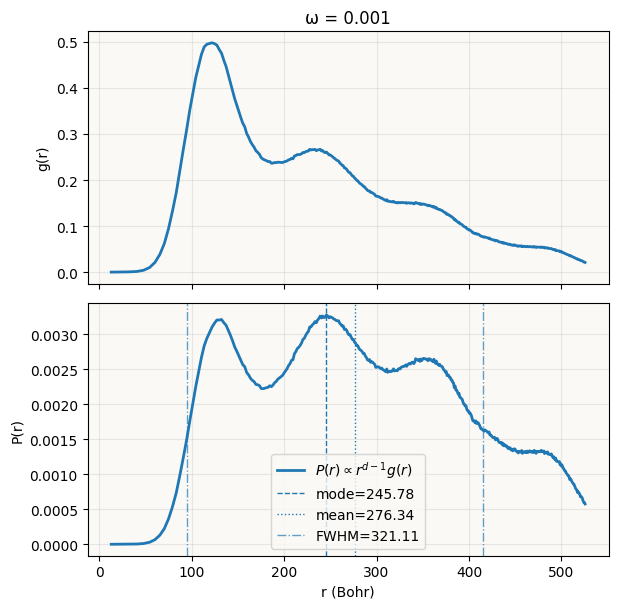

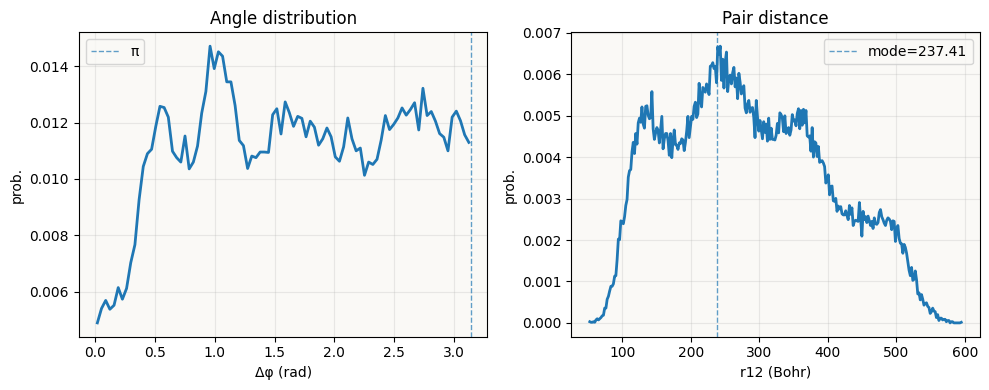

[ω=0.001]  angle σ(π-Δφ)=0.8636 | Lindemann γ_r12=0.4784


In [21]:
# ================== ANALYZE THIS ω-RUN (plots + stats) ==================
import math

import torch
import torch.nn.functional as F
from matplotlib import cycler

# ---- styling (your palette) ----
plt.rcParams['axes.facecolor'] = (0.9803921568627451, 0.9764705882352941, 0.9647058823529412)
plt.rcParams['axes.prop_cycle'] = cycler('color', [
    (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
    (0.6313725490196078, 0.2, 0.2),
    (0.5450980392156862, 0.33725490196078434, 0.29411764705882354),
    (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
])

torch.set_default_dtype(torch.float64)

# ---- helpers ----
def to_physical_r_from_trap(r_tilde: torch.Tensor, omega: float) -> torch.Tensor:
    return r_tilde * (1.0 / math.sqrt(float(omega)))

def radial_probability(r_phys: torch.Tensor, g: torch.Tensor, d: int = 2):
    dr = torch.diff(r_phys, prepend=r_phys[:1])
    P  = (r_phys.clamp_min(0)**(d-1)) * g.clamp_min(0)
    Z  = torch.sum(P * dr).clamp(min=1e-16)
    return P / Z, dr

def _fwhm_from_discrete(r: torch.Tensor, y: torch.Tensor, idx_peak: int):
    y_half = float(y[idx_peak]) * 0.5
    iL = idx_peak
    while iL > 0 and y[iL] > y_half: iL -= 1
    rL = float(r[iL])
    iR = idx_peak
    n  = len(r) - 1
    while iR < n and y[iR] > y_half: iR += 1
    rR = float(r[iR]) if iR <= n else float(r[n])
    return max(rR - rL, 0.0), rL, rR

def summarize_Pr(r_phys: torch.Tensor, g: torch.Tensor, d: int = 2):
    P, dr = radial_probability(r_phys, g, d=d)
    i_mode = int(torch.argmax(P))
    r_mode = float(r_phys[i_mode])
    mean   = float(torch.sum(r_phys * P * dr))
    var    = float(torch.sum((r_phys - mean)**2 * P * dr))
    std    = math.sqrt(max(var, 0.0))
    fwhm, rL, rR = _fwhm_from_discrete(r_phys, P, i_mode)
    cdf = torch.cumsum(P * dr, dim=0)
    def q(p):
        idx = int(torch.searchsorted(cdf, torch.tensor(p, device=r_phys.device, dtype=r_phys.dtype)))
        idx = max(0, min(idx, len(r_phys)-1))
        return float(r_phys[idx])
    q10, q50, q90 = q(0.10), q(0.50), q(0.90)
    eps = 1e-16
    entropy = float(-torch.sum((P+eps).log() * P * dr))
    return dict(r_mode=r_mode, mean=mean, std=std, fwhm=fwhm, rL=rL, rR=rR,
                q10=q10, q50=q50, q90=q90, entropy=entropy, P=P, i_mode=i_mode)

# Optional diagnostics from captured samples (in *Bohr*)
def angle_histogram(samples_X_phys: torch.Tensor, nbins: int = 90):
    phi = torch.atan2(samples_X_phys[:, :, 1], samples_X_phys[:, :, 0])   # (K,2)
    dphi = torch.abs(phi[:,0] - phi[:,1])
    pi = math.pi
    dphi = torch.where(dphi > pi, 2*pi - dphi, dphi)
    edges = torch.linspace(0.0, pi, nbins+1, device=dphi.device, dtype=dphi.dtype)
    H = torch.histc(dphi, bins=nbins, min=float(edges[0]), max=float(edges[-1]))
    H = H / H.sum().clamp(min=1)
    centers = 0.5*(edges[:-1] + edges[1:])
    # “anti-alignment sharpness”:
    sigma_phi = float(torch.std(pi - dphi, unbiased=False))
    return centers.cpu().numpy(), H.cpu().numpy(), sigma_phi

def lindemann_from_samples(samples_X_phys: torch.Tensor, nbins: int = 300):
    r12 = torch.linalg.norm(samples_X_phys[:,0,:] - samples_X_phys[:,1,:], dim=-1)
    edges = torch.linspace(r12.min(), r12.max(), nbins+1, device=r12.device, dtype=r12.dtype)
    H = torch.histc(r12, bins=nbins, min=float(edges[0]), max=float(edges[-1]))
    # smooth for robust mode
    Hs = F.avg_pool1d(H.view(1,1,-1), kernel_size=7, stride=1, padding=3).view(-1)
    centers = 0.5*(edges[:-1] + edges[1:])
    i0 = int(torch.argmax(Hs))
    r0 = float(centers[i0])
    P = H / H.sum().clamp(min=1)
    mean = float(torch.sum(centers * P))
    var  = float(torch.sum((centers-mean)**2 * P))
    gamma = math.sqrt(max(var,0.0)) / max(r0,1e-12)
    return r0, gamma, centers.cpu().numpy(), (P.cpu().numpy())

# ---------------- run the analysis for this ω ----------------
a_ho   = 1.0 / math.sqrt(omega)
r_phys = to_physical_r_from_trap(r_tilde, omega)            # Bohr

summ = summarize_Pr(r_phys, g, d=2)
gamma = summ["std"] / max(summ["r_mode"], 1e-12)

print(f"[ω={omega:g}] d=2 | mode={summ['r_mode']:.4f}, mean={summ['mean']:.4f}, std={summ['std']:.4f}, "
      f"FWHM={summ['fwhm']:.4f}, q10={summ['q10']:.4f}, q50={summ['q50']:.4f}, q90={summ['q90']:.4f}, "
      f"entropy={summ['entropy']:.4f}  |  gamma={gamma:.6f}")

# ---- Figure 1: g(r) and P(r) ----
r_np, g_np = r_phys.cpu().numpy(), g.cpu().numpy()
P_np = summ["P"].cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(6.2, 6.2), sharex=True)
axes[0].plot(r_np, g_np, lw=2)
axes[0].set_ylabel("g(r)"); axes[0].set_title(f"ω = {omega:g}")
axes[0].grid(alpha=0.25)

axes[1].plot(r_np, P_np, lw=2, label=r"$P(r)\propto r^{d-1}g(r)$")
axes[1].axvline(summ["r_mode"], ls="--", lw=1, label=f"mode={summ['r_mode']:.2f}")
axes[1].axvline(summ["mean"],   ls=":",  lw=1, label=f"mean={summ['mean']:.2f}")
axes[1].axvline(summ["rL"],     ls="-.", lw=1, alpha=0.7, label=f"FWHM={summ['fwhm']:.2f}")
axes[1].axvline(summ["rR"],     ls="-.", lw=1, alpha=0.7)
axes[1].set_xlabel("r (Bohr)"); axes[1].set_ylabel("P(r)")
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout(); plt.show()

# ---- Figure 2 (optional): angles + r12 Lindemann, if samples_X_trap is available ----
try:
    samples_X_trap
except NameError:
    samples_X_trap = None

if samples_X_trap is not None:
    # convert trap -> Bohr
    samples_X_phys = samples_X_trap * (1.0 / math.sqrt(omega))

    # Angle distribution
    ang_c, ang_h, sigma_phi = angle_histogram(samples_X_phys, nbins=90)
    # Pair-distance Lindemann
    r0_mode, gamma_r12, r12_centers, r12_prob = lindemann_from_samples(samples_X_phys, nbins=300)

    fig2, (axA, axB) = plt.subplots(1, 2, figsize=(10,4))
    axA.plot(ang_c, ang_h, lw=2)
    axA.axvline(np.pi, ls="--", lw=1, alpha=0.7, label="π")
    axA.set_xlabel("Δφ (rad)"); axA.set_ylabel("prob.")
    axA.set_title("Angle distribution"); axA.grid(alpha=0.25); axA.legend()

    axB.plot(r12_centers, r12_prob, lw=2)
    axB.axvline(r0_mode, ls="--", lw=1, alpha=0.7, label=f"mode={r0_mode:.2f}")
    axB.set_xlabel("r12 (Bohr)"); axB.set_ylabel("prob.")
    axB.set_title("Pair distance"); axB.grid(alpha=0.25); axB.legend()
    plt.tight_layout(); plt.show()

    print(f"[ω={omega:g}]  angle σ(π-Δφ)={sigma_phi:.4f} | Lindemann γ_r12={gamma_r12:.4f}")


In [22]:
# ========= SAVE r, g, and x-samples (trap + Bohr) into ../results/tables/<N>/<omega>/<run_id>/ =========
import math
from pathlib import Path

import numpy as np
import torch


def _omega_folder(omega: float, digits: int = 5) -> str:
    # Folder-safe, fixed precision (e.g. omega_0.01000)
    return f"omega_{omega:.{digits}f}"

def _safe_tag(tag: str | None) -> str:
    if not tag:
        return ""
    # remove bad chars for filenames
    safe = "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in tag)
    return (safe + "_") if safe else ""

def save_gr_results_tables(
    n_particles: int,
    omega: float,
    r_tilde: torch.Tensor,             # (bins,) in TRAP units
    g: torch.Tensor,                   # (bins,)
    stats: dict,
    samples_X_trap: torch.Tensor | None,   # (K,N,2) in TRAP units or None
    base_rel: str = "..",              # go one level up
    tag: str | None = None,
) -> dict:
    """
    Folder layout:
      ../results/tables/<N>/<omega>/<run_id>/
        gr_<tag>omega_<prec>.pt
        gr_<tag>omega_<prec>.npz
        gr_<tag>omega_<prec>.meta.json
    Returns dict with paths.
    """
    # --- derive units
    a_ho = 1.0 / math.sqrt(max(float(omega), 1e-12))

    # --- ensure CPU copies for saving
    r_tilde_cpu = r_tilde.detach().cpu()
    g_cpu       = g.detach().cpu()
    r_bohr_cpu  = r_tilde_cpu * a_ho

    # --- optional samples (trap + bohr)
    if samples_X_trap is not None:
        X_trap_cpu = samples_X_trap.detach().cpu()
        X_bohr_cpu = X_trap_cpu * a_ho
        n_keep, N, d = X_trap_cpu.shape
    else:
        X_trap_cpu = None
        X_bohr_cpu = None
        n_keep, N, d = 0, None, None

    # --- build target folder: ../results/tables/<N>/<omega>/<run_id>/
    run_id = time.strftime("%Y%m%d_%H%M%S")
    root   = Path(base_rel).resolve() / "results" / "tables"
    sub    = root / str(int(n_particles)) / _omega_folder(omega) / run_id
    sub.mkdir(parents=True, exist_ok=True)

    # --- filenames
    omega_str = f"{omega:.5f}"
    base_name = f"gr_{_safe_tag(tag)}omega_{omega_str}"
    pt_path   = sub / f"{base_name}.pt"
    npz_path  = sub / f"{base_name}.npz"
    meta_path = sub / f"{base_name}.meta.json"

    # --- save .pt (rich PyTorch bundle)
    bundle = {
        "omega": float(omega),
        "a_ho": float(a_ho),
        "n_particles": int(n_particles),
        "units": {
            "r_tilde": "trap",
            "r_bohr": "Bohr",
            "samples_X_trap": "trap",
            "samples_X_bohr": "Bohr",
        },
        "r_tilde": r_tilde_cpu,          # (bins,)
        "g": g_cpu,                      # (bins,)
        "r_bohr": r_bohr_cpu,            # (bins,)
        "samples_X_trap": X_trap_cpu,    # (K,N,2) or None
        "samples_X_bohr": X_bohr_cpu,    # (K,N,2) or None
        "stats": stats,
        "saved_at": run_id,
        "tag": tag,
    }
    torch.save(bundle, pt_path)

    # --- save .npz (portable; compress; skip giant arrays)
    save_npz = {
        "omega": np.array([omega], dtype=np.float64),
        "a_ho": np.array([a_ho], dtype=np.float64),
        "n_particles": np.array([n_particles], dtype=np.int32),
        "r_tilde": r_tilde_cpu.numpy(),
        "g": g_cpu.numpy(),
        "r_bohr": r_bohr_cpu.numpy(),
    }
    if X_bohr_cpu is not None:
        bytes_est = X_bohr_cpu.numel() * X_bohr_cpu.element_size()
        # keep up to ~200MB per array in the npz to avoid huge files
        if bytes_est <= 200 * 1024 * 1024:
            save_npz["samples_X_trap"] = X_trap_cpu.numpy()
            save_npz["samples_X_bohr"] = X_bohr_cpu.numpy()

    np.savez_compressed(npz_path, **save_npz)

    # --- meta.json (tiny)
    meta = {
        "omega": float(omega),
        "a_ho": float(a_ho),
        "n_particles": int(n_particles),
        "bins": int(r_tilde_cpu.numel()),
        "n_samples_kept": int(n_keep),
        "N": None if N is None else int(N),
        "dim": None if d is None else int(d),
        "stats": {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in (stats or {}).items()},
        "saved_at": run_id,
        "tag": tag,
        "paths": {"pt": str(pt_path), "npz": str(npz_path)},
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"[saved] {pt_path}")
    print(f"[saved] {npz_path}")
    print(f"[saved] {meta_path}")

    return {"pt": pt_path, "npz": npz_path, "meta": meta_path, "dir": sub}
# after:
# r_tilde, g, stats, samples_X_trap = compute_gr_with_sampler(...)

paths = save_gr_results_tables(
    n_particles=n_particles,
    omega=omega,
    r_tilde=r_tilde,
    g=g,
    stats=stats,
    samples_X_trap=samples_X_trap,   # or None
    base_rel="..",                   # go up one: ../results/tables/...
    tag="N20_run"                     # optional
)
print(paths)


[saved] /itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.pt
[saved] /itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.npz
[saved] /itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.meta.json
{'pt': PosixPath('/itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.pt'), 'npz': PosixPath('/itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.npz'), 'meta': PosixPath('/itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934/gr_N20_run_omega_0.00100.meta.json'), 'dir': PosixPath('/itf-fi-ml/home/aleksns/Thesis/results/tables/20/omega_0.00100/20260107_113934')}


In [11]:
def _stack_hook_blocks(M, *, force_cpu: bool = True):
    """
    Accepts:
      - torch.Tensor (B,F)
      - list[torch.Tensor] each (b,F)
      - None
    Returns:
      - torch.Tensor (B,F) or None
    """
    if M is None:
        return None

    if torch.is_tensor(M):
        T = M.detach()
        return T.to("cpu") if force_cpu else T

    if isinstance(M, (list, tuple)):
        blocks = []
        for t in M:
            if t is None:
                continue
            if not torch.is_tensor(t):
                continue
            tt = t.detach()
            if force_cpu:
                tt = tt.to("cpu")
            blocks.append(tt)
        if len(blocks) == 0:
            return None
        return torch.cat(blocks, dim=0)

    raise TypeError(f"_stack_hook_blocks: expected Tensor/list/None, got {type(M)}")
